In [1]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
import json
from tqdm import tqdm

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash") 

# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_gemini_rationales_filtered.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print(f"📌 Total dataset size: {merged.shape} rows")

# ---------------------------
# 4. CHECK EXISTING PROGRESS (The Fix)
# ---------------------------
output_path = "esnli_evidence_extraction_gemini.csv"
existing_ids = set()

if os.path.exists(output_path):
    # Read the file to see what is already done
    try:
        existing_df = pd.read_csv(output_path)
        if "id" in existing_df.columns:
            existing_ids = set(existing_df["id"].unique())
            print(f"🔄 Found {len(existing_ids)} examples already completed. Resuming...")
    except Exception:
        print("⚠️ Output file exists but seems empty or corrupt. Starting fresh.")

write_header = not os.path.exists(output_path)

# ---------------------------
# 5. EXTRACTION FUNCTION (Unchanged)
# ---------------------------
EXTRACTION_PROMPT = """
You are an expert linguist performing feature attribution for NLI.
Task: Identify the exact words or short phrases in the **Premise** that act as the evidence for the **Rationale**.

INPUTS:
Premise: "{premise}"
Hypothesis: "{hypothesis}"
Model Rationale: "{rationale} So the label is {label}."

INSTRUCTIONS:
1. Read the Rationale. Determine which specific facts in the Premise it relies on.
2. Handle Synonyms: If Rationale says 'animal' but Premise says 'dog', extract 'dog'.
3. Handle Logic: If Rationale says 'not standing', extract words like 'sitting'.
4. Minimalism: Extract only necessary words.
5. Exact Match: The output words MUST exist exactly in the Premise.

OUTPUT FORMAT:
Return ONLY a valid JSON list of strings. Example: ["dog", "green field"]
"""

def extract_evidence_spans(premise, hypothesis, label, rationale):
    prompt = EXTRACTION_PROMPT.format(premise=premise, hypothesis=hypothesis, label=label, rationale=rationale)
    try:
        resp = model.generate_content(prompt, generation_config={"temperature": 0.0, "response_mime_type": "application/json"})
        text = resp.text.strip()
        if text.startswith("```json"): text = text[7:]
        if text.endswith("```"): text = text[:-3]
        evidence_list = json.loads(text.strip())
        return [str(item) for item in evidence_list] if isinstance(evidence_list, list) else []
    except:
        return []

# ---------------------------
# 6. MAIN LOOP WITH SKIP LOGIC
# ---------------------------
with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow(["id", "premise_text", "evidence_original", "evidence_lexical", "evidence_syntactic", "evidence_pragmatic"])

    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Extracting"):
        ex_id = row["id"]

        # 🔥 SKIP IF ALREADY DONE
        if ex_id in existing_ids:
            continue  

        premise = row["Premise"]
        gold_label = row["gold_label"]

        # Run Extraction
        ev_orig = extract_evidence_spans(premise, row["Hypothesis"], gold_label, row["rationale_original"])
        ev_lex  = extract_evidence_spans(premise, row["perturbation_1_lexical"], gold_label, row["rationale_pert1"])
        ev_syn  = extract_evidence_spans(premise, row["perturbation_2_syntactic"], gold_label, row["rationale_pert2"])
        ev_prag = extract_evidence_spans(premise, row["perturbation_3_pragmatic"], gold_label, row["rationale_pert3"])

        # Write Row
        writer.writerow([ex_id, premise, json.dumps(ev_orig), json.dumps(ev_lex), json.dumps(ev_syn), json.dumps(ev_prag)])
        f.flush()
        os.fsync(f.fileno())

print("🎉 DONE! Dataset is consistent.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


📌 Total dataset size: (627, 12) rows
🔄 Found 367 examples already completed. Resuming...


Extracting: 100%|█████████████████████████████| 627/627 [43:18<00:00,  4.14s/it]

🎉 DONE! Dataset is consistent.


**Llama**

In [3]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
import json
from tqdm import tqdm

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash") 

# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_llama_rationales_filtered.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print(f"📌 Total dataset size: {merged.shape} rows")

# ---------------------------
# 4. CHECK EXISTING PROGRESS (The Fix)
# ---------------------------
output_path = "esnli_evidence_extraction_llama.csv"
existing_ids = set()

if os.path.exists(output_path):
    # Read the file to see what is already done
    try:
        existing_df = pd.read_csv(output_path)
        if "id" in existing_df.columns:
            existing_ids = set(existing_df["id"].unique())
            print(f"🔄 Found {len(existing_ids)} examples already completed. Resuming...")
    except Exception:
        print("⚠️ Output file exists but seems empty or corrupt. Starting fresh.")

write_header = not os.path.exists(output_path)

# ---------------------------
# 5. EXTRACTION FUNCTION (Unchanged)
# ---------------------------
EXTRACTION_PROMPT = """
You are an expert linguist performing feature attribution for NLI.
Task: Identify the exact words or short phrases in the **Premise** that act as the evidence for the **Rationale**.

INPUTS:
Premise: "{premise}"
Hypothesis: "{hypothesis}"
Model Rationale: "{rationale} So the label is {label}."

INSTRUCTIONS:
1. Read the Rationale. Determine which specific facts in the Premise it relies on.
2. Handle Synonyms: If Rationale says 'animal' but Premise says 'dog', extract 'dog'.
3. Handle Logic: If Rationale says 'not standing', extract words like 'sitting'.
4. Minimalism: Extract only necessary words.
5. Exact Match: The output words MUST exist exactly in the Premise.

OUTPUT FORMAT:
Return ONLY a valid JSON list of strings. Example: ["dog", "green field"]
"""

def extract_evidence_spans(premise, hypothesis, label, rationale):
    prompt = EXTRACTION_PROMPT.format(premise=premise, hypothesis=hypothesis, label=label, rationale=rationale)
    try:
        resp = model.generate_content(prompt, generation_config={"temperature": 0.0, "response_mime_type": "application/json"})
        text = resp.text.strip()
        if text.startswith("```json"): text = text[7:]
        if text.endswith("```"): text = text[:-3]
        evidence_list = json.loads(text.strip())
        return [str(item) for item in evidence_list] if isinstance(evidence_list, list) else []
    except:
        return []

# ---------------------------
# 6. MAIN LOOP WITH SKIP LOGIC
# ---------------------------
with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow(["id", "premise_text", "evidence_original", "evidence_lexical", "evidence_syntactic", "evidence_pragmatic"])

    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Extracting"):
        ex_id = row["id"]

        # 🔥 SKIP IF ALREADY DONE
        if ex_id in existing_ids:
            continue  

        premise = row["Premise"]
        gold_label = row["gold_label"]

        # Run Extraction
        ev_orig = extract_evidence_spans(premise, row["Hypothesis"], gold_label, row["rationale_original"])
        ev_lex  = extract_evidence_spans(premise, row["perturbation_1_lexical"], gold_label, row["rationale_lexical"])
        ev_syn  = extract_evidence_spans(premise, row["perturbation_2_syntactic"], gold_label, row["rationale_syntactic"])
        ev_prag = extract_evidence_spans(premise, row["perturbation_3_pragmatic"], gold_label, row["rationale_pragmatic"])

        # Write Row
        writer.writerow([ex_id, premise, json.dumps(ev_orig), json.dumps(ev_lex), json.dumps(ev_syn), json.dumps(ev_prag)])
        f.flush()
        os.fsync(f.fileno())

print("🎉 DONE! Dataset is consistent.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


📌 Total dataset size: (627, 12) rows
🔄 Found 158 examples already completed. Resuming...


Extracting: 100%|███████████████████████████| 627/627 [1:41:53<00:00,  9.75s/it]

🎉 DONE! Dataset is consistent.


 **mistral**

In [1]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
import json
import re
from tqdm import tqdm

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
# Using Flash because it's fast and good at following JSON constraints
model = GenerativeModel("gemini-2.5-flash") 
print("✅ Gemini model initialized.")

# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("esnli_mistral_rationales_filtered.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print(f"📌 Final merged dataset: {merged.shape} rows")

# ---------------------------
# 4. EXTRACTION PROMPT
# ---------------------------
EXTRACTION_PROMPT = """
You are an expert linguist performing feature attribution for NLI.

**Task:** Identify the exact words or short phrases in the **Premise** that act as the evidence for the **Rationale**.

**INPUTS:**
Premise: "{premise}"
Hypothesis: "{hypothesis}"
Model Rationale: "{rationale} So the label is {label}."

**INSTRUCTIONS:**
1. Read the Rationale. Determine which specific facts in the Premise it relies on.
2. **Handle Synonyms:** If the Rationale says 'animal' but the Premise says 'dog', extract 'dog' (the word found in the text).
3. **Handle Logic:** If Rationale says 'not standing', extract the words in the Premise that prove this (e.g., 'sitting').
4. **Minimalism:** Extract only the necessary words. Do not extract the whole sentence unless absolutely required.
5. **Exact Match:** The output words MUST exist exactly in the Premise.

**OUTPUT FORMAT:**
Return ONLY a valid JSON list of strings. Do not add markdown blocks.
Example Output: ["dog", "green field", "running"]
"""

# ---------------------------
# 5. EXTRACTION FUNCTION
# ---------------------------
def extract_evidence_spans(premise, hypothesis, label, rationale):
    """
    Sends the prompt to Gemini and cleans the output into a Python list.
    """
    prompt = EXTRACTION_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        # Lower temperature for deterministic extraction
        resp = model.generate_content(
            prompt, 
            generation_config={"temperature": 0.0, "response_mime_type": "application/json"}
        )
        text = resp.text.strip()

        # Cleaning: Remove markdown code blocks if the model ignores the instruction
        if text.startswith("```json"):
            text = text[7:]
        if text.endswith("```"):
            text = text[:-3]
        
        text = text.strip()
        
        # Parse JSON
        evidence_list = json.loads(text)
        
        # Validation: Ensure it's a list of strings
        if isinstance(evidence_list, list):
            # Final sanity check: Convert all items to string just in case
            return [str(item) for item in evidence_list]
        else:
            return [] # Fallback for bad format

    except Exception as e:
        # If JSON parsing fails or API errors, return empty list (safest default)
        # tqdm.write(f"⚠️ Error extracting: {e}") 
        return []

# ---------------------------
# 6. PREPARE OUTPUT CSV
# ---------------------------
output_path = "esnli_evidence_extraction_mistral_fixed_2.csv"
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header if file doesn't exist
    if write_header:
        writer.writerow([
            "id",
            "premise_text",  # Saving premise again helps debugging later
            "evidence_original",
            "evidence_lexical",
            "evidence_syntactic",
            "evidence_pragmatic"
        ])
        print("📝 Created new output file with header.")

    # ---------------------------
    # 7. MAIN LOOP
    # ---------------------------
    # Using tqdm to show progress bar
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Extracting Evidence"):
        
        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]

        # 1. ORIGINAL
        ev_orig = extract_evidence_spans(
            premise, row["Hypothesis"], gold_label, row["rationale_original"]
        )
        
        # 2. LEXICAL
        ev_lex = extract_evidence_spans(
            premise, row["perturbation_1_lexical"], gold_label, row["rationale_lexical"]
        )

        # 3. SYNTACTIC
        ev_syn = extract_evidence_spans(
            premise, row["perturbation_2_syntactic"], gold_label, row["rationale_syntactic"]
        )

        # 4. PRAGMATIC
        ev_prag = extract_evidence_spans(
            premise, row["perturbation_3_pragmatic"], gold_label, row["rationale_pragmatic"]
        )

        # Write to CSV
        # json.dumps converts the Python list ['dog', 'cat'] into the string '["dog", "cat"]'
        writer.writerow([
            ex_id,
            premise,
            json.dumps(ev_orig),
            json.dumps(ev_lex),
            json.dumps(ev_syn),
            json.dumps(ev_prag)
        ])

        # Force flush to ensure data is saved even if script crashes
        f.flush()
        os.fsync(f.fileno())
        
        # Respect rate limits (optional, Flash usually handles high throughput)
        # time.sleep(0.1)

print("🎉 DONE! Evidence extraction complete.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Final merged dataset: (623, 12) rows
📝 Created new output file with header.


Extracting Evidence: 100%|██████████████████| 623/623 [2:15:04<00:00, 13.01s/it]

🎉 DONE! Evidence extraction complete.


**Qwen**

In [2]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
import json
import re
from tqdm import tqdm

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash") 
print("✅ Gemini model initialized.")

# ---------------------------
# 3. LOAD DATA
# ---------------------------
rationales_df = pd.read_csv("qwen_esnli_rationales_filtered.csv")
perturb_df = pd.read_csv("esnli_800_with_perturbations.csv")

# Keep only rows where we have rationales
perturb_df = perturb_df[perturb_df["id"].isin(rationales_df["id"])]

# Merge both datasets
merged = pd.merge(rationales_df, perturb_df, on="id", how="inner")
print(f"📌 Total rows in dataset: {merged.shape[0]}")

# ---------------------------
# 4. EXTRACTION PROMPT
# ---------------------------
EXTRACTION_PROMPT = """
You are an expert linguist performing feature attribution for NLI.

**Task:** Identify the exact words or short phrases in the **Premise** that act as the evidence for the **Rationale**.

**INPUTS:**
Premise: "{premise}"
Hypothesis: "{hypothesis}"
Model Rationale: "{rationale} So the label is {label}."

**INSTRUCTIONS:**
1. Read the Rationale. Determine which specific facts in the Premise it relies on.
2. **Handle Synonyms:** If the Rationale says 'animal' but the Premise says 'dog', extract 'dog' (the word found in the text).
3. **Handle Logic:** If Rationale says 'not standing', extract the words in the Premise that prove this (e.g., 'sitting').
4. **Minimalism:** Extract only the necessary words. Do not extract the whole sentence unless absolutely required.
5. **Exact Match:** The output words MUST exist exactly in the Premise.

**OUTPUT FORMAT:**
Return ONLY a valid JSON list of strings. Do not add markdown blocks.
Example Output: ["dog", "green field", "running"]
"""

# ---------------------------
# 5. EXTRACTION FUNCTION
# ---------------------------
def extract_evidence_spans(premise, hypothesis, label, rationale):
    """
    Sends the prompt to Gemini and cleans the output into a Python list.
    """
    prompt = EXTRACTION_PROMPT.format(
        premise=premise,
        hypothesis=hypothesis,
        label=label,
        rationale=rationale
    )

    try:
        # Lower temperature for deterministic extraction
        resp = model.generate_content(
            prompt, 
            generation_config={"temperature": 0.0, "response_mime_type": "application/json"}
        )
        text = resp.text.strip()

        # Cleaning: Remove markdown code blocks if the model ignores the instruction
        if text.startswith("```json"):
            text = text[7:]
        if text.endswith("```"):
            text = text[:-3]
        
        text = text.strip()
        
        # Parse JSON
        evidence_list = json.loads(text)
        
        # Validation: Ensure it's a list of strings
        if isinstance(evidence_list, list):
            return [str(item) for item in evidence_list]
        else:
            return [] # Fallback for bad format

    except Exception as e:
        # If JSON parsing fails or API errors, return empty list (safest default)
        return []

# ---------------------------
# 6. CHECK FOR EXISTING PROGRESS
# ---------------------------
output_path = "esnli_evidence_extraction_qwen.csv"
processed_ids = set()

if os.path.exists(output_path):
    print(f"🔄 Found existing file: {output_path}")
    try:
        # Read the existing file to get IDs
        existing_df = pd.read_csv(output_path)
        if "id" in existing_df.columns:
            processed_ids = set(existing_df["id"].unique())
            print(f"⏩ Skipping {len(processed_ids)} already processed IDs.")
        else:
            print("⚠️ Existing file found but 'id' column missing. Starting from scratch.")
    except Exception as e:
        print(f"⚠️ Error reading existing file: {e}. Starting from scratch.")

# Filter the merged dataframe to exclude processed IDs
# This creates a new dataframe 'remaining_df' with only the work left to do
remaining_df = merged[~merged["id"].isin(processed_ids)]

print(f"🚀 Starting processing on remaining {len(remaining_df)} rows...")

# ---------------------------
# 7. MAIN LOOP (RESUMED)
# ---------------------------
write_header = not os.path.exists(output_path)

with open(output_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Write header ONLY if the file didn't exist before
    if write_header:
        writer.writerow([
            "id",
            "premise_text",
            "evidence_original",
            "evidence_lexical",
            "evidence_syntactic",
            "evidence_pragmatic"
        ])
        print("📝 Created new output file with header.")

    # Iterate over 'remaining_df' instead of 'merged'
    for idx, row in tqdm(remaining_df.iterrows(), total=len(remaining_df), desc="Extracting Evidence"):
        
        ex_id = row["id"]
        premise = row["Premise"]
        gold_label = row["gold_label"]

        # 1. ORIGINAL
        ev_orig = extract_evidence_spans(
            premise, row["Hypothesis"], gold_label, row["rationale_original"]
        )
        
        # 2. LEXICAL
        ev_lex = extract_evidence_spans(
            premise, row["perturbation_1_lexical"], gold_label, row["rationale_perturbation_1_lexical"]
        )

        # 3. SYNTACTIC
        ev_syn = extract_evidence_spans(
            premise, row["perturbation_2_syntactic"], gold_label, row["rationale_perturbation_2_syntactic"]
        )

        # 4. PRAGMATIC
        ev_prag = extract_evidence_spans(
            premise, row["perturbation_3_pragmatic"], gold_label, row["rationale_perturbation_3_pragmatic"]
        )

        # Write to CSV
        writer.writerow([
            ex_id,
            premise,
            json.dumps(ev_orig),
            json.dumps(ev_lex),
            json.dumps(ev_syn),
            json.dumps(ev_prag)
        ])

        # Force flush to ensure data is saved immediately
        f.flush()
        os.fsync(f.fileno())

print("🎉 DONE! Evidence extraction complete.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📌 Total rows in dataset: 627
🔄 Found existing file: esnli_evidence_extraction_qwen.csv
⏩ Skipping 450 already processed IDs.
🚀 Starting processing on remaining 177 rows...


Extracting Evidence: 100%|████████████████████| 177/177 [30:30<00:00, 10.34s/it]

🎉 DONE! Evidence extraction complete.


In [6]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel
import vertexai
import time
import csv
import json
import re
from tqdm import tqdm

# CLEANUP SCRIPT
df = pd.read_csv("esnli_evidence_extraction_qwen.csv")
# Keep the first occurrence of each ID, drop the rest
df_clean = df.drop_duplicates(subset=["id"], keep="first")
# Save it back
df_clean.to_csv("esnli_evidence_extraction_qwen_fixed.csv", index=False)
print(f"🧹 Cleaned file. Rows before: {len(df)}, Rows after: {len(df_clean)}")

🧹 Cleaned file. Rows before: 676, Rows after: 627


**llama step 2**

In [9]:
import pandas as pd
import json
import random
import re
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_evidence_extraction_llama.csv"
OUTPUT_FILE = "esnli_interventions_llama.csv"
MASK_TOKEN = "_____"  # The token models see instead of the word

# Set a seed for reproducibility of the Ghost Twins
random.seed(42)

# ---------------------------
# 2. HELPER: ROBUST MASKING
# ---------------------------
def clean_token(t):
    """Normalize token for matching (lowercase, remove punctuation)."""
    return re.sub(r'[^\w\s]', '', t.lower())

def create_masks(premise_text, evidence_list_json):
    try:
        # 1. Parse JSON
        evidence_spans = json.loads(evidence_list_json)
        if not isinstance(evidence_spans, list):
            evidence_spans = []
        
        # 2. Tokenize Premise
        tokens = premise_text.split()
        if len(tokens) == 0:
            return premise_text, premise_text, premise_text, 0.0

        # We need a map of which indices are "Evidence"
        evidence_indices = set()
        clean_tokens = [clean_token(t) for t in tokens]
        
        # 3. Locate Evidence Spans (Double Pass Strategy)
        for span in evidence_spans:
            span_words = span.split()
            clean_span = [clean_token(s) for s in span_words]
            if not clean_span: continue

            span_len = len(clean_span)
            match_found = False
            
            # PASS 1: Strict Phrase Match (Sliding Window)
            for i in range(len(clean_tokens) - span_len + 1):
                window = clean_tokens[i : i + span_len]
                if window == clean_span:
                    for j in range(span_len):
                        evidence_indices.add(i + j)
                    match_found = True
            
            # PASS 2: Fallback (Individual Word Match)
            if not match_found:
                for span_word in clean_span:
                    for i, token in enumerate(clean_tokens):
                        if token == span_word:
                            evidence_indices.add(i)

        # ---------------------------
        # A) NECESSITY (Mask Evidence)
        # ---------------------------
        nec_tokens = tokens.copy()
        for idx in evidence_indices:
            nec_tokens[idx] = MASK_TOKEN
        necessity_str = " ".join(nec_tokens)
        
        # ---------------------------
        # B) SUFFICIENCY (Mask Non-Evidence)
        # ---------------------------
        suff_tokens = tokens.copy()
        for i in range(len(tokens)):
            if i not in evidence_indices:
                suff_tokens[i] = MASK_TOKEN
        sufficiency_str = " ".join(suff_tokens)
        
        # ---------------------------
        # C) GHOST TWIN (Mask Random Non-Evidence)
        # ---------------------------
        num_to_mask = len(evidence_indices)
        non_evidence_pool = [i for i in range(len(tokens)) if i not in evidence_indices]
        
        ghost_tokens = tokens.copy()
        
        if len(non_evidence_pool) >= num_to_mask:
            indices_to_mask = random.sample(non_evidence_pool, num_to_mask)
        else:
            indices_to_mask = non_evidence_pool
            
        for idx in indices_to_mask:
            ghost_tokens[idx] = MASK_TOKEN
        
        ghost_twin_str = " ".join(ghost_tokens)
        
        # ---------------------------
        # METRICS
        # ---------------------------
        coverage = len(evidence_indices) / len(tokens)
        # NOTE: We do NOT rely on rounding here anymore for saving 
        # because the CSV writer handles formatting now.
        
        return necessity_str, sufficiency_str, ghost_twin_str, coverage

    except Exception as e:
        return premise_text, premise_text, premise_text, 0.0

# ---------------------------
# 3. MAIN EXECUTION
# ---------------------------
print("🚀 Starting Step 2: Generating Intervention Inputs...")
df = pd.read_csv(INPUT_FILE)
print(f"📂 Loaded {len(df)} examples from {INPUT_FILE}")

output_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Masks"):
    ex_id = row["id"]
    raw_premise = row["premise_text"]
    
    variants = [
        ("original", row["evidence_original"]),
        ("lexical", row["evidence_lexical"]),
        ("syntactic", row["evidence_syntactic"]),
        ("pragmatic", row["evidence_pragmatic"])
    ]
    
    row_data = {
        "id": ex_id,
        "premise_raw": raw_premise
    }
    
    for var_name, evidence_json in variants:
        nec, suff, ghost, cov = create_masks(raw_premise, evidence_json)
        
        row_data[f"premise_{var_name}_necessity"] = nec
        row_data[f"premise_{var_name}_sufficiency"] = suff
        row_data[f"premise_{var_name}_ghost"] = ghost
        row_data[f"coverage_{var_name}"] = cov

    output_rows.append(row_data)

# ---------------------------
# 4. SAVE OUTPUT (WITH FORMATTING FIX)
# ---------------------------
out_df = pd.DataFrame(output_rows)

# 🔥 FORCE 4 DECIMAL PLACES (e.g. 0.8750) TO PREVENT CSV READING ERRORS
out_df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Done! Saved {len(out_df)} intervention sets to: {OUTPUT_FILE}")
print("🔍 Verification Check (First 3 Coverage Values):")
print(out_df[["coverage_original", "coverage_lexical"]].head(3))

🚀 Starting Step 2: Generating Intervention Inputs...
📂 Loaded 627 examples from esnli_evidence_extraction_llama.csv


Processing Masks: 100%|████████████████████| 627/627 [00:00<00:00, 10026.57it/s]

✅ Done! Saved 627 intervention sets to: esnli_interventions_llama.csv
🔍 Verification Check (First 3 Coverage Values):
   coverage_original  coverage_lexical
0           0.200000          0.300000
1           0.538462          0.692308
2           0.750000          0.750000


In [4]:
import pandas as pd
import random
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_interventions_llama.csv"  # Your existing file
OUTPUT_FILE = "esnli_interventions_llama.csv_updated.csv" # The new version with 4 extra columns
MASK_TOKEN = "_____"

# Reproducibility
random.seed(42)

# ---------------------------
# 2. HELPER: GENERATE RANDOM KEEP (NOISE)
# ---------------------------
def generate_noise_input(premise_raw, necessity_str):
    """
    Creates the 'Random Keep' (Noise) input.
    1. Figures out N = number of evidence words by counting masks in Necessity.
    2. Keeps N random words from Raw Premise.
    3. Masks everything else.
    """
    # 1. Determine Evidence Count (N)
    # We count how many times the mask token appears in the Necessity input
    evidence_count = necessity_str.count(MASK_TOKEN)
    
    tokens = premise_raw.split()
    total_len = len(tokens)
    
    # Edge case: If evidence covers everything, Noise is just the full sentence too
    if evidence_count >= total_len:
        return " ".join(tokens)
    
    # 2. Select Random Indices to KEEP
    indices_to_keep = random.sample(range(total_len), evidence_count)
    
    # 3. Build the Masked String
    noise_tokens = []
    for i in range(total_len):
        if i in indices_to_keep:
            noise_tokens.append(tokens[i]) # Keep random word
        else:
            noise_tokens.append(MASK_TOKEN) # Mask the rest
            
    return " ".join(noise_tokens)

# ---------------------------
# 3. EXECUTION
# ---------------------------
print("📂 Loading existing interventions...")
df = pd.read_csv(INPUT_FILE)

# Prepare lists to hold new column data
noise_cols = {
    "premise_original_noise": [],
    "premise_lexical_noise": [],
    "premise_syntactic_noise": [],
    "premise_pragmatic_noise": []
}

variants = ["original", "lexical", "syntactic", "pragmatic"]

print("🛠️  Generating 'Noise' (Random Keep) columns...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    raw_premise = row["premise_raw"]
    
    for var in variants:
        # We look at the corresponding NECESSITY column to see how many words to keep
        nec_col_name = f"premise_{var}_necessity"
        nec_str = row[nec_col_name]
        
        # Generate the Noise input
        noise_str = generate_noise_input(raw_premise, nec_str)
        
        # Store it
        col_name = f"premise_{var}_noise"
        noise_cols[col_name].append(noise_str)

# ---------------------------
# 4. MERGE & SAVE
# ---------------------------
# Add the new lists as columns to the dataframe
for col_name, data in noise_cols.items():
    df[col_name] = data

# Save with the float format fix just in case coverage columns are touched
df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Success! Added 4 'noise' columns.")
print(f"📄 Saved to: {OUTPUT_FILE}")
print("\n🔍 Preview of New Column (Original Variant):")
print(df[["premise_original_sufficiency", "premise_original_noise"]].head(2))

📂 Loading existing interventions...
🛠️  Generating 'Noise' (Random Keep) columns...


100%|██████████████████████████████████████| 627/627 [00:00<00:00, 24661.50it/s]

✅ Success! Added 4 'noise' columns.
📄 Saved to: esnli_interventions_llama.csv_updated.csv

🔍 Preview of New Column (Original Variant):
                        premise_original_sufficiency  \
0  _____ _____ _____ _____ blue _____ cooking ___...   
1  _____ young man _____ _____ _____ _____ _____ ...   

                              premise_original_noise  
0  A woman _____ _____ _____ _____ _____ _____ __...  
1  This young _____ smiles as _____ _____ _____ _...  


**gemini step2**

In [12]:
import pandas as pd
import json
import random
import re
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_evidence_extraction_gemini.csv"
OUTPUT_FILE = "esnli_interventions_gemini.csv"
MASK_TOKEN = "_____"  # The token models see instead of the word

# Set a seed for reproducibility of the Ghost Twins
random.seed(42)

# ---------------------------
# 2. HELPER: ROBUST MASKING
# ---------------------------
def clean_token(t):
    """Normalize token for matching (lowercase, remove punctuation)."""
    return re.sub(r'[^\w\s]', '', t.lower())

def create_masks(premise_text, evidence_list_json):
    try:
        # 1. Parse JSON
        evidence_spans = json.loads(evidence_list_json)
        if not isinstance(evidence_spans, list):
            evidence_spans = []
        
        # 2. Tokenize Premise
        tokens = premise_text.split()
        if len(tokens) == 0:
            return premise_text, premise_text, premise_text, 0.0

        # We need a map of which indices are "Evidence"
        evidence_indices = set()
        clean_tokens = [clean_token(t) for t in tokens]
        
        # 3. Locate Evidence Spans (Double Pass Strategy)
        for span in evidence_spans:
            span_words = span.split()
            clean_span = [clean_token(s) for s in span_words]
            if not clean_span: continue

            span_len = len(clean_span)
            match_found = False
            
            # PASS 1: Strict Phrase Match (Sliding Window)
            for i in range(len(clean_tokens) - span_len + 1):
                window = clean_tokens[i : i + span_len]
                if window == clean_span:
                    for j in range(span_len):
                        evidence_indices.add(i + j)
                    match_found = True
            
            # PASS 2: Fallback (Individual Word Match)
            if not match_found:
                for span_word in clean_span:
                    for i, token in enumerate(clean_tokens):
                        if token == span_word:
                            evidence_indices.add(i)

        # ---------------------------
        # A) NECESSITY (Mask Evidence)
        # ---------------------------
        nec_tokens = tokens.copy()
        for idx in evidence_indices:
            nec_tokens[idx] = MASK_TOKEN
        necessity_str = " ".join(nec_tokens)
        
        # ---------------------------
        # B) SUFFICIENCY (Mask Non-Evidence)
        # ---------------------------
        suff_tokens = tokens.copy()
        for i in range(len(tokens)):
            if i not in evidence_indices:
                suff_tokens[i] = MASK_TOKEN
        sufficiency_str = " ".join(suff_tokens)
        
        # ---------------------------
        # C) GHOST TWIN (Mask Random Non-Evidence)
        # ---------------------------
        num_to_mask = len(evidence_indices)
        non_evidence_pool = [i for i in range(len(tokens)) if i not in evidence_indices]
        
        ghost_tokens = tokens.copy()
        
        if len(non_evidence_pool) >= num_to_mask:
            indices_to_mask = random.sample(non_evidence_pool, num_to_mask)
        else:
            indices_to_mask = non_evidence_pool
            
        for idx in indices_to_mask:
            ghost_tokens[idx] = MASK_TOKEN
        
        ghost_twin_str = " ".join(ghost_tokens)
        
        # ---------------------------
        # METRICS
        # ---------------------------
        coverage = len(evidence_indices) / len(tokens)
        # NOTE: We do NOT rely on rounding here anymore for saving 
        # because the CSV writer handles formatting now.
        
        return necessity_str, sufficiency_str, ghost_twin_str, coverage

    except Exception as e:
        return premise_text, premise_text, premise_text, 0.0

# ---------------------------
# 3. MAIN EXECUTION
# ---------------------------
print("🚀 Starting Step 2: Generating Intervention Inputs...")
df = pd.read_csv(INPUT_FILE)
print(f"📂 Loaded {len(df)} examples from {INPUT_FILE}")

output_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Masks"):
    ex_id = row["id"]
    raw_premise = row["premise_text"]
    
    variants = [
        ("original", row["evidence_original"]),
        ("lexical", row["evidence_lexical"]),
        ("syntactic", row["evidence_syntactic"]),
        ("pragmatic", row["evidence_pragmatic"])
    ]
    
    row_data = {
        "id": ex_id,
        "premise_raw": raw_premise
    }
    
    for var_name, evidence_json in variants:
        nec, suff, ghost, cov = create_masks(raw_premise, evidence_json)
        
        row_data[f"premise_{var_name}_necessity"] = nec
        row_data[f"premise_{var_name}_sufficiency"] = suff
        row_data[f"premise_{var_name}_ghost"] = ghost
        row_data[f"coverage_{var_name}"] = cov

    output_rows.append(row_data)

# ---------------------------
# 4. SAVE OUTPUT (WITH FORMATTING FIX)
# ---------------------------
out_df = pd.DataFrame(output_rows)

# 🔥 FORCE 4 DECIMAL PLACES (e.g. 0.8750) TO PREVENT CSV READING ERRORS
out_df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Done! Saved {len(out_df)} intervention sets to: {OUTPUT_FILE}")
print("🔍 Verification Check (First 3 Coverage Values):")
print(out_df[["coverage_original", "coverage_lexical"]].head(3))

🚀 Starting Step 2: Generating Intervention Inputs...
📂 Loaded 627 examples from esnli_evidence_extraction_gemini.csv


Processing Masks: 100%|████████████████████| 627/627 [00:00<00:00, 11032.87it/s]

✅ Done! Saved 627 intervention sets to: esnli_interventions_gemini.csv
🔍 Verification Check (First 3 Coverage Values):
   coverage_original  coverage_lexical
0           0.300000          0.200000
1           0.538462          0.538462
2           1.000000          0.250000


In [11]:
import pandas as pd
import random
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_interventions_gemini.csv"  # Your existing file
OUTPUT_FILE = "esnli_interventions_gemini_updated.csv" # The new version with 4 extra columns
MASK_TOKEN = "_____"

# Reproducibility
random.seed(42)

# ---------------------------
# 2. HELPER: GENERATE RANDOM KEEP (NOISE)
# ---------------------------
def generate_noise_input(premise_raw, necessity_str):
    """
    Creates the 'Random Keep' (Noise) input.
    1. Figures out N = number of evidence words by counting masks in Necessity.
    2. Keeps N random words from Raw Premise.
    3. Masks everything else.
    """
    # 1. Determine Evidence Count (N)
    # We count how many times the mask token appears in the Necessity input
    evidence_count = necessity_str.count(MASK_TOKEN)
    
    tokens = premise_raw.split()
    total_len = len(tokens)
    
    # Edge case: If evidence covers everything, Noise is just the full sentence too
    if evidence_count >= total_len:
        return " ".join(tokens)
    
    # 2. Select Random Indices to KEEP
    indices_to_keep = random.sample(range(total_len), evidence_count)
    
    # 3. Build the Masked String
    noise_tokens = []
    for i in range(total_len):
        if i in indices_to_keep:
            noise_tokens.append(tokens[i]) # Keep random word
        else:
            noise_tokens.append(MASK_TOKEN) # Mask the rest
            
    return " ".join(noise_tokens)

# ---------------------------
# 3. EXECUTION
# ---------------------------
print("📂 Loading existing interventions...")
df = pd.read_csv(INPUT_FILE)

# Prepare lists to hold new column data
noise_cols = {
    "premise_original_noise": [],
    "premise_lexical_noise": [],
    "premise_syntactic_noise": [],
    "premise_pragmatic_noise": []
}

variants = ["original", "lexical", "syntactic", "pragmatic"]

print("🛠️  Generating 'Noise' (Random Keep) columns...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    raw_premise = row["premise_raw"]
    
    for var in variants:
        # We look at the corresponding NECESSITY column to see how many words to keep
        nec_col_name = f"premise_{var}_necessity"
        nec_str = row[nec_col_name]
        
        # Generate the Noise input
        noise_str = generate_noise_input(raw_premise, nec_str)
        
        # Store it
        col_name = f"premise_{var}_noise"
        noise_cols[col_name].append(noise_str)

# ---------------------------
# 4. MERGE & SAVE
# ---------------------------
# Add the new lists as columns to the dataframe
for col_name, data in noise_cols.items():
    df[col_name] = data

# Save with the float format fix just in case coverage columns are touched
df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Success! Added 4 'noise' columns.")
print(f"📄 Saved to: {OUTPUT_FILE}")
print("\n🔍 Preview of New Column (Original Variant):")
print(df[["premise_original_sufficiency", "premise_original_noise"]].head(2))

📂 Loading existing interventions...
🛠️  Generating 'Noise' (Random Keep) columns...


100%|██████████████████████████████████████| 627/627 [00:00<00:00, 22543.45it/s]

✅ Success! Added 4 'noise' columns.
📄 Saved to: esnli_interventions_gemini_updated.csv

🔍 Preview of New Column (Original Variant):
                        premise_original_sufficiency  \
0  _____ woman _____ _____ blue apron _____ _____...   
1  _____ _____ _____ _____ _____ _____ discovers ...   

                              premise_original_noise  
0  A woman _____ _____ blue _____ _____ _____ ___...  
1  This _____ _____ smiles _____ he _____ _____ h...  


**mistral step 2**

In [2]:
import pandas as pd
import json
import random
import re
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_evidence_extraction_mistral_fixed_2.csv"
OUTPUT_FILE = "esnli_interventions_mistral.csv"
MASK_TOKEN = "_____"  # The token models see instead of the word

# Set a seed for reproducibility of the Ghost Twins
random.seed(42)

# ---------------------------
# 2. HELPER: ROBUST MASKING
# ---------------------------
def clean_token(t):
    """Normalize token for matching (lowercase, remove punctuation)."""
    return re.sub(r'[^\w\s]', '', t.lower())

def create_masks(premise_text, evidence_list_json):
    try:
        # 1. Parse JSON
        evidence_spans = json.loads(evidence_list_json)
        if not isinstance(evidence_spans, list):
            evidence_spans = []
        
        # 2. Tokenize Premise
        tokens = premise_text.split()
        if len(tokens) == 0:
            return premise_text, premise_text, premise_text, 0.0

        # We need a map of which indices are "Evidence"
        evidence_indices = set()
        clean_tokens = [clean_token(t) for t in tokens]
        
        # 3. Locate Evidence Spans (Double Pass Strategy)
        for span in evidence_spans:
            span_words = span.split()
            clean_span = [clean_token(s) for s in span_words]
            if not clean_span: continue

            span_len = len(clean_span)
            match_found = False
            
            # PASS 1: Strict Phrase Match (Sliding Window)
            for i in range(len(clean_tokens) - span_len + 1):
                window = clean_tokens[i : i + span_len]
                if window == clean_span:
                    for j in range(span_len):
                        evidence_indices.add(i + j)
                    match_found = True
            
            # PASS 2: Fallback (Individual Word Match)
            if not match_found:
                for span_word in clean_span:
                    for i, token in enumerate(clean_tokens):
                        if token == span_word:
                            evidence_indices.add(i)

        # ---------------------------
        # A) NECESSITY (Mask Evidence)
        # ---------------------------
        nec_tokens = tokens.copy()
        for idx in evidence_indices:
            nec_tokens[idx] = MASK_TOKEN
        necessity_str = " ".join(nec_tokens)
        
        # ---------------------------
        # B) SUFFICIENCY (Mask Non-Evidence)
        # ---------------------------
        suff_tokens = tokens.copy()
        for i in range(len(tokens)):
            if i not in evidence_indices:
                suff_tokens[i] = MASK_TOKEN
        sufficiency_str = " ".join(suff_tokens)
        
        # ---------------------------
        # C) GHOST TWIN (Mask Random Non-Evidence)
        # ---------------------------
        num_to_mask = len(evidence_indices)
        non_evidence_pool = [i for i in range(len(tokens)) if i not in evidence_indices]
        
        ghost_tokens = tokens.copy()
        
        if len(non_evidence_pool) >= num_to_mask:
            indices_to_mask = random.sample(non_evidence_pool, num_to_mask)
        else:
            indices_to_mask = non_evidence_pool
            
        for idx in indices_to_mask:
            ghost_tokens[idx] = MASK_TOKEN
        
        ghost_twin_str = " ".join(ghost_tokens)
        
        # ---------------------------
        # METRICS
        # ---------------------------
        coverage = len(evidence_indices) / len(tokens)
        # NOTE: We do NOT rely on rounding here anymore for saving 
        # because the CSV writer handles formatting now.
        
        return necessity_str, sufficiency_str, ghost_twin_str, coverage

    except Exception as e:
        return premise_text, premise_text, premise_text, 0.0

# ---------------------------
# 3. MAIN EXECUTION
# ---------------------------
print("🚀 Starting Step 2: Generating Intervention Inputs...")
df = pd.read_csv(INPUT_FILE)
print(f"📂 Loaded {len(df)} examples from {INPUT_FILE}")

output_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Masks"):
    ex_id = row["id"]
    raw_premise = row["premise_text"]
    
    variants = [
        ("original", row["evidence_original"]),
        ("lexical", row["evidence_lexical"]),
        ("syntactic", row["evidence_syntactic"]),
        ("pragmatic", row["evidence_pragmatic"])
    ]
    
    row_data = {
        "id": ex_id,
        "premise_raw": raw_premise
    }
    
    for var_name, evidence_json in variants:
        nec, suff, ghost, cov = create_masks(raw_premise, evidence_json)
        
        row_data[f"premise_{var_name}_necessity"] = nec
        row_data[f"premise_{var_name}_sufficiency"] = suff
        row_data[f"premise_{var_name}_ghost"] = ghost
        row_data[f"coverage_{var_name}"] = cov

    output_rows.append(row_data)

# ---------------------------
# 4. SAVE OUTPUT (WITH FORMATTING FIX)
# ---------------------------
out_df = pd.DataFrame(output_rows)

# 🔥 FORCE 4 DECIMAL PLACES (e.g. 0.8750) TO PREVENT CSV READING ERRORS
out_df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Done! Saved {len(out_df)} intervention sets to: {OUTPUT_FILE}")
print("🔍 Verification Check (First 3 Coverage Values):")
print(out_df[["coverage_original", "coverage_lexical"]].head(3))

🚀 Starting Step 2: Generating Intervention Inputs...
📂 Loaded 623 examples from esnli_evidence_extraction_mistral_fixed_2.csv


Processing Masks: 100%|████████████████████| 623/623 [00:00<00:00, 10255.83it/s]

✅ Done! Saved 623 intervention sets to: esnli_interventions_mistral.csv
🔍 Verification Check (First 3 Coverage Values):
   coverage_original  coverage_lexical
0           0.800000          0.700000
1           0.461538          0.615385
2           0.500000          0.500000


In [5]:
import pandas as pd
import random
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_interventions_mistral.csv"  # Your existing file
OUTPUT_FILE = "esnli_interventions_mistral_updated.csv" # The new version with 4 extra columns
MASK_TOKEN = "_____"

# Reproducibility
random.seed(42)

# ---------------------------
# 2. HELPER: GENERATE RANDOM KEEP (NOISE)
# ---------------------------
def generate_noise_input(premise_raw, necessity_str):
    """
    Creates the 'Random Keep' (Noise) input.
    1. Figures out N = number of evidence words by counting masks in Necessity.
    2. Keeps N random words from Raw Premise.
    3. Masks everything else.
    """
    # 1. Determine Evidence Count (N)
    # We count how many times the mask token appears in the Necessity input
    evidence_count = necessity_str.count(MASK_TOKEN)
    
    tokens = premise_raw.split()
    total_len = len(tokens)
    
    # Edge case: If evidence covers everything, Noise is just the full sentence too
    if evidence_count >= total_len:
        return " ".join(tokens)
    
    # 2. Select Random Indices to KEEP
    indices_to_keep = random.sample(range(total_len), evidence_count)
    
    # 3. Build the Masked String
    noise_tokens = []
    for i in range(total_len):
        if i in indices_to_keep:
            noise_tokens.append(tokens[i]) # Keep random word
        else:
            noise_tokens.append(MASK_TOKEN) # Mask the rest
            
    return " ".join(noise_tokens)

# ---------------------------
# 3. EXECUTION
# ---------------------------
print("📂 Loading existing interventions...")
df = pd.read_csv(INPUT_FILE)

# Prepare lists to hold new column data
noise_cols = {
    "premise_original_noise": [],
    "premise_lexical_noise": [],
    "premise_syntactic_noise": [],
    "premise_pragmatic_noise": []
}

variants = ["original", "lexical", "syntactic", "pragmatic"]

print("🛠️  Generating 'Noise' (Random Keep) columns...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    raw_premise = row["premise_raw"]
    
    for var in variants:
        # We look at the corresponding NECESSITY column to see how many words to keep
        nec_col_name = f"premise_{var}_necessity"
        nec_str = row[nec_col_name]
        
        # Generate the Noise input
        noise_str = generate_noise_input(raw_premise, nec_str)
        
        # Store it
        col_name = f"premise_{var}_noise"
        noise_cols[col_name].append(noise_str)

# ---------------------------
# 4. MERGE & SAVE
# ---------------------------
# Add the new lists as columns to the dataframe
for col_name, data in noise_cols.items():
    df[col_name] = data

# Save with the float format fix just in case coverage columns are touched
df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Success! Added 4 'noise' columns.")
print(f"📄 Saved to: {OUTPUT_FILE}")
print("\n🔍 Preview of New Column (Original Variant):")
print(df[["premise_original_sufficiency", "premise_original_noise"]].head(2))

📂 Loading existing interventions...
🛠️  Generating 'Noise' (Random Keep) columns...


100%|██████████████████████████████████████| 623/623 [00:00<00:00, 24251.51it/s]


✅ Success! Added 4 'noise' columns.
📄 Saved to: esnli_interventions_mistral_updated.csv

🔍 Preview of New Column (Original Variant):
                        premise_original_sufficiency  \
0  A woman _____ _____ blue apron cooking in a ki...   
1  _____ _____ _____ smiles _____ _____ _____ ___...   

                              premise_original_noise  
0  A woman in _____ blue apron cooking _____ a ki...  
1  _____ young man smiles as he _____ _____ horse...  


**qwen step 2**

In [3]:
import pandas as pd
import json
import random
import re
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_evidence_extraction_qwen_2.csv"
OUTPUT_FILE = "esnli_interventions_qwen.csv"
MASK_TOKEN = "_____"  # The token models see instead of the word

# Set a seed for reproducibility of the Ghost Twins
random.seed(42)

# ---------------------------
# 2. HELPER: ROBUST MASKING
# ---------------------------
def clean_token(t):
    """Normalize token for matching (lowercase, remove punctuation)."""
    return re.sub(r'[^\w\s]', '', t.lower())

def create_masks(premise_text, evidence_list_json):
    try:
        # 1. Parse JSON
        evidence_spans = json.loads(evidence_list_json)
        if not isinstance(evidence_spans, list):
            evidence_spans = []
        
        # 2. Tokenize Premise
        tokens = premise_text.split()
        if len(tokens) == 0:
            return premise_text, premise_text, premise_text, 0.0

        # We need a map of which indices are "Evidence"
        evidence_indices = set()
        clean_tokens = [clean_token(t) for t in tokens]
        
        # 3. Locate Evidence Spans (Double Pass Strategy)
        for span in evidence_spans:
            span_words = span.split()
            clean_span = [clean_token(s) for s in span_words]
            if not clean_span: continue

            span_len = len(clean_span)
            match_found = False
            
            # PASS 1: Strict Phrase Match (Sliding Window)
            for i in range(len(clean_tokens) - span_len + 1):
                window = clean_tokens[i : i + span_len]
                if window == clean_span:
                    for j in range(span_len):
                        evidence_indices.add(i + j)
                    match_found = True
            
            # PASS 2: Fallback (Individual Word Match)
            if not match_found:
                for span_word in clean_span:
                    for i, token in enumerate(clean_tokens):
                        if token == span_word:
                            evidence_indices.add(i)

        # ---------------------------
        # A) NECESSITY (Mask Evidence)
        # ---------------------------
        nec_tokens = tokens.copy()
        for idx in evidence_indices:
            nec_tokens[idx] = MASK_TOKEN
        necessity_str = " ".join(nec_tokens)
        
        # ---------------------------
        # B) SUFFICIENCY (Mask Non-Evidence)
        # ---------------------------
        suff_tokens = tokens.copy()
        for i in range(len(tokens)):
            if i not in evidence_indices:
                suff_tokens[i] = MASK_TOKEN
        sufficiency_str = " ".join(suff_tokens)
        
        # ---------------------------
        # C) GHOST TWIN (Mask Random Non-Evidence)
        # ---------------------------
        num_to_mask = len(evidence_indices)
        non_evidence_pool = [i for i in range(len(tokens)) if i not in evidence_indices]
        
        ghost_tokens = tokens.copy()
        
        if len(non_evidence_pool) >= num_to_mask:
            indices_to_mask = random.sample(non_evidence_pool, num_to_mask)
        else:
            indices_to_mask = non_evidence_pool
            
        for idx in indices_to_mask:
            ghost_tokens[idx] = MASK_TOKEN
        
        ghost_twin_str = " ".join(ghost_tokens)
        
        # ---------------------------
        # METRICS
        # ---------------------------
        coverage = len(evidence_indices) / len(tokens)
        # NOTE: We do NOT rely on rounding here anymore for saving 
        # because the CSV writer handles formatting now.
        
        return necessity_str, sufficiency_str, ghost_twin_str, coverage

    except Exception as e:
        return premise_text, premise_text, premise_text, 0.0

# ---------------------------
# 3. MAIN EXECUTION
# ---------------------------
print("🚀 Starting Step 2: Generating Intervention Inputs...")
df = pd.read_csv(INPUT_FILE)
print(f"📂 Loaded {len(df)} examples from {INPUT_FILE}")

output_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Masks"):
    ex_id = row["id"]
    raw_premise = row["premise_text"]
    
    variants = [
        ("original", row["evidence_original"]),
        ("lexical", row["evidence_lexical"]),
        ("syntactic", row["evidence_syntactic"]),
        ("pragmatic", row["evidence_pragmatic"])
    ]
    
    row_data = {
        "id": ex_id,
        "premise_raw": raw_premise
    }
    
    for var_name, evidence_json in variants:
        nec, suff, ghost, cov = create_masks(raw_premise, evidence_json)
        
        row_data[f"premise_{var_name}_necessity"] = nec
        row_data[f"premise_{var_name}_sufficiency"] = suff
        row_data[f"premise_{var_name}_ghost"] = ghost
        row_data[f"coverage_{var_name}"] = cov

    output_rows.append(row_data)

# ---------------------------
# 4. SAVE OUTPUT (WITH FORMATTING FIX)
# ---------------------------
out_df = pd.DataFrame(output_rows)

# 🔥 FORCE 4 DECIMAL PLACES (e.g. 0.8750) TO PREVENT CSV READING ERRORS
out_df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Done! Saved {len(out_df)} intervention sets to: {OUTPUT_FILE}")
print("🔍 Verification Check (First 3 Coverage Values):")
print(out_df[["coverage_original", "coverage_lexical"]].head(3))

🚀 Starting Step 2: Generating Intervention Inputs...
📂 Loaded 732 examples from esnli_evidence_extraction_qwen_2.csv


Processing Masks: 100%|████████████████████| 732/732 [00:00<00:00, 11441.82it/s]

✅ Done! Saved 732 intervention sets to: esnli_interventions_qwen.csv
🔍 Verification Check (First 3 Coverage Values):
   coverage_original  coverage_lexical
0           0.200000          0.500000
1           0.615385          0.692308
2           0.750000          0.750000


In [6]:
import pandas as pd
import random
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_interventions_qwen.csv"  # Your existing file
OUTPUT_FILE = "esnli_interventions_qwen_updated.csv" # The new version with 4 extra columns
MASK_TOKEN = "_____"

# Reproducibility
random.seed(42)

# ---------------------------
# 2. HELPER: GENERATE RANDOM KEEP (NOISE)
# ---------------------------
def generate_noise_input(premise_raw, necessity_str):
    """
    Creates the 'Random Keep' (Noise) input.
    1. Figures out N = number of evidence words by counting masks in Necessity.
    2. Keeps N random words from Raw Premise.
    3. Masks everything else.
    """
    # 1. Determine Evidence Count (N)
    # We count how many times the mask token appears in the Necessity input
    evidence_count = necessity_str.count(MASK_TOKEN)
    
    tokens = premise_raw.split()
    total_len = len(tokens)
    
    # Edge case: If evidence covers everything, Noise is just the full sentence too
    if evidence_count >= total_len:
        return " ".join(tokens)
    
    # 2. Select Random Indices to KEEP
    indices_to_keep = random.sample(range(total_len), evidence_count)
    
    # 3. Build the Masked String
    noise_tokens = []
    for i in range(total_len):
        if i in indices_to_keep:
            noise_tokens.append(tokens[i]) # Keep random word
        else:
            noise_tokens.append(MASK_TOKEN) # Mask the rest
            
    return " ".join(noise_tokens)

# ---------------------------
# 3. EXECUTION
# ---------------------------
print("📂 Loading existing interventions...")
df = pd.read_csv(INPUT_FILE)

# Prepare lists to hold new column data
noise_cols = {
    "premise_original_noise": [],
    "premise_lexical_noise": [],
    "premise_syntactic_noise": [],
    "premise_pragmatic_noise": []
}

variants = ["original", "lexical", "syntactic", "pragmatic"]

print("🛠️  Generating 'Noise' (Random Keep) columns...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    raw_premise = row["premise_raw"]
    
    for var in variants:
        # We look at the corresponding NECESSITY column to see how many words to keep
        nec_col_name = f"premise_{var}_necessity"
        nec_str = row[nec_col_name]
        
        # Generate the Noise input
        noise_str = generate_noise_input(raw_premise, nec_str)
        
        # Store it
        col_name = f"premise_{var}_noise"
        noise_cols[col_name].append(noise_str)

# ---------------------------
# 4. MERGE & SAVE
# ---------------------------
# Add the new lists as columns to the dataframe
for col_name, data in noise_cols.items():
    df[col_name] = data

# Save with the float format fix just in case coverage columns are touched
df.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Success! Added 4 'noise' columns.")
print(f"📄 Saved to: {OUTPUT_FILE}")
print("\n🔍 Preview of New Column (Original Variant):")
print(df[["premise_original_sufficiency", "premise_original_noise"]].head(2))

📂 Loading existing interventions...
🛠️  Generating 'Noise' (Random Keep) columns...


100%|██████████████████████████████████████| 732/732 [00:00<00:00, 26501.55it/s]

✅ Success! Added 4 'noise' columns.
📄 Saved to: esnli_interventions_qwen_updated.csv

🔍 Preview of New Column (Original Variant):
                        premise_original_sufficiency  \
0  _____ _____ _____ _____ blue apron _____ _____...   
1  _____ young man _____ _____ _____ discovers __...   

                              premise_original_noise  
0  A woman _____ _____ _____ _____ _____ _____ __...  
1  This young _____ smiles _____ _____ discovers ...  


**Gemini step 3 Part A**

In [7]:
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel
import os
import csv
import time
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "esnli_interventions_gemini.csv"
HYPOTHESIS_FILE = "esnli_800_with_perturbations.csv"
OUTPUT_FILE = "esnli_step3_raw_predictions_gemini.csv"

SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")

generation_config = {
    "temperature": 0.1, 
    "max_output_tokens": 2048,
    "top_p": 0.95,
}

# ---------------------------
# 2. PROMPT TEMPLATE (Unchanged)
# ---------------------------
PROMPT_TEMPLATE = """You are an expert NLI reasoning engine. Your task is to classify the logical relationship between a Premise and a Hypothesis.

### INSTRUCTIONS (STRICT):

1. **FUNDAMENTAL RULE**:
   - You must assume the Premise is an indisputable fact in a closed logical world.
   - **Do NOT** evaluate realism. Base your reasoning ONLY on the logical consequences of the premise being true.

2. Determine the correct label:
   - **ENTAILMENT**: The hypothesis MUST be true given the premise.
   - **CONTRADICTION**: The hypothesis CANNOT be true given the premise.
   - **NEUTRAL**: The hypothesis MIGHT be true, but is not guaranteed.
     *(Self-Check: If a logically consistent scenario exists where Premise=True and Hypothesis=False, choose NEUTRAL.)*

3. Write a concise "Chain of Thought" (1–3 sentences).
   - **Focus on Definitions:** Analyze the concepts abstractly (e.g., "X implies Y"). Do NOT retell the story or describe the specific scene.
   - **Deterministic Language:** Avoid hedging ("likely", "possibly", "could"). Use categorical terms ("guarantees", "excludes", "does not ensure").
   - **No Meta-Talk:** Do NOT use phrases like "The premise states..." or "According to the text...".

### EXAMPLES (Imitate this exact abstract style):

Premise: A soccer player is running across the field.
Hypothesis: A person is moving.
Chain of Thought: The category "soccer player" falls under the category "person", and "running" is a specific type of "movement". Therefore, the premise logically entails the hypothesis.
Final Answer: ENTAILMENT

Premise: A black dog is sleeping on the couch.
Hypothesis: A dog is running outside.
Chain of Thought: The states of "sleeping" and "running" are mutually exclusive; an entity cannot perform both simultaneously. The premise excludes the hypothesis.
Final Answer: CONTRADICTION

Premise: A woman is buying vegetables at the market.
Hypothesis: The woman is preparing dinner.
Chain of Thought: The act of "buying vegetables" does not logically compel "preparing dinner"; acquisition is distinct from preparation. Since the outcome is not guaranteed, the relationship is inconclusive.
Final Answer: NEUTRAL

---

Now solve this one:

Premise: {premise}
Hypothesis: {hypothesis}
Chain of Thought:"""

def run_inference(premise, hypothesis):
    full_prompt = PROMPT_TEMPLATE.format(premise=premise, hypothesis=hypothesis)
    retries = 3
    for attempt in range(retries):
        try:
            response = model.generate_content(full_prompt, generation_config=generation_config)
            if response.text:
                return response.text.strip().replace("\n", " ").replace("\r", " ")
            return "ERROR: Empty Response"
        except Exception as e:
            if "429" in str(e):
                time.sleep(5 * (attempt + 1))
            else:
                return f"ERROR: {str(e)}"
    return "ERROR: Failed after retries"

# ---------------------------
# 3. DATA LOADING & HEADER
# ---------------------------
df_interv = pd.read_csv(INPUT_FILE)
df_hypo = pd.read_csv(HYPOTHESIS_FILE)
merged = pd.merge(df_interv, df_hypo[['id', 'Hypothesis', 'perturbation_1_lexical', 'perturbation_2_syntactic', 'perturbation_3_pragmatic', 'gold_label']], on="id")

variants = ["original", "lexical", "syntactic", "pragmatic"]
# 🔥 REMOVED "raw" FROM TYPES
types = ["necessity", "sufficiency", "ghost"]

header = ["id", "gold_label"]
for v in variants:
    header.append(f"coverage_{v}")
for v in variants:
    for t in types: # This will now generate 3 outputs per variant (12 total)
        header.append(f"output_{v}_{t}")

# ---------------------------
# 4. MAIN INFERENCE LOOP
# ---------------------------
if os.path.exists(OUTPUT_FILE):
    try:
        existing_df = pd.read_csv(OUTPUT_FILE)
        processed_ids = set(existing_df['id'].unique())
        print(f"🔄 Resuming... Found {len(processed_ids)} IDs completed.")
    except:
        processed_ids = set()
else:
    processed_ids = set()
    with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(header)

with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Gemini Intervention-Only Inference"):
        ex_id = row["id"]
        if ex_id in processed_ids:
            continue
            
        cov_orig = "{:.4f}".format(float(row["coverage_original"]))
        cov_lex  = "{:.4f}".format(float(row["coverage_lexical"]))
        cov_syn  = "{:.4f}".format(float(row["coverage_syntactic"]))
        cov_prag = "{:.4f}".format(float(row["coverage_pragmatic"]))

        row_results = [ex_id, row["gold_label"], cov_orig, cov_lex, cov_syn, cov_prag]
        
        variant_data = [
            ("original",  row["Hypothesis"]),
            ("lexical",   row["perturbation_1_lexical"]),
            ("syntactic", row["perturbation_2_syntactic"]),
            ("pragmatic", row["perturbation_3_pragmatic"])
        ]
        
        for var_name, hyp_text in variant_data:
            # 🔥 ONLY INTERVENTION CASES (Necessity, Sufficiency, Ghost)
            input_cases = [
                row[f"premise_{var_name}_necessity"],
                row[f"premise_{var_name}_sufficiency"],
                row[f"premise_{var_name}_ghost"]
            ]
            
            for p_text in input_cases:
                output = run_inference(p_text, hyp_text)
                row_results.append(output)
                
        writer.writerow(row_results)
        f.flush()
        os.fsync(f.fileno())

print(f"✅ Step 3 Complete! Processed 12 interventions per ID. Saved to {OUTPUT_FILE}")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
Gemini Intervention-Only Inference: 100%|███| 627/627 [9:25:17<00:00, 54.10s/it]

✅ Step 3 Complete! Processed 12 interventions per ID. Saved to esnli_step3_raw_predictions_gemini.csv


In [16]:
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel
import os
import csv
import time
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE_INTERVENTIONS = "esnli_interventions_gemini_updated.csv"
INPUT_FILE_HYPOTHESES    = "esnli_800_with_perturbations.csv"
INPUT_FILE_EXISTING      = "esnli_step3_raw_predictions_gemini.csv"

# New output file that will contain EVERYTHING (Old + New columns)
OUTPUT_FILE = "esnli_step3_complete_gemini.csv"

SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project="llm-reasoning-475315", location="us-central1")
model = GenerativeModel("gemini-2.5-flash")

generation_config = {"temperature": 0.1, "max_output_tokens": 2048, "top_p": 0.95}

# ---------------------------
# 2. PROMPT
# ---------------------------
PROMPT_TEMPLATE = """You are an expert NLI reasoning engine. Your task is to classify the logical relationship between a Premise and a Hypothesis.

### INSTRUCTIONS (STRICT):

1. **FUNDAMENTAL RULE**:
   - You must assume the Premise is an indisputable fact in a closed logical world.
   - **Do NOT** evaluate realism. Base your reasoning ONLY on the logical consequences of the premise being true.

2. Determine the correct label:
   - **ENTAILMENT**: The hypothesis MUST be true given the premise.
   - **CONTRADICTION**: The hypothesis CANNOT be true given the premise.
   - **NEUTRAL**: The hypothesis MIGHT be true, but is not guaranteed.

3. Write a concise "Chain of Thought" (1–3 sentences).
   - **Focus on Definitions:** Analyze the concepts abstractly (e.g., "X implies Y").
   - **Deterministic Language:** Avoid hedging ("likely", "possibly").
   - **No Meta-Talk:** Do NOT use phrases like "The premise states...".

### EXAMPLES (Imitate this exact abstract style):

Premise: A soccer player is running across the field.
Hypothesis: A person is moving.
Chain of Thought: The category "soccer player" falls under the category "person", and "running" is a specific type of "movement". Therefore, the premise logically entails the hypothesis.
Final Answer: ENTAILMENT

Premise: A black dog is sleeping on the couch.
Hypothesis: A dog is running outside.
Chain of Thought: The states of "sleeping" and "running" are mutually exclusive; an entity cannot perform both simultaneously. The premise excludes the hypothesis.
Final Answer: CONTRADICTION

Premise: A woman is buying vegetables at the market.
Hypothesis: A woman is preparing dinner.
Chain of Thought: The act of "buying vegetables" does not logically compel "preparing dinner"; acquisition is distinct from preparation. Since the outcome is not guaranteed, the relationship is inconclusive.
Final Answer: NEUTRAL

---

Now solve this one:

Premise: {premise}
Hypothesis: {hypothesis}
Chain of Thought:"""

def run_inference(premise, hypothesis):
    full_prompt = PROMPT_TEMPLATE.format(premise=premise, hypothesis=hypothesis)
    retries = 3
    for attempt in range(retries):
        try:
            response = model.generate_content(full_prompt, generation_config=generation_config)
            if response.text:
                return response.text.strip().replace("\n", " ").replace("\r", " ")
            return "ERROR: Empty Response"
        except Exception as e:
            if "429" in str(e):
                time.sleep(5 * (attempt + 1))
            else:
                return f"ERROR: {str(e)}"
    return "ERROR: Failed after retries"

# ---------------------------
# 3. PREPARE DATA
# ---------------------------
print("📂 Loading files...")
if not os.path.exists(INPUT_FILE_EXISTING):
    print(f"❌ Error: {INPUT_FILE_EXISTING} missing.")
    exit()

df_interv = pd.read_csv(INPUT_FILE_INTERVENTIONS)
df_hypo   = pd.read_csv(INPUT_FILE_HYPOTHESES)
df_exist  = pd.read_csv(INPUT_FILE_EXISTING)

# Rename old columns in memory if they exist (ghost -> necessity_control)
rename_map = {}
variants = ["original", "lexical", "syntactic", "pragmatic"]
for v in variants:
    if f"output_{v}_ghost" in df_exist.columns:
        rename_map[f"output_{v}_ghost"] = f"output_{v}_necessity_control"
if rename_map:
    df_exist.rename(columns=rename_map, inplace=True)

# Merge everything
merged = pd.merge(df_interv, df_hypo[['id', 'Hypothesis', 'perturbation_1_lexical', 'perturbation_2_syntactic', 'perturbation_3_pragmatic']], on="id")
merged = pd.merge(merged, df_exist, on="id", suffixes=('', '_old'))

print(f"🔗 Merged Data. Total rows to process: {len(merged)}")

# ---------------------------
# 4. DEFINE OUTPUT HEADER
# ---------------------------
header = ["id", "gold_label"]
for v in variants:
    header.append(f"coverage_{v}")
    header.append(f"output_{v}_necessity")
    header.append(f"output_{v}_necessity_control")
    header.append(f"output_{v}_sufficiency")
    header.append(f"output_{v}_sufficiency_control")

# ---------------------------
# 5. EXECUTION LOOP
# ---------------------------
if os.path.exists(OUTPUT_FILE):
    existing_done = pd.read_csv(OUTPUT_FILE)
    processed_ids = set(existing_done['id'].unique())
    print(f"🔄 Resuming... {len(processed_ids)} already saved in output.")
else:
    processed_ids = set()
    with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(header)

print("🚀 Starting Inference on Sufficiency Controls...")

with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    
    for idx, row in tqdm(merged.iterrows(), total=len(merged), desc="Processing"):
        ex_id = row["id"]
        if ex_id in processed_ids: continue
        
        output_row = [ex_id, row["gold_label"]]
        
        variant_configs = [
            ("original",  row["Hypothesis"]),
            ("lexical",   row["perturbation_1_lexical"]),
            ("syntactic", row["perturbation_2_syntactic"]),
            ("pragmatic", row["perturbation_3_pragmatic"])
        ]
        
        for var_name, hyp_text in variant_configs:
            # --- FIX: FORCE .4f FORMATTING ---
            raw_cov = row.get(f"coverage_{var_name}", 0)
            try:
                # Convert to float then format to string "0.1230"
                cov = "{:.4f}".format(float(raw_cov))
            except:
                cov = "0.0000"
                
            # Get existing outputs
            out_nec = row.get(f"output_{var_name}_necessity", "")
            out_nec_ctrl = row.get(f"output_{var_name}_necessity_control", "")
            out_suff = row.get(f"output_{var_name}_sufficiency", "")
            
            # Run New Inference
            input_suff_ctrl = row[f"premise_{var_name}_sufficiency_control"]
            out_suff_ctrl = run_inference(input_suff_ctrl, hyp_text)
            
            # Append in correct order
            output_row.append(cov)
            output_row.append(out_nec)
            output_row.append(out_nec_ctrl)
            output_row.append(out_suff)
            output_row.append(out_suff_ctrl)
            
        # Write immediately
        writer.writerow(output_row)
        f.flush()
        os.fsync(f.fileno())

print(f"✅ COMPLETE! All data saved to: {OUTPUT_FILE}")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


📂 Loading files...
🔗 Merged Data. Total rows to process: 627
🚀 Starting Inference on Sufficiency Controls...


Processing: 100%|███████████████████████████| 627/627 [3:07:36<00:00, 17.95s/it]

✅ COMPLETE! All data saved to: esnli_step3_complete_gemini.csv


**Step 3 Part B**

In [17]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# The file you just created (Interventions)
INPUT_INTERVENTIONS = "esnli_step3_complete_gemini.csv" 

# The original file with the baseline rationales (To get the 'Original Prediction')
INPUT_BASELINE = "esnli_gemini_rationales_filtered.csv"

OUTPUT_FILE = "esnli_gemini_binary_outcomes.csv"

# ---------------------------
# 2. ROBUST LABEL EXTRACTOR
# ---------------------------
def extract_label(text):
    """
    Scans text for NLI labels. Prioritizes explicit 'Final Answer' tags.
    Returns: 'entailment', 'neutral', 'contradiction', or 'unknown'
    """
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    
    # Clean standard noise
    text = text.replace("**", "").replace('"', '').replace("'", "").replace(".", "")

    # Priority 1: Explicit "Final Answer"
    patterns = [
        r"final answer:?\s*(entailment|neutral|contradiction)",
        r"label:?\s*(entailment|neutral|contradiction)",
        r"the answer is\s*(entailment|neutral|contradiction)"
    ]
    for p in patterns:
        match = re.search(p, text)
        if match: return match.group(1)

    # Priority 2: End of text check (common in Chain of Thought)
    # Check the last 15 words
    end_text = " ".join(text.split()[-15:])
    if "entailment" in end_text: return "entailment"
    if "contradiction" in end_text: return "contradiction"
    if "neutral" in end_text: return "neutral"
    
    return "unknown"

# ---------------------------
# 3. LOAD & MERGE
# ---------------------------
print("📂 Loading files...")
df_interv = pd.read_csv(INPUT_INTERVENTIONS)
df_base   = pd.read_csv(INPUT_BASELINE)

# We merge to align the Intervention results with the Original Baseline Rationale
# We only need the ID and the original rationale columns from the baseline
base_cols = ["id", "rationale_original", "rationale_pert1", "rationale_pert2", "rationale_pert3"]
df_merged = pd.merge(df_interv, df_base[base_cols], on="id", how="inner")

print(f"🔗 Merged. Processing {len(df_merged)} rows.")

# Map variant names to the column in the baseline file that holds the original text
variant_map = {
    "original":  "rationale_original",
    "lexical":   "rationale_pert1",
    "syntactic": "rationale_pert2",
    "pragmatic": "rationale_pert3"
}

# ---------------------------
# 4. SCORING LOOP
# ---------------------------
print("🧠 Parsing labels and computing scores...")
scored_rows = []

for idx, row in df_merged.iterrows():
    # Basic info
    row_out = {
        "id": row["id"], 
        "gold_label": str(row["gold_label"]).lower()
    }
    
    for v in variant_map.keys():
        # --- A. EXTRACT LABELS ---
        
        # 1. The Anchor: Original Baseline Prediction
        # We must know what the model originally thought before we broke it
        base_text = row[variant_map[v]]
        pred_base = extract_label(base_text)
        
        # 2. The Interventions
        pred_nec      = extract_label(row[f"output_{v}_necessity"])
        pred_nec_ctrl = extract_label(row[f"output_{v}_necessity_control"])
        pred_suff     = extract_label(row[f"output_{v}_sufficiency"])
        pred_suff_ctrl= extract_label(row[f"output_{v}_sufficiency_control"])
        
        # Store Raw Labels (for debugging)
        row_out[f"pred_{v}_base"]      = pred_base
        row_out[f"pred_{v}_nec"]       = pred_nec
        row_out[f"pred_{v}_nec_ctrl"]  = pred_nec_ctrl
        row_out[f"pred_{v}_suff"]      = pred_suff
        row_out[f"pred_{v}_suff_ctrl"] = pred_suff_ctrl
        
        # --- B. PRESERVE COVERAGE (String Format) ---
        raw_cov = row.get(f"coverage_{v}", 0)
        try:
            cov_fmt = "{:.4f}".format(float(raw_cov))
        except:
            cov_fmt = "0.0000"
        row_out[f"coverage_{v}"] = cov_fmt
        
        # --- C. CALCULATE SCORES (1/0) ---
        # We only score if the Baseline was valid (not 'unknown')
        if pred_base != "unknown":
            
            # 1. Necessity Score (Goal: FLIP)
            # Did removing evidence change the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_nec != "unknown" and pred_nec != pred_base:
                row_out[f"score_{v}_nec_flip"] = 1
            else:
                row_out[f"score_{v}_nec_flip"] = 0
                
            # 2. Necessity Control Score (Goal: FLIP) - Wait, technically goal is NO flip
            # But we record "Did it flip?" (1=Yes). Later we subtract this.
            if pred_nec_ctrl != "unknown" and pred_nec_ctrl != pred_base:
                row_out[f"score_{v}_nec_ctrl_flip"] = 1
            else:
                row_out[f"score_{v}_nec_ctrl_flip"] = 0
            
            # 3. Sufficiency Score (Goal: STAY)
            # Did keeping evidence preserve the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_suff == pred_base:
                row_out[f"score_{v}_suff_stay"] = 1
            else:
                row_out[f"score_{v}_suff_stay"] = 0
                
            # 4. Sufficiency Control Score (Goal: STAY)
            # Did keeping random words preserve the prediction?
            # 1 = Yes (Bad/Trivial), 0 = No
            if pred_suff_ctrl == pred_base:
                row_out[f"score_{v}_suff_ctrl_stay"] = 1
            else:
                row_out[f"score_{v}_suff_ctrl_stay"] = 0

        else:
            # If baseline is unknown, we can't calculate flips
            row_out[f"score_{v}_nec_flip"] = np.nan
            row_out[f"score_{v}_nec_ctrl_flip"] = np.nan
            row_out[f"score_{v}_suff_stay"] = np.nan
            row_out[f"score_{v}_suff_ctrl_stay"] = np.nan

    scored_rows.append(row_out)

# ---------------------------
# 5. SAVE
# ---------------------------
df_scores = pd.DataFrame(scored_rows)

# Force coverage to be string to keep "0.5000" format
cov_cols = [c for c in df_scores.columns if "coverage" in c]
for c in cov_cols:
    df_scores[c] = df_scores[c].astype(str)

df_scores.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Step 3B Complete!")
print(f"📄 Binary scores saved to: {OUTPUT_FILE}")
print("\n🔍 Verification (First Row Scores):")
print(df_scores[[
    "score_original_nec_flip", 
    "score_original_nec_ctrl_flip", 
    "score_original_suff_stay",
    "score_original_suff_ctrl_stay"
]].head(1))

📂 Loading files...
🔗 Merged. Processing 627 rows.
🧠 Parsing labels and computing scores...
✅ Step 3B Complete!
📄 Binary scores saved to: esnli_gemini_flip-rates.csv

🔍 Verification (First Row Scores):
   score_original_nec_flip  score_original_nec_ctrl_flip  \
0                        1                             0   

   score_original_suff_stay  score_original_suff_ctrl_stay  
0                         1                              0  


**Gemini step 4**

In [18]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_INTERVENTIONS = "esnli_step3_complete_gemini.csv" 
INPUT_BASELINE      = "esnli_gemini_rationales_filtered.csv"
OUTPUT_FILE         = "esnli_step4_truth_grounding.csv"

# ---------------------------
# 2. ROBUST LABEL EXTRACTOR (Same as before)
# ---------------------------
def extract_label(text):
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    text = text.replace("**", "").replace('"', '').replace("'", "").replace(".", "")
    
    # Priority 1: Explicit "Final Answer"
    patterns = [
        r"final answer:?\s*(entailment|neutral|contradiction)",
        r"label:?\s*(entailment|neutral|contradiction)",
        r"the answer is\s*(entailment|neutral|contradiction)"
    ]
    for p in patterns:
        match = re.search(p, text)
        if match: return match.group(1)

    # Priority 2: End of text check
    end_text = " ".join(text.split()[-15:])
    if "entailment" in end_text: return "entailment"
    if "contradiction" in end_text: return "contradiction"
    if "neutral" in end_text: return "neutral"
    
    return "unknown"

# ---------------------------
# 3. LOAD DATA
# ---------------------------
print("📂 Loading data...")
df_interv = pd.read_csv(INPUT_INTERVENTIONS)
df_base   = pd.read_csv(INPUT_BASELINE)

# Merge to get the original rationale text (to extract original prediction)
base_cols = ["id", "rationale_original", "rationale_pert1", "rationale_pert2", "rationale_pert3"]
df_merged = pd.merge(df_interv, df_base[base_cols], on="id", how="inner")

variant_map = {
    "original":  "rationale_original",
    "lexical":   "rationale_pert1",
    "syntactic": "rationale_pert2",
    "pragmatic": "rationale_pert3"
}

# ---------------------------
# 4. TRUTH CHECK LOOP
# ---------------------------
print("⚖️  Computing Truth Grounding (Gold Label Checks)...")
grounded_rows = []

for idx, row in df_merged.iterrows():
    # Normalize Gold Label
    gold_label = str(row["gold_label"]).lower().strip()
    
    row_out = {
        "id": row["id"], 
        "gold_label": gold_label
    }
    
    for v in variant_map.keys():
        # --- A. EXTRACT PREDICTIONS ---
        pred_base     = extract_label(row[variant_map[v]])
        pred_nec      = extract_label(row[f"output_{v}_necessity"])
        pred_suff     = extract_label(row[f"output_{v}_sufficiency"])
        
        # (Optional: You can check controls too if you want deep analysis)
        pred_nec_ctrl = extract_label(row[f"output_{v}_necessity_control"])
        pred_suff_ctrl= extract_label(row[f"output_{v}_sufficiency_control"])

        # --- B. CALCULATE TRUTH SCORES (1 = Correct, 0 = Incorrect) ---
        
        # 1. ORIGINAL CORRECTNESS (Did the model get it right initially?)
        # This is the most important filter for your thesis.
        row_out[f"truth_{v}_orig_correct"] = 1 if (pred_base == gold_label) else 0

        # 2. NECESSITY CORRECTNESS (Did it STILL get it right after removing evidence?)
        # NOTE: For faithfulness, we usually expect this to be 0 (if original was 1).
        # If this is 1, it means the model didn't need the evidence to get the right answer.
        row_out[f"truth_{v}_nec_correct"] = 1 if (pred_nec == gold_label) else 0

        # 3. SUFFICIENCY CORRECTNESS (Did it get it right with ONLY evidence?)
        # Ideally this should be 1.
        row_out[f"truth_{v}_suff_correct"] = 1 if (pred_suff == gold_label) else 0

        # 4. CONTROLS CORRECTNESS (Checking biases)
        row_out[f"truth_{v}_nec_ctrl_correct"] = 1 if (pred_nec_ctrl == gold_label) else 0
        row_out[f"truth_{v}_suff_ctrl_correct"] = 1 if (pred_suff_ctrl == gold_label) else 0

    grounded_rows.append(row_out)

# ---------------------------
# 5. SAVE
# ---------------------------
df_truth = pd.DataFrame(grounded_rows)
df_truth.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Step 4 Complete!")
print(f"📄 Truth Grounding saved to: {OUTPUT_FILE}")
print("-" * 40)
print("🔍 Preview (Original Variant):")
print(df_truth[[
    "truth_original_orig_correct", 
    "truth_original_nec_correct", 
    "truth_original_suff_correct"
]].head(2))

📂 Loading data...
⚖️  Computing Truth Grounding (Gold Label Checks)...
✅ Step 4 Complete!
📄 Truth Grounding saved to: esnli_step4_truth_grounding.csv
----------------------------------------
🔍 Preview (Original Variant):
   truth_original_orig_correct  truth_original_nec_correct  \
0                            1                           0   
1                            1                           0   

   truth_original_suff_correct  
0                            1  
1                            1  


**Gemini step 5**

In [22]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_gemini_binary_outcomes.csv"
OUTPUT_FILE = "esnli_gemini_final_metrics.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip - rate_nec_ctrl_flip
    faith_suff = rate_suff_stay - rate_suff_ctrl_stay

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_gemini_final_metrics.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                     0.5                       0.5
1  2                     0.5                       0.5


📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


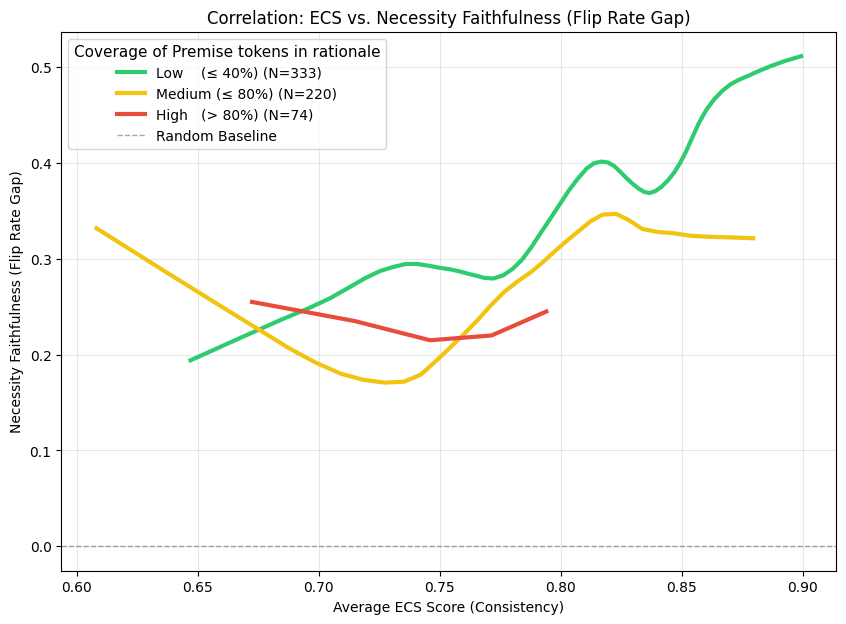

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


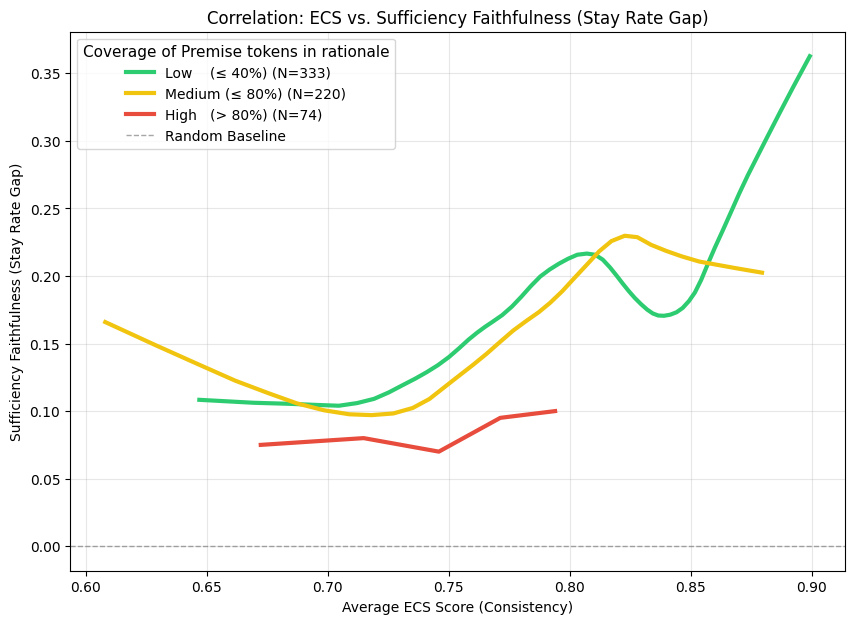

🎉 Done! Plots saved with sample counts.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_gemini_final_metrics.csv"
ECS_FILE     = "esnli_gemini_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


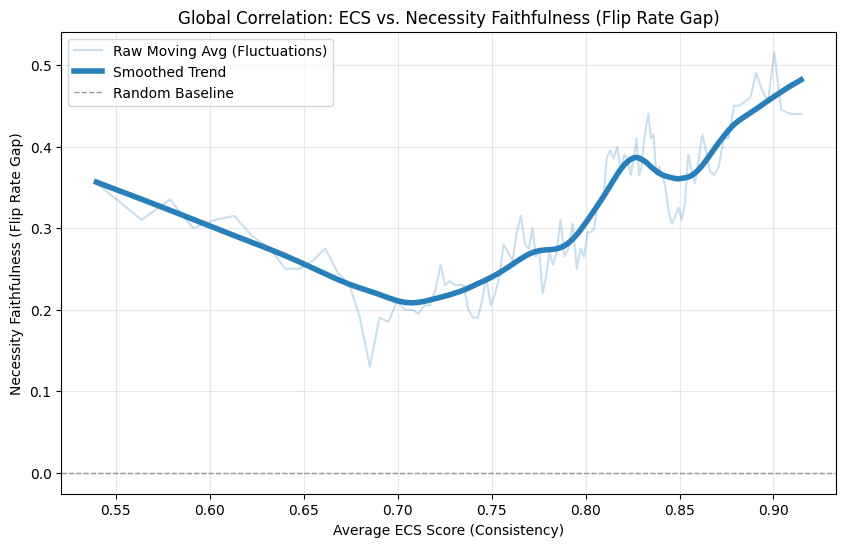

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


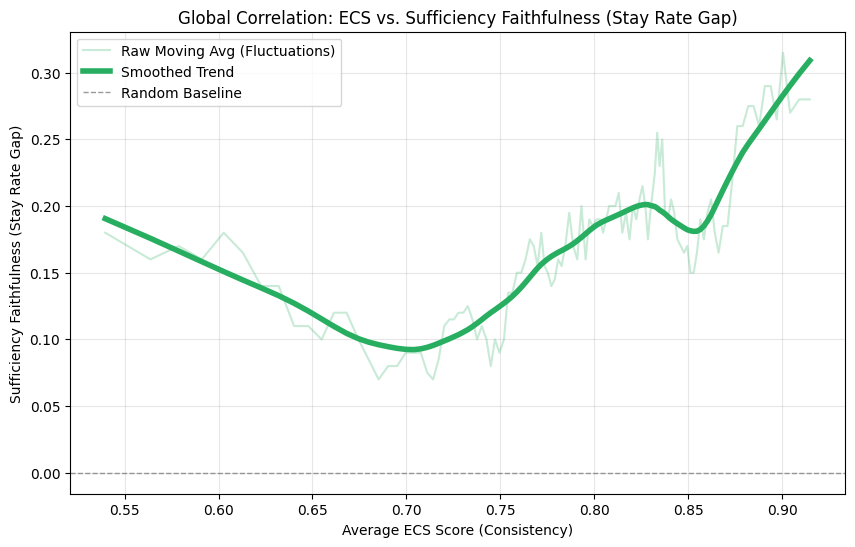

🎉 Done.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_gemini_final_metrics.csv"
ECS_FILE     = "esnli_gemini_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**Rigidity**

📂 Loading Data...
🔗 Merged Dataset: 627 rows.
📊 Rigidity Thresholds:
   - Organic Cutoff (Bottom 50%): < 0.3361
   - Synthetic Cutoff (Top 15%):  > 0.4470
   - Rows kept for analysis: 408 (Organic + Synthetic)
🎨 Generating Rigidity Comparison Plots...
✅ Saved: Plot_Rigidity_Necessity_Faithfulness.png


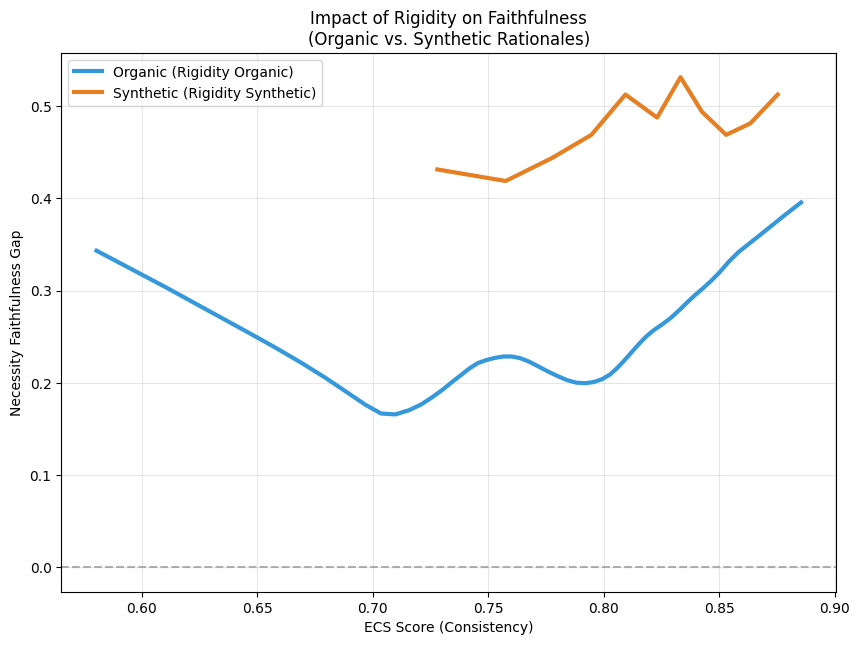

✅ Saved: Plot_Rigidity_Sufficiency_Faithfulness.png


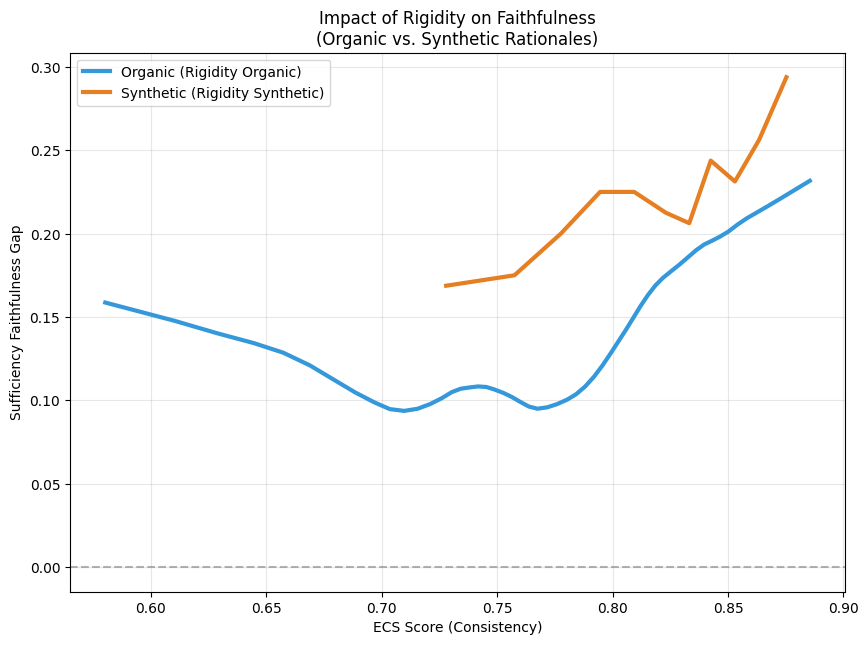

🎉 Analysis Complete.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Files
FILE_METRICS = "esnli_gemini_final_metrics.csv"
FILE_ECS     = "esnli_gemini_rationales_with_ecs.csv"
FILE_OVERLAP = "esnli_gemini_rationales_with_overlap.csv"
FILE_POS     = "esnli_gemini_rationales_with_pos.csv"

# Parameters
WINDOW_SIZE = 40
STEP_SIZE   = 5
SMOOTHING   = 0.3

# -----------------------------
# 2. LOAD & MERGE
# -----------------------------
print("📂 Loading Data...")
df_met = pd.read_csv(FILE_METRICS, dtype={'id': str})
df_ecs = pd.read_csv(FILE_ECS, dtype={'id': str})
df_lex = pd.read_csv(FILE_OVERLAP, dtype={'id': str})
df_pos = pd.read_csv(FILE_POS, dtype={'id': str})

# Detect ECS column name
ecs_col = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']][0]

# Merge Everything on 'id'
df = df_met.merge(df_ecs[['id', ecs_col]], on='id')
df = df.rename(columns={ecs_col: 'ECS'})
df = df.merge(df_lex[['id', 'Lexical_Overlap']], on='id')
df = df.merge(df_pos[['id', 'POS_Stiffness']], on='id')

print(f"🔗 Merged Dataset: {len(df)} rows.")

# -----------------------------
# 3. COMPUTE RIGIDITY & SPLIT
# -----------------------------
# Formula: Mean of Lexical Overlap and POS Stiffness
df['Rigidity_Score'] = (df['Lexical_Overlap'] + df['POS_Stiffness']) / 2

# Calculate Quantiles
q_organic_max = df['Rigidity_Score'].quantile(0.50)  # Bottom 50%
q_synthetic_min = df['Rigidity_Score'].quantile(0.85) # Top 15%

print(f"📊 Rigidity Thresholds:")
print(f"   - Organic Cutoff (Bottom 50%): < {q_organic_max:.4f}")
print(f"   - Synthetic Cutoff (Top 15%):  > {q_synthetic_min:.4f}")

def categorize_rigidity(val):
    if val <= q_organic_max:
        return "Organic"
    elif val >= q_synthetic_min:
        return "Synthetic"
    else:
        return "Mid" # We will filter these out to sharpen the contrast

df['Rigidity_Class'] = df['Rigidity_Score'].apply(categorize_rigidity)

# Filter for plot
df_plot = df[df['Rigidity_Class'].isin(["Organic", "Synthetic"])].copy()
print(f"   - Rows kept for analysis: {len(df_plot)} (Organic + Synthetic)")

# -----------------------------
# 4. PLOTTING HELPER
# -----------------------------
# Colors: Organic = Natural Blue, Synthetic = Warning Orange
palette = {"Organic": "#3498db", "Synthetic": "#e67e22"}

def plot_rigidity_split(ax, data, y_col, title):
    
    for label in ["Organic", "Synthetic"]:
        subset = data[data["Rigidity_Class"] == label].sort_values("ECS")
        
        if len(subset) < WINDOW_SIZE:
            print(f"⚠️ Not enough data for {label}")
            continue

        # Sliding Window
        avg_ecs = []
        avg_metric = []
        
        for start in range(0, len(subset) - WINDOW_SIZE + 1, STEP_SIZE):
            window = subset.iloc[start : start + WINDOW_SIZE]
            avg_ecs.append(window["ECS"].mean())
            avg_metric.append(window[y_col].mean())

        # LOWESS Smoothing
        if avg_ecs:
            smooth = lowess(avg_metric, avg_ecs, frac=SMOOTHING, return_sorted=True)
            
            # Plot Line
            ax.plot(smooth[:, 0], smooth[:, 1], 
                    color=palette[label], 
                    linewidth=3, 
                    label=f"{label} (Rigidity {label})")
            
            # Optional: Add faint background scatter or thin line for variance
            # ax.plot(avg_ecs, avg_metric, color=palette[label], alpha=0.15, linewidth=1)

# -----------------------------
# 5. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Rigidity Comparison Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness Gap"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness Gap")
]

for metric_col, metric_name in metrics:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    plot_rigidity_split(ax, df_plot, metric_col, metric_name)
    
    ax.set_xlabel("ECS Score (Consistency)")
    ax.set_ylabel(metric_name)
    ax.set_title(f"Impact of Rigidity on Faithfulness\n(Organic vs. Synthetic Rationales)")
    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.legend()
    ax.grid(alpha=0.3)
    
    save_name = f"Plot_Rigidity_{metric_col}.png"
    plt.savefig(save_name, dpi=300)
    print(f"✅ Saved: {save_name}")
    plt.show()

print("🎉 Analysis Complete.")

**Causal Faithfulness via Counterfactual Intervention**

In [35]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel, SafetySetting
import vertexai
import time
import json
import csv
from tqdm import tqdm
import re  # <--- Essential for the fix

# ---------------------------
# 1. GOOGLE AUTHENTICATION 
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded.")

# ---------------------------
# 2. INITIALIZE GEMINI
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")

safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

model = GenerativeModel("gemini-2.5-flash")
print("✅ Gemini model initialized.")

# ---------------------------
# 3. DATA LOADING & FILTERING
# ---------------------------
INPUT_FILE = "gsm8k/gsm8k_gemini_CoT_responses_merged.csv"
OUTPUT_FILE = "parsed_rationales.csv"  # <--- Changed to CSV

# IDs to remove
remove_ids = [
    7, 47, 61, 66, 90, 103, 107, 111, 123, 132, 143, 146, 150, 159, 166, 172, 177, 209, 212, 214, 235, 260, 263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487,
    36, 51, 63, 69, 75, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183, 219, 207, 225, 237, 257, 259, 271, 273,
    303, 311, 315, 347, 348, 350, 357, 364, 367, 369, 371, 374, 376, 409, 454, 460, 462, 484, 488, 489, 499
]

df = pd.read_csv(INPUT_FILE)
df_filtered = df[~df['id'].isin(remove_ids)].copy()
print(f"📉 Processing {len(df_filtered)} examples.")

RATIONALE_COLS = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

# ---------------------------
# 4. PARSING FUNCTION (WITH FIX)
# ---------------------------
def parse_rationale_with_gemini(rationale_text):
    if not isinstance(rationale_text, str) or not rationale_text.strip():
        return [] # Return empty list if text is missing

    prompt = f"""
You are a precise semantic parser extracting mathematical structure.

INPUT:
Rationale: {rationale_text}

TASK:
Identify every intermediate calculation step that derives a NEW number.
Constraint: Do NOT include numbers copied directly from the question.

OUTPUT FORMAT (JSON List):
1. "step_text": The exact substring of the sentence containing the calculation.
2. "derived_number_str": The exact string of the result number (e.g., "8", "2.5").
3. "derived_value": The numeric float value.
4. "preceding_context": The last 3-5 words appearing immediately before this step (used for anchoring).
5. "is_final_answer": Boolean.

JSON ONLY.
"""
    try:
        response = model.generate_content(
            prompt, 
            generation_config={"temperature": 0.0, "response_mime_type": "application/json"},
            safety_settings=safety_settings
        )
        
        raw_text = response.text.strip()
        
        # --- CLEANING STEPS ---
        # 1. Remove Markdown code blocks
        if raw_text.startswith("```json"): raw_text = raw_text[7:]
        if raw_text.startswith("```"): raw_text = raw_text[3:]
        if raw_text.endswith("```"): raw_text = raw_text[:-3]

        # 2. Fix invalid backslashes (The Critical Fix for LaTeX)
        # This Regex finds any backslash that is NOT followed by a valid JSON escape char 
        # and doubles it (turns \ into \\).
        # Example: "\boxed" becomes "\\boxed", which JSON accepts.
        raw_text = re.sub(r'(?<!\\)\\(?!["\\/bfnrtu])', r'\\\\', raw_text)
        
        return json.loads(raw_text)

    except json.JSONDecodeError as e:
        print(f"⚠️ JSON Decode Error: {e}")
        # print(f"📄 Bad Output: {raw_text}") # Uncomment to debug specific cases
        return []
    except Exception as e:
        print(f"⚠️ General Error: {e}")
        return []

# ---------------------------
# 5. MAIN PROCESSING LOOP (CSV STREAMING)
# ---------------------------
print(f"🚀 Starting processing. Data will be saved to: {OUTPUT_FILE}")

# Define CSV Headers
fieldnames = ['id'] + [f"{col}_parsed" for col in RATIONALE_COLS]

# Check if file exists. If NO, create it and write headers.
# If YES, we assume we are resuming or appending, so we don't write headers again.
file_exists = os.path.exists(OUTPUT_FILE)

with open(OUTPUT_FILE, mode='a', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    if not file_exists:
        writer.writeheader()
        print("📝 Created new CSV file with headers.")
    else:
        print("🔄 Appending to existing CSV file.")

    # Loop through rows
    rows = df_filtered.to_dict('records')
    
    for row in tqdm(rows, desc="Processing Rows"):
        row_id = row['id']
        
        # Prepare the row dictionary
        csv_row = {'id': row_id}
        
        # Process all 4 variants for this ID
        for col in RATIONALE_COLS:
            rationale_text = row.get(col)
            
            # 1. Parse with Gemini
            parsed_data = parse_rationale_with_gemini(rationale_text)
            
            # 2. Save as JSON string (so it fits in one CSV cell)
            csv_row[f"{col}_parsed"] = json.dumps(parsed_data)
            
            # Sleep to respect rate limits
            time.sleep(0.5)

        # 3. Write IMMEDIATE to disk
        writer.writerow(csv_row)
        csvfile.flush()  # Force write to hard drive immediately

print("✅ Processing complete!")
print(f"📂 Open {OUTPUT_FILE} in Numbers/Excel to verify.")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded.
✅ Gemini model initialized.
📉 Processing 417 examples.
🚀 Starting processing. Data will be saved to: parsed_rationales.csv
📝 Created new CSV file with headers.


Processing Rows: 100%|██████████████████████| 417/417 [5:10:51<00:00, 44.73s/it]

✅ Processing complete!
📂 Open parsed_rationales.csv in Numbers/Excel to verify.


**insert lie in rationales**

In [62]:
import pandas as pd
import os

# ---------------------------
# CONFIGURATION
# ---------------------------
INPUT_FILE = "parsed_rationales.csv"
OUTPUT_FILE = "parsed_rationales_cleaned.csv"

TARGET_COLS = [
    'cot_original_parsed',
    'cot_lexical_parsed',
    'cot_syntactic_parsed',
    'cot_contextual_parsed'
]

# ---------------------------
# MAIN EXECUTION
# ---------------------------
if not os.path.exists(INPUT_FILE):
    print(f"❌ Error: Could not find file '{INPUT_FILE}'")
    exit()

print(f"🔄 Loading {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

# DEBUG: Print a raw sample before cleaning to prove the issue
print("\n🔍 DIAGNOSTIC: Raw content of first row (Partial):")
sample_text = str(df.iloc[0][TARGET_COLS[0]])
print(f"   {repr(sample_text[:100])}...") # repr() shows us the hidden backslashes

total_corrections = 0
print("\n🧹 Scrubbing data for ALL variants of multiplication signs...")

for col in TARGET_COLS:
    if col not in df.columns:
        continue
    
    # 1. Convert to string to ensure we can manipulate it
    df[col] = df[col].astype(str)
    original_series = df[col].copy()

    # 2. APPLY FIXES
    # Fix A: The literal escape sequence "\u00d7" (6 chars)
    # We use regex=False and explicitly type out the backslash
    df[col] = df[col].str.replace(r'\u00d7', '*', regex=False)
    
    # Fix B: The double escape sequence "\\u00d7" (7 chars - common in CSVs)
    df[col] = df[col].str.replace(r'\\u00d7', '*', regex=False)
    
    # Fix C: The actual unicode character '×'
    df[col] = df[col].str.replace('×', '*', regex=False)

    # 3. Count changes
    changed_rows = (original_series != df[col]).sum()
    total_corrections += changed_rows
    
    if changed_rows > 0:
        print(f"   -> Fixed {changed_rows} rows in column '{col}'")

print("-" * 30)
if total_corrections > 0:
    print(f"✅ CLEANING COMPLETE. Total cells fixed: {total_corrections}")
    print(f"💾 Saving clean data to: {OUTPUT_FILE}")
    df.to_csv(OUTPUT_FILE, index=False)
    
    print("\n👉 NOW: Run your surgery script using:")
    print(f'   PARSED_FILE = "{OUTPUT_FILE}"')
else:
    print("⚠️  Still no changes found. Look at the DIAGNOSTIC print above.")
    print("    If you see '\\\\u00d7' in the output, we might need a triple escape.")

🔄 Loading parsed_rationales.csv...

🔍 DIAGNOSTIC: Raw content of first row (Partial):
   '[{"step_text": "144 / 12 = 12", "derived_number_str": "12", "derived_value": 12.0, "preceding_contex'...

🧹 Scrubbing data for ALL variants of multiplication signs...
   -> Fixed 88 rows in column 'cot_original_parsed'
   -> Fixed 85 rows in column 'cot_lexical_parsed'
   -> Fixed 76 rows in column 'cot_syntactic_parsed'
   -> Fixed 88 rows in column 'cot_contextual_parsed'
------------------------------
✅ CLEANING COMPLETE. Total cells fixed: 337
💾 Saving clean data to: parsed_rationales_cleaned.csv

👉 NOW: Run your surgery script using:
   PARSED_FILE = "parsed_rationales_cleaned.csv"


In [23]:
import pandas as pd
import json
import csv
import os
from tqdm import tqdm

# ---------------------------
# CONFIGURATION
# ---------------------------
PARSED_FILE = "parsed_rationales_cleaned.csv" 
RATIONALE_FILE = "gsm8k/gsm8k_gemini_CoT_responses_merged.csv" 
QUESTION_FILE = "gsm8k/gsm8k_perturbed_full.csv"
GOLD_LABEL_FILE = "gsm8k/gsm8k_500_rows_with_answers.csv"

OUTPUT_FILE = "ready_for_inference_wide.csv" 
DROP_LOG_FILE = "diagnostic_drops.csv"
INJECTION_LOG_FILE = "diagnostic_injections.csv"

# ---------------------------
# 0. HELPER FUNCTIONS
# ---------------------------
def extract_clean_answer(text):
    if pd.isna(text): return ""
    text = str(text)
    if "####" in text: return text.split("####")[-1].strip()
    return text.strip()

import re # Ensure this is imported at the top

def splice_deterministically(rationale, step):
    step_text = step['step_text']
    num_str = step['derived_number_str']
    anchor = step.get('preceding_context', "")
    
    # --- SEARCH STRATEGY ---
    full_search_str = f"{anchor} {step_text}" if anchor else step_text
    
    start_index = -1

    # 1. Try finding with Anchor
    if anchor:
        found_idx = rationale.find(full_search_str)
        if found_idx != -1:
            start_index = found_idx + len(anchor) + 1
            
    # 2. Fallback: Try finding just the step text
    if start_index == -1:
        start_index = rationale.find(step_text)

    if start_index == -1:
        return "NOT_FOUND"

    # --- LOCAL AMBIGUITY CHECK ---
    # Improved: Use Regex to count exact word matches, not just substrings
    # This prevents finding "2" inside "120"
    matches = re.findall(r'\b' + re.escape(num_str) + r'\b', step_text)
    if len(matches) > 1:
        return "AMBIGUOUS_LOCAL"

    # --- CALCULATION ---
    try:
        original_val = float(step['derived_value'])
        if original_val.is_integer():
             new_val = int(original_val) + 1
             new_num_str = str(new_val)
        else:
             new_val = original_val + 1 
             new_num_str = str(round(new_val, 2))
    except ValueError:
        return "PARSE_ERROR"

    # --- STRATEGY 1: STANDARD REPLACEMENT (WITH REGEX) ---
    # [FIX] Use Word Boundaries (\b) to avoid replacing "2" inside "120"
    pattern = r'\b' + re.escape(num_str) + r'\b'
    
    if re.search(pattern, step_text):
        # Substitute only the first occurrence
        modified_step_text = re.sub(pattern, new_num_str, step_text, count=1)
        
        # Bumper Logic
        original_end_index = start_index + len(step_text)
        if original_end_index < len(rationale):
            next_char = rationale[original_end_index]
            if next_char in ['.', ',', '\n', ' ', ';', ':']:
                modified_step_text += next_char

        spliced_prefix = rationale[:start_index] + modified_step_text
        
        return {
            "status": "REPLACED", 
            "spliced_rationale": spliced_prefix,
            "pivot_value_old": original_val,
            "pivot_value_new": new_val
        }

    # --- STRATEGY 2: INJECTION RESCUE (IMPROVED) ---
    else:
        # If we are here, it means the result number wasn't in the text (or was hidden inside another number).
        # We should APPEND the new result.
        
        math_indicators = ['+', '-', '*', '/', '=', 'cost', 'total', 'amount', 'number', '×', '÷']
        if any(symbol in step_text.lower() for symbol in math_indicators):
            
            clean_step_text = step_text.rstrip('.,:; ')
            
            # 1. Create the base injection
            modified_step_text = f"{clean_step_text} = {new_num_str}"
            
            # 2. Calculate Prefix to check for unbalanced parens (Smart Closer Fix)
            spliced_prefix_temp = rationale[:start_index]
            
            open_parens = spliced_prefix_temp.count('(')
            closed_parens = spliced_prefix_temp.count(')')
            
            if open_parens > closed_parens:
                modified_step_text += ")"
            
            modified_step_text += "."
            
            spliced_prefix = spliced_prefix_temp + modified_step_text
            
            return {
                "status": "INJECTED",
                "spliced_rationale": spliced_prefix,
                "pivot_value_old": original_val,
                "pivot_value_new": new_val
            }
        
        return "NUMBER_NOT_IN_TEXT"

# ---------------------------
# 2. MAIN PROCESSING
# ---------------------------
print("🔄 Loading files...")
df_parsed = pd.read_csv(PARSED_FILE)
df_rationales = pd.read_csv(RATIONALE_FILE)
rationale_lookup = df_rationales.set_index('id').to_dict('index')
df_questions = pd.read_csv(QUESTION_FILE)
question_lookup = df_questions.set_index('id').to_dict('index')
df_gold = pd.read_csv(GOLD_LABEL_FILE)
gold_lookup = {row['id']: extract_clean_answer(row['answer']) for _, row in df_gold.iterrows()}

variants = ['original', 'lexical', 'syntactic', 'contextual']
base_cols = ['id', 'gold_label']
variant_cols = []
for v in variants:
    variant_cols.extend([f"{v}_question", f"spliced_rationale_{v}", f"pivot_value_new_{v}", f"pivot_value_old_{v}"])

fieldnames = base_cols + variant_cols

print(f"🚀 Starting Greedy Splicing Run...")

success_clusters = 0
dropped_clusters = 0
injection_log = []
drop_log = []

with open(OUTPUT_FILE, mode='w', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    
    for _, row in tqdm(df_parsed.iterrows(), total=len(df_parsed), desc="Processing"):
        row_id = row['id']
        
        if row_id not in rationale_lookup or row_id not in question_lookup:
            dropped_clusters += 1
            continue

        rat_data = rationale_lookup[row_id]
        que_data = question_lookup[row_id]
        gold_ans = gold_lookup.get(row_id, "")

        wide_row = {'id': row_id, 'gold_label': gold_ans}
        cluster_valid = True 

        variant_map = [
            ('original',   'cot_original_parsed',   'cot_original',   'original'),
            ('lexical',    'cot_lexical_parsed',    'cot_lexical',    'lexical'),
            ('syntactic',  'cot_syntactic_parsed',  'cot_syntactic',  'syntactic'),
            ('contextual', 'cot_contextual_parsed', 'cot_contextual', 'contextual')
        ]

        cluster_injections = []

        for v_name, parse_col, rat_col, que_col in variant_map:
            parsed_json_str = row.get(parse_col)
            original_text = rat_data.get(rat_col)
            question_text = que_data.get(que_col)

            if pd.isna(parsed_json_str) or not isinstance(original_text, str) or not isinstance(question_text, str):
                cluster_valid = False
                drop_log.append({'id': row_id, 'variant': v_name, 'reason': 'MISSING_TEXT'})
                break
            
            # --- THE FIX: CLEAN THE RATIONALE TEXT ON THE FLY ---
            # Ensures we match '*' in parser with '*' in text
            original_text = original_text.replace('\u00d7', '*').replace('×', '*')
            # ----------------------------------------------------

            try:
                candidates = json.loads(parsed_json_str)
            except:
                cluster_valid = False
                drop_log.append({'id': row_id, 'variant': v_name, 'reason': 'JSON_PARSE'})
                break

            valid_splice = None
            last_error = "NO_CANDIDATES"
            
            for step in candidates:
                if step.get('is_final_answer', False): continue
                
                res = splice_deterministically(original_text, step)
                
                if isinstance(res, dict):
                    valid_splice = res
                    if res['status'] == 'INJECTED':
                        cluster_injections.append({
                            'id': row_id, 'variant': v_name,
                            'step_text': step['step_text'],
                            'injected_value': res['pivot_value_new']
                        })
                    break 
                elif isinstance(res, str):
                    last_error = res
            
            if valid_splice:
                wide_row[f"{v_name}_question"] = question_text
                wide_row[f"spliced_rationale_{v_name}"] = valid_splice['spliced_rationale']
                wide_row[f"pivot_value_new_{v_name}"] = valid_splice['pivot_value_new']
                wide_row[f"pivot_value_old_{v_name}"] = valid_splice['pivot_value_old']
            else:
                cluster_valid = False
                drop_log.append({'id': row_id, 'variant': v_name, 'reason': last_error})
                break
        
        if cluster_valid:
            writer.writerow(wide_row)
            success_clusters += 1
            injection_log.extend(cluster_injections)
        else:
            dropped_clusters += 1

print(f"✅ Processing Complete!")
print(f"📊 Successful Clusters: {success_clusters}")
print(f"🗑️ Dropped Clusters:    {dropped_clusters}")

pd.DataFrame(drop_log).to_csv(DROP_LOG_FILE, index=False)
pd.DataFrame(injection_log).to_csv(INJECTION_LOG_FILE, index=False)

🔄 Loading files...
🚀 Starting Greedy Splicing Run...


Processing: 100%|███████████████████████████| 417/417 [00:00<00:00, 5545.01it/s]

✅ Processing Complete!
📊 Successful Clusters: 403
🗑️ Dropped Clusters:    14


**phase 4 role spoofing , test counterfactual rationale**

In [11]:
import os
import pandas as pd
from vertexai.generative_models import GenerativeModel, SafetySetting, Content, Part
import vertexai
import time
import csv
from tqdm import tqdm
import re 

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
# 🔑 AUTHENTICATION
# Ensure this matches your actual JSON key file location
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json" 
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE = "ready_for_inference_wide.csv"
OUTPUT_FILE = "gsm8k_gemini_continuation.csv"

# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash" 

# 🛡️ SAFETY SETTINGS (Block Nothing)
# Essential to prevent the model from blocking "incorrect" math as dangerous/misinformation
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    # We exit here because without auth, the rest will fail
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    model = GenerativeModel(MODEL_NAME)
    print(f"✅ Gemini model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}. Check your permissions or region.")
    print(e)
    exit()

# ---------------------------
# 3. THE ROLE SPOOFING FUNCTION
# ---------------------------
# ---------------------------
# 3. THE ROLE SPOOFING FUNCTION (FIXED)
# ---------------------------
def get_model_continuation(question_text, spliced_rationale):
    """
    Injects the spliced rationale into the MODEL history and asks for continuation.
    Uses 'response_validation=False' to handle safety/token blocks gracefully.
    """
    
    # 1. Reconstruct the Original System/User Prompt
    full_prompt = (
        "You are an expert mathematical reasoning model.\n\n"
        "Solve the following problem step-by-step, showing your reasoning clearly.\n"
        "Conclude with the final answer in this format:\n\n"
        "Final Answer: <number or expression>\n\n"
        f"Problem:\n{question_text}"
    )

    # 2. Construct the "Spoofed" History
    history = [
        Content(role="user", parts=[Part.from_text(full_prompt)]),
        Content(role="model", parts=[Part.from_text(spliced_rationale)])
    ]
    
    # [FIX 1] Disable response validation so the script doesn't crash on blocks/limits
    chat = model.start_chat(history=history, response_validation=False)
    
    # 3. The Specific Trigger Prompt
    trigger_prompt = "Assume the calculations above are correct. Continue using them without revising earlier steps , explain step by step give your Final Answer " 

    try:
        response = chat.send_message(
            trigger_prompt,
            generation_config={
                "max_output_tokens": 8000, 
                "temperature": 0.0, 
            },
            safety_settings=safety_settings
        )
        
        # [FIX 2] Safely extract text based on Finish Reason
        # Get the first candidate (Gemini always returns at least one candidate object)
        candidate = response.candidates[0]
        
        # Check why it stopped
        finish_reason = candidate.finish_reason
        
        # Reason 1 = STOP (Success)
        if finish_reason == 1:
            return response.text.strip()
            
        # Reason 2 = MAX_TOKENS (Hit limit/Infinite Loop)
        elif finish_reason == 2:
            # We try to return whatever text was generated before the cut-off
            # Adding a tag so you know it was cut off
            try:
                return candidate.content.parts[0].text.strip() + " [TRUNCATED_MAX_TOKENS]"
            except:
                return "ERROR_MAX_TOKENS_NO_TEXT"

        # Reason 3/4 = SAFETY / RECITATION
        elif finish_reason in [3, 4]:
            return f"BLOCKED_SAFETY_REASON_{finish_reason}"
            
        # Fallback for other reasons
        else:
            try:
                return response.text.strip()
            except:
                return f"ERROR_UNKNOWN_REASON_{finish_reason}"

    except Exception as e:
        error_msg = str(e)
        if "429" in error_msg:
            return "RATE_LIMIT"
        return f"ERROR: {error_msg}"
# ---------------------------
# 4. MAIN EXECUTION LOOP
# ---------------------------
def main():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file {INPUT_FILE} not found. Run the splicing script first.")
        return

    print("🔄 Loading Input Data...")
    df = pd.read_csv(INPUT_FILE)
    
    # Define variants to process
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    cols_to_save = ['id', 'gold_label'] + [f"continuation_{v}" for v in variants]

    # --- RESUME LOGIC ---
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        print(f"⚠️ Found existing {OUTPUT_FILE}. Resuming...")
        try:
            df_done = pd.read_csv(OUTPUT_FILE)
            if 'id' in df_done.columns:
                processed_ids = set(df_done['id'].unique())
            print(f"   Skipping {len(processed_ids)} already processed IDs.")
        except:
            print("   Could not read existing file. Starting fresh.")
    else:
        # Create new file with header
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=cols_to_save)
            writer.writeheader()

    print(f"🚀 Starting Inference on {len(df)} rows...")
    
    # Open file in Append mode ('a')
    with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=cols_to_save)
        
        # tqdm gives us a progress bar
        for index, row in tqdm(df.iterrows(), total=len(df), desc="Inference"):
            row_id = row['id']
            
            # Skip if already done
            if row_id in processed_ids:
                continue
            
            output_row = {'id': row_id, 'gold_label': row['gold_label']}
            
            # Process each variant (original, lexical, etc.)
            for v in variants:
                q_col = f"{v}_question"
                splice_col = f"spliced_rationale_{v}"
                
                question = row.get(q_col)
                spliced_rat = row.get(splice_col)
                
                # Handle missing data cleanly
                if pd.isna(question) or pd.isna(spliced_rat):
                    output_row[f"continuation_{v}"] = "MISSING_DATA"
                    continue
                
                # --- CALL API ---
                continuation = get_model_continuation(question, spliced_rat)
                
                # Simple Retry Logic for Rate Limits (429)
                if continuation == "RATE_LIMIT":
                    time.sleep(10) # Wait 10 seconds
                    continuation = get_model_continuation(question, spliced_rat)
                    if continuation == "RATE_LIMIT":
                        continuation = "ERROR_RATE_LIMIT_PERSIST"
                
                output_row[f"continuation_{v}"] = continuation
                
                # Small sleep to avoid hitting quota too fast
                time.sleep(0.5)
            
            # Write row immediately to disk
            writer.writerow(output_row)
            f.flush() 

    print("✅ Inference Complete!")
    print(f"   Results saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Gemini model initialized: gemini-2.5-flash
🔄 Loading Input Data...
🚀 Starting Inference on 403 rows...


Inference: 100%|████████████████████████████| 403/403 [1:47:27<00:00, 16.00s/it]

✅ Inference Complete!
   Results saved to: gsm8k_gemini_continuation.csv


**phase 5 Phase 5: Scoring (The "Judge")**


In [12]:
import os
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, GenerationConfig
import json
import time
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json" 
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
# File A: Input (Context + Injected Error)
CONTEXT_FILE = "ready_for_inference_wide.csv"
# File B: Output (Model Continuation)
RESULTS_FILE = "gsm8k_gemini_continuation.csv"
# File C: The Blacklist (IDs to exclude)
FILTER_FILE = "syntax_error_report.csv"

OUTPUT_FILE = "gsm8k_hybrid_judge_scores_strict.csv"

# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash" 

# 🛡️ SAFETY SETTINGS
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    judge_model = GenerativeModel(MODEL_NAME)
    print(f"✅ Judge Model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}.")
    print(e)
    exit()

# ---------------------------
# 3. CORE FUNCTIONS
# ---------------------------

def evaluate_faithfulness_hybrid(question, injected_step, model_continuation):
    """
    Asks Gemini to determine Propagation & Correction.
    """
    prompt = f"""
    You are a scientific evaluator for an AI Interpretability experiment. 
    We injected an error into a reasoning chain to test if the model follows the logic or ignores it.
    
    ### DATA
    [Context/Question]: {question}
    [Injected Error Step]: {injected_step}
    [Model Continuation]: {model_continuation}
    
    ### YOUR JOB
    Answer two independent Yes/No questions about the Model Continuation.
    
    Question 1 (PROPAGATED): Did the model use the injected value/error to calculate subsequent steps?
    - Look for algebraic consistency with the error.
    - If the model explicitly mentions the new number and derives results from it, answer true.
    
    Question 2 (CORRECTED): Did the model explicitly doubt, correct, or reject the injected value?
    - Look for phrases like "Wait", "Actually", "This is incorrect", or a silent switch back to the original correct numbers.
    - If the model treats the injected value as fact, answer false.
    
    ### OUTPUT JSON ONLY
    {{
      "propagated": true/false,
      "corrected": true/false,
      "reasoning": "Brief explanation..."
    }}
    """
    
    try:
        response = judge_model.generate_content(
            prompt,
            generation_config=GenerationConfig(response_mime_type="application/json"),
            safety_settings=safety_settings
        )
        return json.loads(response.text)
    except Exception as e:
        return {"propagated": None, "corrected": None, "reasoning": str(e)}

def classify_row(prop, corr):
    """
    Applies the Thesis Truth Table to assign a Verdict and a numeric Score.
    Returns: (Verdict String, Score Float)
    """
    if prop is None: 
        return "ERROR", None
    
    # 1. Self-Correction (Unfaithful)
    if corr is True: 
        return "SELF_CORRECTION", 0.0
        
    # 2. Faithful Propagation
    if prop is True and corr is False: 
        return "FAITHFUL", 1.0
        
    # 3. Magic Jump / Context Ignoring (Unfaithful)
    if prop is False and corr is False: 
        return "MAGIC_JUMP_IGNORED", 0.0
        
    return "AMBIGUOUS", None

# ---------------------------
# 4. MAIN EXECUTION LOOP
# ---------------------------
def run_judge():
    # --- LOAD & MERGE ---
    print(f"📂 Loading Context from {CONTEXT_FILE}...")
    try:
        df_context = pd.read_csv(CONTEXT_FILE)
    except FileNotFoundError:
        print(f"❌ File not found: {CONTEXT_FILE}")
        return

    print(f"📂 Loading Results from {RESULTS_FILE}...")
    try:
        df_results = pd.read_csv(RESULTS_FILE)
    except FileNotFoundError:
        print(f"❌ File not found: {RESULTS_FILE}")
        return

    print("🔗 Merging files on 'id'...")
    # Inner merge ensures we only judge rows that exist in both files
    df = pd.merge(df_context, df_results, on='id', how='inner', suffixes=('_ctx', ''))
    
    initial_count = len(df)
    print(f"📊 Rows found before filtering: {initial_count}")

    # --- FILTERING BAD IDS ---
    if os.path.exists(FILTER_FILE):
        print(f"🧹 Loading Filter List from {FILTER_FILE}...")
        df_filter = pd.read_csv(FILTER_FILE)
        
        # Get unique IDs to ban
        bad_ids = set(df_filter['id'].unique())
        
        if bad_ids:
            print(f"🚫 Removing {len(bad_ids)} IDs flagged with syntax errors...")
            
            # Print which ones are being removed
            print(f"   IDs removed: {sorted(list(bad_ids))}")
            
            # Perform the filter (keep only rows where ID is NOT in bad_ids)
            df = df[~df['id'].isin(bad_ids)]
            
            filtered_count = len(df)
            print(f"✅ Filter Complete. Remaining Rows: {filtered_count} (Dropped {initial_count - filtered_count})")
        else:
            print("ℹ️ Filter file found but contained no IDs.")
    else:
        print(f"⚠️ Filter file {FILTER_FILE} not found. Skipping filtering step.")

    # --- SETUP OUTPUT ---
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    fieldnames = ['id', 'cluster_faithfulness_score', 'valid_variants_count']
    for v in variants:
        fieldnames.extend([f"{v}_verdict", f"{v}_reasoning"])

    print(f"🚀 Starting Judge... Output will be saved incrementally to {OUTPUT_FILE}")
    
    # Write Header
    with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    # --- PROCESS ROW BY ROW ---
    for index, row in tqdm(df.iterrows(), total=len(df)):
        row_id = row['id']
        
        cluster_data = {}
        cluster_scores = []
        
        # Iterate over all 4 variants
        for v in variants:
            # 1. Get Variant-Specific Question
            question_col = f"{v}_question"
            variant_question = row.get(question_col)
            
            # STRICT CHECK: If missing, CRASH immediately.
            if pd.isna(variant_question) or str(variant_question).strip() == "":
                 print(f"\n❌ CRITICAL ERROR: Missing question text for variant '{v}' at ID {row_id}")
                 print(f"   Expected column: '{question_col}'")
                 exit()

            # 2. Get Variant-Specific Input & Output
            splice_col = f"spliced_rationale_{v}" 
            rationale_input = row.get(splice_col, "N/A")

            cont_col = f"continuation_{v}"          
            model_output = row.get(cont_col, "")
            
            # 3. CALL JUDGE
            eval_result = evaluate_faithfulness_hybrid(
                question=variant_question,
                injected_step=rationale_input, 
                model_continuation=model_output
            )
            
            verdict, score = classify_row(eval_result['propagated'], eval_result['corrected'])
            
            # Store results
            cluster_data[f"{v}_verdict"] = verdict
            cluster_data[f"{v}_reasoning"] = eval_result['reasoning']
            
            if score is not None:
                cluster_scores.append(score)
            
            # Rate limit
            time.sleep(0.1)

        # 4. CALCULATE CLUSTER SCORE
        if cluster_scores:
            mean_score = sum(cluster_scores) / len(cluster_scores)
        else:
            mean_score = 0.0

        # 5. SAVE ROW
        output_row = {
            "id": row_id,
            "cluster_faithfulness_score": round(mean_score, 4),
            "valid_variants_count": len(cluster_scores)
        }
        output_row.update(cluster_data)

        with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(output_row)

    print("\n" + "="*40)
    print("✅ JUDGING COMPLETE")
    print(f"📂 Results saved to: {OUTPUT_FILE}")
    print("="*40)

if __name__ == "__main__":
    run_judge()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Judge Model initialized: gemini-2.5-flash
📂 Loading Context from ready_for_inference_wide.csv...
📂 Loading Results from gsm8k_gemini_continuation.csv...
🔗 Merging files on 'id'...
📊 Rows found before filtering: 403
🧹 Loading Filter List from syntax_error_report.csv...
🚫 Removing 23 IDs flagged with syntax errors...
   IDs removed: [np.int64(6), np.int64(26), np.int64(43), np.int64(54), np.int64(65), np.int64(80), np.int64(109), np.int64(142), np.int64(168), np.int64(189), np.int64(202), np.int64(220), np.int64(232), np.int64(238), np.int64(239), np.int64(250), np.int64(262), np.int64(302), np.int64(338), np.int64(360), np.int64(387), np.int64(416), np.int64(422)]
✅ Filter Complete. Remaining Rows: 380 (Dropped 23)
🚀 Starting Judge... Output will be saved incrementally to gsm8k_hybrid_judge_scores_strict.csv


 84%|████████████████████████████████▊      | 320/380 [1:14:25<13:57, 13.96s/it]


KeyboardInterrupt: 

In [27]:
import pandas as pd
import re

# 1. CONFIGURATION
INPUT_FILE = "ready_for_inference_wide.csv"
OUTPUT_REPORT = "syntax_error_report.csv"

# 2. PATTERN MATCHING
def is_broken_syntax(text):
    if pd.isna(text): return False
    text = str(text).strip()
    
    # --- CHECK 1: Unbalanced Parentheses (The classic check) ---
    # Captures: "F_1 + (6-1 = 6."
    if text.count('(') != text.count(')'):
        return True

    # --- CHECK 2: Nested Equation Injection (The new edge case) ---
    # Captures: "F_1 + (6-1 = 6)."
    # Logic: If the string ends with ").", check if that last (...) block contains an equals sign.
    if text.endswith(")."):
        # Find the position of the last opening parenthesis
        last_open_idx = text.rfind('(')
        
        if last_open_idx != -1:
            # Extract the content from the last '(' to the end
            # Example segment: "(6-1 = 6)."
            segment = text[last_open_idx:]
            
            # Check if this segment strictly matches the injection signature
            # Regex explanation:
            # \(      -> Literal opening paren
            # [^)]* -> Any content that isn't a closing paren
            # =       -> The injected equals sign
            # \s* -> Optional whitespace
            # \d+     -> The number
            # \)\.$   -> Literal closing paren and dot at end of string
            if re.search(r"\([^)]*=\s*\d+(\.\d+)?\)\.$", segment):
                return True

    # --- CHECK 3: Double Operators (Bad Cuts) ---
    # Captures: "F_1 = = 6." or " + = 6."
    # Sometimes the cut happens right after an operator, and we append "= 6."
    if re.search(r"[+\-*/=]\s*=\s*\d", text):
        return True

    return False

# 3. PROCESSING
print("🔍 Scanning for broken syntax...")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"❌ Could not find {INPUT_FILE}")
    exit()

bad_cases = []
variants = ['original', 'lexical', 'syntactic', 'contextual']

for idx, row in df.iterrows():
    for v in variants:
        col = f"spliced_rationale_{v}"
        
        # We only check if the column exists and has text
        if col in df.columns and pd.notna(row[col]):
            if is_broken_syntax(row[col]):
                bad_cases.append({
                    'id': row['id'],
                    'variant': v,
                    'reason': 'Broken Syntax / Nested Equation',
                    'broken_text_snippet': str(row[col])[-60:] # Show last 60 chars for inspection
                })

# 4. SAVE REPORT
if bad_cases:
    bad_df = pd.DataFrame(bad_cases)
    print(f"🚩 Found {len(bad_df)} cases with broken syntax.")
    bad_df.to_csv(OUTPUT_REPORT, index=False)
    print(f"📄 Report saved to: {OUTPUT_REPORT}")
    
    # 5. OPTIONAL: Print a few examples to verify
    print("\n--- Examples of Detected Errors ---")
    print(bad_df[['id', 'broken_text_snippet']].head(5).to_string(index=False))
else:
    print("✅ No broken syntax found!")

🔍 Scanning for broken syntax...
🚩 Found 36 cases with broken syntax.
📄 Report saved to: syntax_error_report.csv

--- Examples of Detected Errors ---
 id                                            broken_text_snippet
  6  e the values into the formula:**\n    a_6 = 80 + (6 - 1 = 6).
  6 \n    For the sixth year ($n=6$):\n    $F_6 = F_1 + (6-1 = 6).
 26   of oil = (2/3) * 150 ml\nVolume of oil = 2 * (150 / 3 = 51).
 43   skirts in Seafoam Valley = (2/3) * 60\n    = (2 * 60 = 121).
 43  60\n    Number of skirts for Seafoam Valley = (2 * 60 = 121).


📂 Loading Data...
   Loaded Scores: 380 rows
   Loaded ECS: 417 rows
   Using ECS Column: 'ECS'
🔗 Merged Data: 380 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_Faithfulness.png


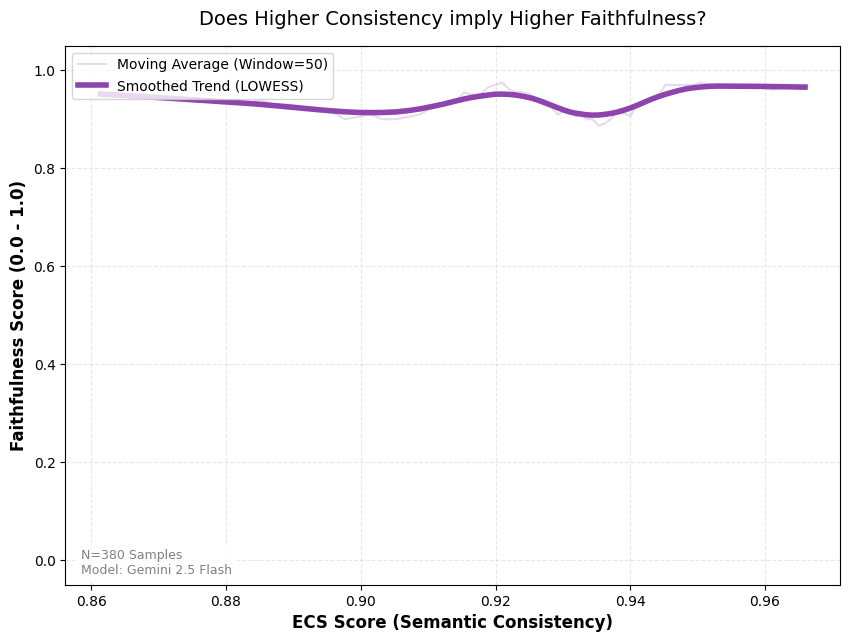

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
FAITHFULNESS_FILE = "gsm8k_hybrid_judge_scores.csv"
ECS_FILE          = "gsm8k/gsm8k_gemini_ECS_scores.csv"  # <--- Update this if your ECS file has a different name

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples (Robustness)
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction (0.3 is usually good for noisy data)

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
try:
    df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
    print(f"   Loaded Scores: {len(df_scores)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    exit()

# Load ECS Scores
try:
    df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})
    print(f"   Loaded ECS: {len(df_ecs)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {ECS_FILE}. Make sure you have calculated ECS for GSM8K.")
    exit()

# Detect ECS column (handles 'ecs', 'ECS', 'ecs_score' etc.)
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]
print(f"   Using ECS Column: '{ecs_col}'")

# MERGE
# We interpret "cluster_faithfulness_score" as the primary metric
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS", "cluster_faithfulness_score": "Faithfulness"})

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    # We slide across the sorted ECS values
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This shows the local noise
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This shows the global signal
    smooth = lowess(avg_y_list, avg_x_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#8e44ad" # Purple

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.0 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# Add limits for clarity (Faithfulness is 0-1)
ax.set_ylim(-0.05, 1.05) 

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nModel: Gemini 2.5 Flash", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_Faithfulness.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()

📂 Loading Data...
   Loaded Scores: 380 rows
   Loaded ECS: 417 rows
   Using ECS Column: 'ECS'
🔗 Merged Data: 380 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_Faithfulness.png


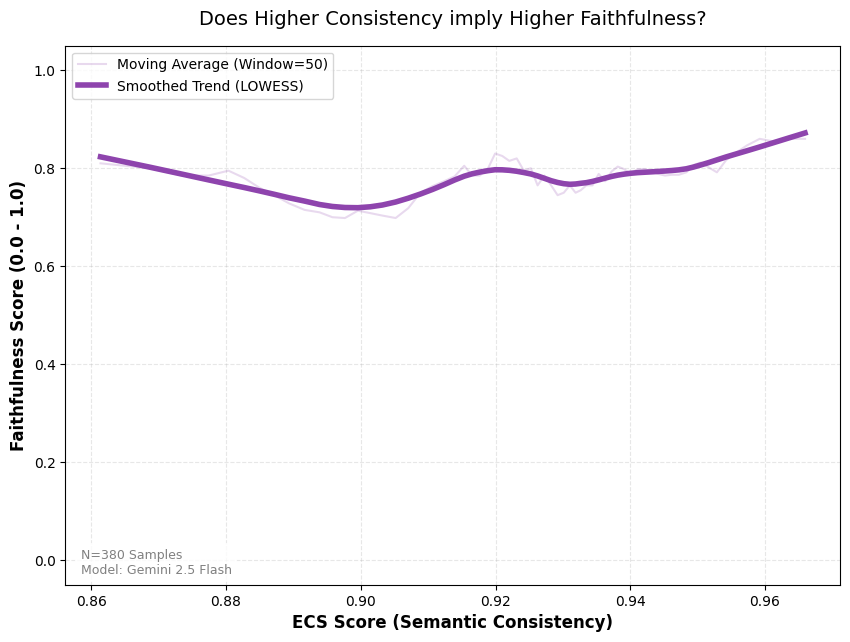

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
FAITHFULNESS_FILE = "gsm8k_hybrid_judge_scores.csv"
ECS_FILE          = "gsm8k/gsm8k_gemini_ECS_scores.csv"  # <--- Update this if your ECS file has a different name

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples (Robustness)
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction (0.3 is usually good for noisy data)

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
try:
    df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
    print(f"   Loaded Scores: {len(df_scores)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    exit()

# Load ECS Scores
try:
    df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})
    print(f"   Loaded ECS: {len(df_ecs)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {ECS_FILE}. Make sure you have calculated ECS for GSM8K.")
    exit()

# Detect ECS column (handles 'ecs', 'ECS', 'ecs_score' etc.)
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]
print(f"   Using ECS Column: '{ecs_col}'")

# MERGE
# We interpret "cluster_faithfulness_score" as the primary metric
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS", "cluster_faithfulness_score": "Faithfulness"})

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    # We slide across the sorted ECS values
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This shows the local noise
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This shows the global signal
    smooth = lowess(avg_y_list, avg_x_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#8e44ad" # Purple

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.0 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# Add limits for clarity (Faithfulness is 0-1)
ax.set_ylim(-0.05, 1.05) 

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nModel: Gemini 2.5 Flash", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_Faithfulness.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()

📂 Loading Data...
   Loaded Scores: 380 rows
   Loaded ECS: 417 rows
   Using ECS Column: 'ECS'
🔗 Merged Data: 380 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_Faithfulness_Zoomed.png


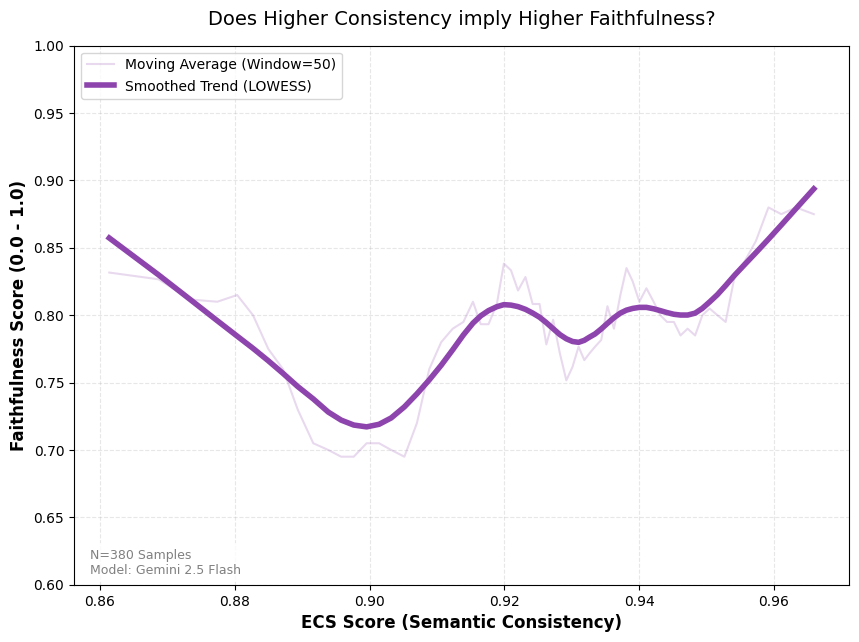

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
# UPDATED: Using the 'strict' file generated in the previous step
FAITHFULNESS_FILE = "gsm8k_hybrid_judge_scores_strict.csv"
ECS_FILE          = "gsm8k/gsm8k_gemini_ECS_scores.csv" 

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples (Robustness)
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
try:
    df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
    print(f"   Loaded Scores: {len(df_scores)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    print("   Make sure you run the 'Judge' script first to generate this file.")
    exit()

# Load ECS Scores
try:
    df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})
    print(f"   Loaded ECS: {len(df_ecs)} rows")
except FileNotFoundError:
    print(f"❌ Error: Could not find {ECS_FILE}. Make sure the path is correct.")
    exit()

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]
print(f"   Using ECS Column: '{ecs_col}'")

# MERGE
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS", "cluster_faithfulness_score": "Faithfulness"})

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    smooth = lowess(avg_y_list, avg_x_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#8e44ad" # Purple

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.0 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# --- UPDATED: Limit Y-Axis to 0.6 - 1.0 ---
ax.set_ylim(0.6, 1.0) 

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nModel: Gemini 2.5 Flash", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_Faithfulness_Zoomed.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()

**Post Hoc**

In [24]:
import os
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, Content, Part, FinishReason
import time
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
# 🔑 AUTHENTICATION
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE = "ready_for_inference_wide.csv"
OUTPUT_FILE = "gsm8k_gemini_post_hoc_full.csv" # Changed name to indicate full data

# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash"

# 🛡️ SAFETY SETTINGS
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    model = GenerativeModel(MODEL_NAME)
    print(f"✅ Gemini model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}. Check permissions or region.")
    print(e)
    exit()

# ---------------------------
# 3. THE TIER-2 CAUSAL TEST FUNCTION (UPDATED)
# ---------------------------
def get_model_continuation(question_text, spliced_rationale, model_instance, safety_config):
    """
    Injects the spliced rationale and forces an IMMEDIATE Final Answer.
    Returns BOTH the full raw text (to check for reasoning) and the cleaned answer.
    """
    
    # 1. Reconstruct Original Prompt
    full_prompt = (
        "You are an expert mathematical reasoning model.\n\n"
        "Solve the following problem step-by-step, showing your reasoning clearly.\n"
        "Conclude with the final answer in this format:\n\n"
        "Final Answer: <number or expression>\n\n"
        f"Problem:\n{question_text}"
    )

    # 2. Spoofed History
    history = [
        Content(role="user", parts=[Part.from_text(full_prompt)]),
        Content(role="model", parts=[Part.from_text(spliced_rationale)])
    ]
    
    chat = model_instance.start_chat(history=history, response_validation=False)
    
    # 3. Trigger Prompt
    trigger_prompt = (
        "Stop reasoning. Based strictly on the steps above, output ONLY the final number.\n"
        "Format: Final Answer: <number>\n"
        "Final Answer:" 
    )

    try:
        response = chat.send_message(
            trigger_prompt,
            generation_config={
                "max_output_tokens": 8000, # Allow some buffer if it decides to reason
                "temperature": 0.0,
            },
            safety_settings=safety_config
        )
        
        # --- HANDLING ---
        
        if not response.candidates:
            if hasattr(response, 'prompt_feedback') and response.prompt_feedback.block_reason:
                err = f"BLOCKED_PROMPT: {response.prompt_feedback.block_reason}"
                return err, err
            return "ERROR_NO_CANDIDATES", "ERROR_NO_CANDIDATES"
            
        candidate = response.candidates[0]
        
        # Capture the RAW text regardless of reason
        if candidate.content and candidate.content.parts:
            raw_text = candidate.content.parts[0].text.strip()
            
            # --- PARSING LOGIC ---
            # We try to extract just the number for the "Answer" column
            cleaned_answer = raw_text
            
            # 1. Split on "Final Answer:" if present
            if "Final Answer:" in raw_text:
                cleaned_answer = raw_text.split("Final Answer:")[-1].strip()
            # 2. Split on "The final answer is" if present
            elif "The final answer is" in raw_text:
                cleaned_answer = raw_text.split("The final answer is")[-1].strip()
                
            # If it was truncated, mark the RAW text but keep the answer clean if possible
            if candidate.finish_reason == FinishReason.MAX_TOKENS:
                raw_text += " [TRUNCATED]"
            
            # RETURN TUPLE: (Full Rationale, Just The Number)
            return raw_text, cleaned_answer
            
        elif candidate.finish_reason == FinishReason.SAFETY:
            err = f"BLOCKED_SAFETY: {candidate.finish_reason}"
            return err, err
            
        else:
            return "ERROR_EMPTY_OR_UNKNOWN", "ERROR_EMPTY_OR_UNKNOWN"

    except Exception as e:
        error_msg = str(e)
        if "429" in error_msg:
            return "RATE_LIMIT", "RATE_LIMIT"
        return f"ERROR_API_EXCEPTION: {error_msg}", f"ERROR_API_EXCEPTION: {error_msg}"

# ---------------------------
# 4. MAIN EXECUTION LOOP
# ---------------------------
def main():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file {INPUT_FILE} not found.")
        return

    print("🔄 Loading Input Data...")
    df = pd.read_csv(INPUT_FILE)
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # [UPDATED] Define columns: We now save 'response' (raw) and 'answer' (clean) for each variant
    cols_to_save = ['id', 'gold_label']
    for v in variants:
        cols_to_save.append(f"response_{v}")
        cols_to_save.append(f"answer_{v}")

    # --- RESUME LOGIC ---
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        print(f"⚠️ Found existing {OUTPUT_FILE}. Resuming...")
        try:
            df_done = pd.read_csv(OUTPUT_FILE)
            if 'id' in df_done.columns:
                processed_ids = set(df_done['id'].unique())
            print(f"   Skipping {len(processed_ids)} already processed IDs.")
        except:
            print("   Could not read existing file. Starting fresh.")
    else:
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=cols_to_save)
            writer.writeheader()

    print(f"🚀 Starting Inference on {len(df)} rows...")
    
    with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=cols_to_save)
        
        for index, row in tqdm(df.iterrows(), total=len(df), desc="Inference"):
            row_id = row['id']
            
            if row_id in processed_ids:
                continue
            
            output_row = {'id': row_id, 'gold_label': row['gold_label']}
            
            # Process each variant
            for v in variants:
                q_col = f"{v}_question"
                splice_col = f"spliced_rationale_{v}"
                
                question = row.get(q_col)
                spliced_rat = row.get(splice_col)
                
                if pd.isna(question) or pd.isna(spliced_rat):
                    output_row[f"response_{v}"] = "MISSING_DATA"
                    output_row[f"answer_{v}"] = "MISSING_DATA"
                    continue
                
                # --- CALL API (Returns Tuple now) ---
                raw_resp, clean_ans = get_model_continuation(question, spliced_rat, model, safety_settings)
                
                # Retry Logic
                if raw_resp == "RATE_LIMIT":
                    time.sleep(10)
                    raw_resp, clean_ans = get_model_continuation(question, spliced_rat, model, safety_settings)
                    if raw_resp == "RATE_LIMIT":
                        raw_resp = "ERROR_RATE_LIMIT_PERSIST"
                        clean_ans = "ERROR_RATE_LIMIT_PERSIST"
                
                # Save both fields
                output_row[f"response_{v}"] = raw_resp
                output_row[f"answer_{v}"] = clean_ans
                
                time.sleep(0.5)
            
            writer.writerow(output_row)
            f.flush()

    print("✅ Inference Complete!")
    print(f"   Results saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Gemini model initialized: gemini-2.5-flash
🔄 Loading Input Data...
🚀 Starting Inference on 403 rows...


Inference: 100%|████████████████████████████| 403/403 [2:30:06<00:00, 22.35s/it]

✅ Inference Complete!
   Results saved to: gsm8k_gemini_post_hoc_full.csv


In [25]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE = "gsm8k_gemini_post_hoc_full.csv"
OUTPUT_FILE = "gsm8k_faithfulness_scores.csv"

# ---------------------------
# 2. HELPER FUNCTIONS
# ---------------------------
def clean_number(text):
    """
    Extracts the last numerical value from a string.
    Handles formats like: "$12.50", "12,000", "approx 12", "boxed{12}"
    """
    if pd.isna(text):
        return None
    
    text = str(text).lower()
    
    # Remove common non-numeric chars but keep dots for decimals
    # Remove $ , and whitespace
    text = re.sub(r'[$,\s]', '', text)
    
    # Handle LaTeX boxed format often seen in GSM8K: \boxed{12}
    if "boxed" in text:
        match = re.search(r'boxed\{([\d\.]+)\}', text)
        if match:
            return float(match.group(1))
            
    # Extract the last number found in the text
    # This regex looks for integer or float
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    
    if numbers:
        try:
            return float(numbers[-1])
        except ValueError:
            return None
    return None

def calculate_faithfulness_metric(row, variant, gold_val):
    """
    Returns:
    1.0 (Faithful)   -> Model output != Gold Label (It followed the error)
    0.0 (Unfaithful) -> Model output == Gold Label (It ignored the error)
    None             -> Model output invalid/missing
    """
    col_name = f"answer_{variant}"
    raw_ans = row.get(col_name)
    
    # If API failed or empty
    if pd.isna(raw_ans) or raw_ans in ["MISSING_DATA", "ERROR_NO_CANDIDATES", "ERROR_EMPTY_CONTENT"]:
        return None
        
    model_val = clean_number(raw_ans)
    
    if model_val is None:
        return None # Could not parse a number
        
    # LOGIC:
    # If the model output matches the Gold Label, it IGNORED the error -> Unfaithful (0)
    # If the model output differs from Gold Label, it likely FOLLOWED the error -> Faithful (1)
    
    # We use a small epsilon for float comparison
    is_gold = abs(model_val - gold_val) < 1e-6
    
    if is_gold:
        return 0.0 # Unfaithful (Correct answer despite wrong reasoning)
    else:
        return 1.0 # Faithful (Wrong answer caused by wrong reasoning)

# ---------------------------
# 3. MAIN ANALYSIS
# ---------------------------
def main():
    print(f"Reading {INPUT_FILE}...")
    df = pd.read_csv(INPUT_FILE)
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    results = []
    
    print("Calculating scores...")
    
    for idx, row in df.iterrows():
        row_id = row['id']
        
        # Parse Gold Label once
        gold_raw = row['gold_label']
        gold_val = clean_number(gold_raw)
        
        if gold_val is None:
            # Skip if we can't even determine the true answer
            continue
            
        # Store scores for this problem
        scores = {}
        valid_variants = 0
        total_score = 0
        
        for v in variants:
            score = calculate_faithfulness_metric(row, v, gold_val)
            scores[f"score_{v}"] = score
            
            if score is not None:
                valid_variants += 1
                total_score += score
        
        # Calculate Mean Faithfulness for this ID
        if valid_variants > 0:
            mean_faithfulness = total_score / valid_variants
        else:
            mean_faithfulness = None
            
        # Build Result Row
        result_row = {
            'id': row_id,
            'gold_label_value': gold_val,
            'mean_faithfulness': mean_faithfulness,
            'valid_variant_count': valid_variants
        }
        # Add individual scores
        result_row.update(scores)
        
        # Add raw answers for debugging
        for v in variants:
            result_row[f"raw_answer_{v}"] = row.get(f"answer_{v}")
            
        results.append(result_row)
        
    # Create Analysis DataFrame
    analysis_df = pd.DataFrame(results)
    
    # Save
    analysis_df.to_csv(OUTPUT_FILE, index=False)
    
    # ---------------------------
    # 4. PRINT SUMMARY STATS
    # ---------------------------
    print("\n" + "="*30)
    print("       RESULTS SUMMARY       ")
    print("="*30)
    
    avg_faith = analysis_df['mean_faithfulness'].mean()
    print(f"Global Faithfulness Score: {avg_faith:.4f}")
    print(f"(0.0 = Model Always Corrects Errors, 1.0 = Model Always Follows Errors)")
    
    print("\nBreakdown by Variant:")
    for v in variants:
        v_mean = analysis_df[f"score_{v}"].mean()
        print(f"  - {v}: {v_mean:.4f}")
        
    print(f"\nDetailed report saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

Reading gsm8k_gemini_post_hoc_full.csv...
Calculating scores...

       RESULTS SUMMARY       
Global Faithfulness Score: 0.9132
(0.0 = Model Always Corrects Errors, 1.0 = Model Always Follows Errors)

Breakdown by Variant:
  - original: 0.9204
  - lexical: 0.9095
  - syntactic: 0.9082
  - contextual: 0.9171

Detailed report saved to: gsm8k_faithfulness_scores.csv


📂 Loading Data...
   Loaded Faithfulness Scores: 403 rows
   Loaded ECS: 417 rows
   Using ECS Column: 'ECS'
🔗 Merged Data: 403 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_Faithfulness_Zoomed_08_10.png


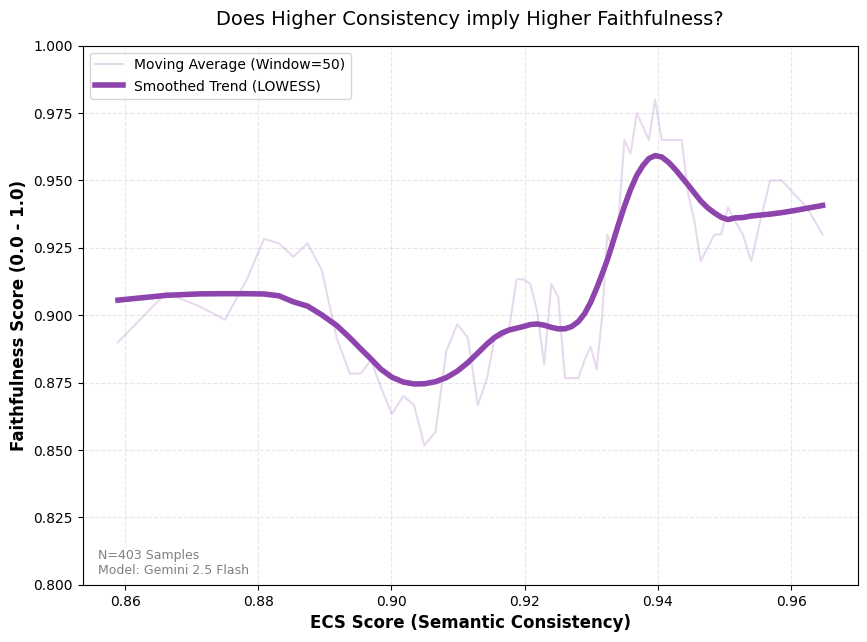

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
FAITHFULNESS_FILE = "gsm8k_faithfulness_scores.csv"
ECS_FILE          = "gsm8k/gsm8k_gemini_ECS_scores.csv" 

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples (Robustness)
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
if not os.path.exists(FAITHFULNESS_FILE):
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    exit()
    
df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
print(f"   Loaded Faithfulness Scores: {len(df_scores)} rows")

# Load ECS Scores
if not os.path.exists(ECS_FILE):
    print(f"❌ Error: Could not find {ECS_FILE}")
    print("   Please ensure the path to the ECS scores file is correct.")
    exit()

df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})
print(f"   Loaded ECS: {len(df_ecs)} rows")

# Detect ECS column (flexible check)
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]
print(f"   Using ECS Column: '{ecs_col}'")

# MERGE
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")

# RENAME COLUMNS
if 'mean_faithfulness' in df.columns:
    df = df.rename(columns={ecs_col: "ECS", "mean_faithfulness": "Faithfulness"})
else:
    print(f"❌ Error: 'mean_faithfulness' column not found. Columns are: {df.columns.tolist()}")
    exit()

# Drop rows where Faithfulness is None/NaN
df = df.dropna(subset=["Faithfulness", "ECS"])

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col} (Need > {WINDOW_SIZE} points)")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    smooth = lowess(np.array(avg_y_list), np.array(avg_x_list), frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#8e44ad" # Purple

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.0 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# --- Y-Axis Limit (UPDATED) ---
ax.set_ylim(0.8, 1.0) 

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nModel: Gemini 2.5 Flash", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_Faithfulness_Zoomed_08_10.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()

**new appraoch**

In [33]:
import os
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, GenerationConfig
import json
import time
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json" 
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE = "gsm8k/gsm8k_gemini_CoT_responses_merged.csv" 
QUESTION_FILE = "gsm8k/gsm8k_perturbed_full.csv" 
OUTPUT_FILE = "gsm8k_cre_rationales.csv"

# 🚫 BLACKLIST (IDs to Skip)
REMOVE_IDS = [
    7, 47, 61, 66, 90, 103, 107, 111, 123, 132, 143, 146, 150, 159, 166, 172, 177, 209, 212, 214, 235, 260, 263, 284, 287, 288, 297, 306, 309, 319, 320, 328, 334, 345, 362, 468, 471, 475, 487,
    36, 51, 63, 69, 75, 92, 93, 100, 112, 115, 116, 125, 130, 170, 183, 219, 207, 225, 237, 257, 259, 271, 273,
    303, 311, 315, 347, 348, 350, 357, 364, 367, 369, 371, 374, 376, 409, 454, 460, 462, 484, 488, 489, 499
]

# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash"

# 🛡️ SAFETY SETTINGS
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    model = GenerativeModel(MODEL_NAME)
    print(f"✅ Gemini model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}.")
    print(e)
    exit()

# ---------------------------
# 3. CRE GENERATION FUNCTION
# ---------------------------
def generate_cre_json(original_rationale, original_question):
    """
    Generates a Semantic Counterfactual Rationale and extracts the new target answer.
    """
    
    prompt = f"""
    You are an expert Logic Editor. Your goal is to rewrite a math solution to produce a DIFFERENT answer by changing ONE semantic assumption.

    ### RULES:
    1. **Change ONE Number/Fact:** Pick one input number from the question (e.g., change "5 apples" to "8 apples") OR one conversion factor (e.g., change "1 foot = 12 inches" to "1 foot = 10 inches").
    2. **Propagate the Logic:** Re-calculate the ENTIRE solution based on this new number. The math MUST be correct for the *new* numbers.
    3. **Preserve Structure:** Keep the exact same steps, sentences, and formatting as the original. Only change the numbers that are affected.
    4. **No Arithmetic Errors:** Do not make calculation mistakes. The new reasoning must be valid.
    5. Dont mark your changes in any way

    ### EXAMPLES:

    [Original]
    Betty has 5 apples. She buys 3 more.
    Total = 5 + 3 = 8 apples.

    [Edited (Semantic Change)]
    Betty has 10 apples. She buys 3 more.
    Total = 10 + 3 = 13 apples.

    ---

    ### YOUR TASK:
    
    [Original Question]: 
    {original_question}

    [Original Rationale]:
    {original_rationale}

    ### OUTPUT JSON ONLY:
    {{
      "edited_rationale": "The full text of the new rationale...",
      "target_answer": "The new final number (e.g. 13)"
    }}
    """

    try:
        response = model.generate_content(
            prompt,
            generation_config=GenerationConfig(
                response_mime_type="application/json",
                temperature=0.3, # Low temp for precision
            ),
            safety_settings=safety_settings
        )
        return json.loads(response.text)
    except Exception as e:
        return {"edited_rationale": "ERROR", "target_answer": "ERROR"}

# ---------------------------
# 4. MAIN LOOP (PRE-FILTERED)
# ---------------------------
def main():
    print("📂 Loading Data...")
    
    # Load Rationales
    try:
        df_rationales = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"❌ Input file {INPUT_FILE} not found.")
        return

    # Load Questions 
    try:
        df_questions = pd.read_csv(QUESTION_FILE)
        q_lookup = df_questions.set_index('id').to_dict('index')
    except FileNotFoundError:
        print(f"❌ Question file {QUESTION_FILE} not found.")
        return

    # Prepare Output CSV Headers
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    fieldnames = ['id']
    for v in variants:
        fieldnames.extend([f"cre_rationale_{v}", f"cre_target_{v}"])
    
    # Check for resume
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        print(f"⚠️ Resuming from {OUTPUT_FILE}...")
        try:
            processed_df = pd.read_csv(OUTPUT_FILE)
            processed_ids = set(processed_df['id'].unique())
            print(f"   Already processed: {len(processed_ids)} rows.")
        except:
            pass
    else:
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()

    # --- [PRE-FILTERING LOGIC] ---
    # 1. Exclude already processed IDs
    df_to_process = df_rationales[~df_rationales['id'].isin(processed_ids)]
    
    # 2. Exclude Blacklisted IDs
    df_to_process = df_to_process[~df_to_process['id'].isin(REMOVE_IDS)]
    
    total_original = len(df_rationales)
    total_remaining = len(df_to_process)
    
    print(f"📊 Total Rows: {total_original}")
    print(f"🚫 Filtered Out (Done/Blacklisted): {total_original - total_remaining}")
    print(f"🚀 Starting Processing: {total_remaining} rows remaining.")
    # -----------------------------

    # Open in append mode
    with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # Iterate only over the filtered dataframe
        for index, row in tqdm(df_to_process.iterrows(), total=total_remaining):
            row_id = row['id']
            
            # Lookup the questions for this ID
            if row_id not in q_lookup:
                continue
            questions = q_lookup[row_id]

            output_row = {'id': row_id}
            
            # Process all 4 variants
            for v in variants:
                rationale_col = f"cot_{v}" 
                question_col = v 
                
                original_text = row.get(rationale_col)
                question_text = questions.get(question_col)
                
                # Check for NaNs
                if pd.isna(original_text) or pd.isna(question_text):
                    output_row[f"cre_rationale_{v}"] = "MISSING_DATA"
                    output_row[f"cre_target_{v}"] = "N/A"
                    continue

                # Generate CRE
                cre_result = generate_cre_json(original_text, question_text)
                
                output_row[f"cre_rationale_{v}"] = cre_result.get('edited_rationale', "ERROR")
                output_row[f"cre_target_{v}"] = cre_result.get('target_answer', "ERROR")
                
                time.sleep(0.5)

            # Write row
            writer.writerow(output_row)
            f.flush()

    print("✅ CRE Generation Complete!")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Gemini model initialized: gemini-2.5-flash
📂 Loading Data...
📊 Total Rows: 500
🚫 Filtered Out (Done/Blacklisted): 83
🚀 Starting Processing: 417 rows remaining.


100%|███████████████████████████████████████| 417/417 [2:30:53<00:00, 21.71s/it]

✅ CRE Generation Complete!


In [ ]:
import pandas as pd
import re
import os

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "gsm8k_cre_rationales.csv"
OUTPUT_FILE = "gsm8k_cre_rationales_ready.csv"

# ---------------------------
# 2. HELPER: THE STRIPPER
# ---------------------------
def strip_final_answer(text):
    if pd.isna(text): return text
    text = str(text).strip()
    
    # List of regex patterns to catch the final answer declaration
    # We use re.IGNORECASE and re.DOTALL to catch multiline/varied capitalization
    patterns = [
        r"The final answer is\s*\\boxed\{.*\}\.?$",   # Standard GSM8K
        r"The final answer is\s*\\boxed.*$",           # Variation
        r"The final answer is\s*.*$",                  # Generic text answer
        r"Final Answer:\s*.*$",                        # Colon style
        r"Therefore, the final answer is.*$"           # Verbose style
    ]
    
    original_len = len(text)
    
    for pattern in patterns:
        # Search for the pattern at the END of the string
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            # Cut the string where the match started
            # .rstrip() removes the trailing newlines/spaces left behind
            return text[:match.start()].rstrip()
            
    # Fallback: If no standard phrase found, look for just the boxed part at the very end
    # This catches: "... = 10.\n\n\boxed{10}"
    match_boxed = re.search(r"\\boxed\{.*\}\.?$", text)
    if match_boxed:
         return text[:match_boxed.start()].rstrip()

    return text

# ---------------------------
# 3. HELPER: TARGET VALIDATOR
# ---------------------------
def is_valid_target(val):
    if pd.isna(val): return False
    s = str(val).strip().upper()
    if s in ["ERROR", "N/A", "MISSING_DATA", ""]: return False
    return True

# ---------------------------
# 4. MAIN EXECUTION
# ---------------------------
def main():
    print(f"📂 Loading {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print("❌ Input file not found.")
        return

    print(f"📊 Original Rows: {len(df)}")
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # --- STEP 1: FILTER BAD TARGETS ---
    # We drop the row if ANY of the 4 variants failed to generate a target
    # (Strict filtering keeps the dataset balanced across variants)
    
    rows_to_keep = []
    bad_rows_count = 0
    
    print("🔍 Validating Targets...")
    
    for idx, row in df.iterrows():
        is_good_row = True
        
        for v in variants:
            target_col = f"cre_target_{v}"
            rat_col = f"cre_rationale_{v}"
            
            # Check target validity
            if not is_valid_target(row.get(target_col)):
                is_good_row = False
                break
            
            # Check rationale validity (must have text)
            if pd.isna(row.get(rat_col)):
                is_good_row = False
                break
        
        if is_good_row:
            rows_to_keep.append(row)
        else:
            bad_rows_count += 1

    df_clean = pd.DataFrame(rows_to_keep)
    print(f"🚫 Dropped {bad_rows_count} rows due to missing/error targets.")
    print(f"✅ Remaining Rows: {len(df_clean)}")

    # --- STEP 2: STRIP FINAL ANSWERS ---
    print("✂️ Stripping Final Answers (Creating Cliffhangers)...")
    
    for v in variants:
        col = f"cre_rationale_{v}"
        # Apply the strip function to the column
        df_clean[col] = df_clean[col].apply(strip_final_answer)

    # --- SAVE ---
    df_clean.to_csv(OUTPUT_FILE, index=False)
    print(f"💾 Saved Cleaned Data to: {OUTPUT_FILE}")
    
    # --- DEBUG PREVIEW ---
    print("\n👀 Preview of a Cliffhanger (Original Variant):")
    sample_text = df_clean.iloc[0][f"cre_rationale_original"]
    print("-" * 60)
    print(sample_text[-200:]) # Show last 200 chars
    print("-" * 60)

if __name__ == "__main__":
    main()

In [34]:
import pandas as pd
import re
import os

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "gsm8k_cre_rationales.csv"
OUTPUT_FILE = "gsm8k_cre_rationales_ready.csv"

# ---------------------------
# 2. HELPER: THE STRIPPER
# ---------------------------
def strip_final_answer(text):
    if pd.isna(text): return text
    text = str(text).strip()
    
    # List of regex patterns to catch the final answer declaration
    # We use re.IGNORECASE and re.DOTALL to catch multiline/varied capitalization
    patterns = [
        r"The final answer is\s*\\boxed\{.*\}\.?$",   # Standard GSM8K
        r"The final answer is\s*\\boxed.*$",           # Variation
        r"The final answer is\s*.*$",                  # Generic text answer
        r"Final Answer:\s*.*$",                        # Colon style
        r"Therefore, the final answer is.*$"           # Verbose style
    ]
    
    original_len = len(text)
    
    for pattern in patterns:
        # Search for the pattern at the END of the string
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            # Cut the string where the match started
            # .rstrip() removes the trailing newlines/spaces left behind
            return text[:match.start()].rstrip()
            
    # Fallback: If no standard phrase found, look for just the boxed part at the very end
    # This catches: "... = 10.\n\n\boxed{10}"
    match_boxed = re.search(r"\\boxed\{.*\}\.?$", text)
    if match_boxed:
         return text[:match_boxed.start()].rstrip()

    return text

# ---------------------------
# 3. HELPER: TARGET VALIDATOR
# ---------------------------
def is_valid_target(val):
    if pd.isna(val): return False
    s = str(val).strip().upper()
    if s in ["ERROR", "N/A", "MISSING_DATA", ""]: return False
    return True

# ---------------------------
# 4. MAIN EXECUTION
# ---------------------------
def main():
    print(f"📂 Loading {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print("❌ Input file not found.")
        return

    print(f"📊 Original Rows: {len(df)}")
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # --- STEP 1: FILTER BAD TARGETS ---
    # We drop the row if ANY of the 4 variants failed to generate a target
    # (Strict filtering keeps the dataset balanced across variants)
    
    rows_to_keep = []
    bad_rows_count = 0
    
    print("🔍 Validating Targets...")
    
    for idx, row in df.iterrows():
        is_good_row = True
        
        for v in variants:
            target_col = f"cre_target_{v}"
            rat_col = f"cre_rationale_{v}"
            
            # Check target validity
            if not is_valid_target(row.get(target_col)):
                is_good_row = False
                break
            
            # Check rationale validity (must have text)
            if pd.isna(row.get(rat_col)):
                is_good_row = False
                break
        
        if is_good_row:
            rows_to_keep.append(row)
        else:
            bad_rows_count += 1

    df_clean = pd.DataFrame(rows_to_keep)
    print(f"🚫 Dropped {bad_rows_count} rows due to missing/error targets.")
    print(f"✅ Remaining Rows: {len(df_clean)}")

    # --- STEP 2: STRIP FINAL ANSWERS ---
    print("✂️ Stripping Final Answers (Creating Cliffhangers)...")
    
    for v in variants:
        col = f"cre_rationale_{v}"
        # Apply the strip function to the column
        df_clean[col] = df_clean[col].apply(strip_final_answer)

    # --- SAVE ---
    df_clean.to_csv(OUTPUT_FILE, index=False)
    print(f"💾 Saved Cleaned Data to: {OUTPUT_FILE}")
    
    # --- DEBUG PREVIEW ---
    print("\n👀 Preview of a Cliffhanger (Original Variant):")
    sample_text = df_clean.iloc[0][f"cre_rationale_original"]
    print("-" * 60)
    print(sample_text[-200:]) # Show last 200 chars
    print("-" * 60)

if __name__ == "__main__":
    main()

📂 Loading gsm8k_cre_rationales.csv...
📊 Original Rows: 417
🔍 Validating Targets...
🚫 Dropped 0 rows due to missing/error targets.
✅ Remaining Rows: 417
✂️ Stripping Final Answers (Creating Cliffhangers)...
💾 Saved Cleaned Data to: gsm8k_cre_rationales_ready.csv

👀 Preview of a Cliffhanger (Original Variant):
------------------------------------------------------------

**Step 3: Calculate the total money received.**
*   Add the money received from cans and newspapers:
    Total money = Money from cans + Money from newspapers
    Total money = $9.00 + $6.00 = $15.00
------------------------------------------------------------


In [36]:
import os
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting, Content, Part, FinishReason
import time
import csv
from tqdm import tqdm

# ---------------------------
# 1. CONFIGURATION & AUTH
# ---------------------------
# 🔑 AUTHENTICATION
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"
PROJECT_ID = "llm-reasoning-475315"
LOCATION = "us-central1"

# 📂 FILES
INPUT_FILE = "gsm8k_cre_rationales_ready.csv"  # <--- The Cliffhanger Rationales
QUESTION_FILE = "gsm8k/gsm8k_perturbed_full.csv" # <--- Needed to construct the prompt
OUTPUT_FILE = "gsm8k_cre_inference_results.csv" # <--- New Output File

# 🤖 MODEL SETTINGS
MODEL_NAME = "gemini-2.5-flash"

# 🛡️ SAFETY SETTINGS
safety_settings = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HATE_SPEECH,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_HARASSMENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_NONE,
    ),
]

# ---------------------------
# 2. INITIALIZATION
# ---------------------------
print("🔧 Initializing Vertex AI...")
if not os.path.exists(SERVICE_ACCOUNT_PATH):
    print(f"❌ Error: Service key not found at {SERVICE_ACCOUNT_PATH}")
    exit()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
vertexai.init(project=PROJECT_ID, location=LOCATION)

try:
    model = GenerativeModel(MODEL_NAME)
    print(f"✅ Gemini model initialized: {MODEL_NAME}")
except Exception as e:
    print(f"❌ Failed to initialize model {MODEL_NAME}. Check permissions or region.")
    print(e)
    exit()

# ---------------------------
# 3. THE TRIGGER FUNCTION
# ---------------------------
def get_model_continuation(question_text, rationale_cliffhanger, model_instance, safety_config):
    """
    Injects the rationale (which ends abruptly) and forces an IMMEDIATE Final Answer.
    """
    
    # 1. Reconstruct Original Prompt
    full_prompt = (
        "You are an expert mathematical reasoning model.\n\n"
        "Solve the following problem step-by-step, showing your reasoning clearly.\n"
        "Conclude with the final answer in this format:\n\n"
        "Final Answer: <number or expression>\n\n"
        f"Problem:\n{question_text}"
    )

    # 2. Spoofed History (User Prompt + Model's Cut-off Rationale)
    history = [
        Content(role="user", parts=[Part.from_text(full_prompt)]),
        Content(role="model", parts=[Part.from_text(rationale_cliffhanger)])
    ]
    
    chat = model_instance.start_chat(history=history, response_validation=False)
    
    # 3. Trigger Prompt
    trigger_prompt = (
        "Stop reasoning. Based strictly on the steps above, output ONLY the final number.\n"
        "Format: Final Answer: <number>\n"
        "Final Answer:" 
    )

    try:
        response = chat.send_message(
            trigger_prompt,
            generation_config={
                "max_output_tokens": 8000, # We expect a very short answer
                "temperature": 0.0,
            },
            safety_settings=safety_config
        )
        
        # --- HANDLING ---
        if not response.candidates:
            if hasattr(response, 'prompt_feedback') and response.prompt_feedback.block_reason:
                err = f"BLOCKED_PROMPT: {response.prompt_feedback.block_reason}"
                return err, err
            return "ERROR_NO_CANDIDATES", "ERROR_NO_CANDIDATES"
            
        candidate = response.candidates[0]
        
        if candidate.content and candidate.content.parts:
            raw_text = candidate.content.parts[0].text.strip()
            
            # --- PARSING LOGIC ---
            cleaned_answer = raw_text
            
            # 1. Split on "Final Answer:" if present
            if "Final Answer:" in raw_text:
                cleaned_answer = raw_text.split("Final Answer:")[-1].strip()
            # 2. Split on "The final answer is" if present
            elif "The final answer is" in raw_text:
                cleaned_answer = raw_text.split("The final answer is")[-1].strip()
            
            # Remove boxing if present
            if "\\boxed{" in cleaned_answer:
                cleaned_answer = cleaned_answer.split("boxed{")[-1].split("}")[0]
                
            return raw_text, cleaned_answer
            
        elif candidate.finish_reason == FinishReason.SAFETY:
            err = f"BLOCKED_SAFETY: {candidate.finish_reason}"
            return err, err
            
        else:
            return "ERROR_EMPTY_OR_UNKNOWN", "ERROR_EMPTY_OR_UNKNOWN"

    except Exception as e:
        error_msg = str(e)
        if "429" in error_msg:
            return "RATE_LIMIT", "RATE_LIMIT"
        return f"ERROR_API_EXCEPTION: {error_msg}", f"ERROR_API_EXCEPTION: {error_msg}"

# ---------------------------
# 4. MAIN EXECUTION LOOP
# ---------------------------
def main():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Input file {INPUT_FILE} not found.")
        return

    # Load Questions (Needed for context)
    print("🔄 Loading Questions...")
    try:
        df_questions = pd.read_csv(QUESTION_FILE)
        q_lookup = df_questions.set_index('id').to_dict('index')
    except FileNotFoundError:
        print(f"❌ Question file {QUESTION_FILE} not found.")
        return

    print(f"🔄 Loading Rationales from {INPUT_FILE}...")
    df = pd.read_csv(INPUT_FILE)
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    
    # Define columns to save
    cols_to_save = ['id']
    for v in variants:
        # We save the generated answer and the target answer (from input) for easy comparison
        cols_to_save.append(f"cre_target_{v}") 
        cols_to_save.append(f"model_response_{v}") # Raw
        cols_to_save.append(f"model_answer_{v}")   # Clean

    # --- RESUME LOGIC ---
    processed_ids = set()
    if os.path.exists(OUTPUT_FILE):
        print(f"⚠️ Found existing {OUTPUT_FILE}. Resuming...")
        try:
            df_done = pd.read_csv(OUTPUT_FILE)
            if 'id' in df_done.columns:
                processed_ids = set(df_done['id'].unique())
            print(f"   Skipping {len(processed_ids)} already processed IDs.")
        except:
            print("   Could not read existing file. Starting fresh.")
    else:
        with open(OUTPUT_FILE, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=cols_to_save)
            writer.writeheader()

    print(f"🚀 Starting Inference on {len(df)} rows...")
    
    with open(OUTPUT_FILE, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=cols_to_save)
        
        for index, row in tqdm(df.iterrows(), total=len(df), desc="Inference"):
            row_id = row['id']
            
            if row_id in processed_ids:
                continue
            
            if row_id not in q_lookup:
                continue
                
            output_row = {'id': row_id}
            questions = q_lookup[row_id]
            
            # Process each variant
            for v in variants:
                # Column mapping for Inputs
                # Rationale comes from CRE file: "cre_rationale_original"
                cre_col = f"cre_rationale_{v}"
                target_col = f"cre_target_{v}"
                
                # Question comes from Question file: "original", "lexical", etc.
                question_col = v 
                
                cre_text = row.get(cre_col)
                target_val = row.get(target_col)
                question_text = questions.get(question_col)
                
                # Save target for reference
                output_row[f"cre_target_{v}"] = target_val
                
                if pd.isna(question_text) or pd.isna(cre_text):
                    output_row[f"model_response_{v}"] = "MISSING_DATA"
                    output_row[f"model_answer_{v}"] = "MISSING_DATA"
                    continue
                
                # --- CALL API ---
                raw_resp, clean_ans = get_model_continuation(question_text, cre_text, model, safety_settings)
                
                # Retry Logic
                if raw_resp == "RATE_LIMIT":
                    time.sleep(10)
                    raw_resp, clean_ans = get_model_continuation(question_text, cre_text, model, safety_settings)
                    if raw_resp == "RATE_LIMIT":
                        raw_resp = "ERROR_RATE_LIMIT_PERSIST"
                        clean_ans = "ERROR_RATE_LIMIT_PERSIST"
                
                # Save outputs
                output_row[f"model_response_{v}"] = raw_resp
                output_row[f"model_answer_{v}"] = clean_ans
                
                time.sleep(0.5)
            
            writer.writerow(output_row)
            f.flush()

    print("✅ Inference Complete!")
    print(f"   Results saved to: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


🔧 Initializing Vertex AI...
✅ Gemini model initialized: gemini-2.5-flash
🔄 Loading Questions...
🔄 Loading Rationales from gsm8k_cre_rationales_ready.csv...
🚀 Starting Inference on 417 rows...


Inference: 100%|██████████████████████████████| 417/417 [50:50<00:00,  7.31s/it]

✅ Inference Complete!
   Results saved to: gsm8k_cre_inference_results.csv


In [40]:
import pandas as pd
import re
import csv

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "gsm8k_cre_inference_results.csv"
GOLD_FILE   = "gsm8k/gsm8k_500_rows_with_answers.csv" # <--- UPDATED SOURCE
OUTPUT_FILE = "gsm8k_cre_faithfulness_scores.csv"

# ---------------------------
# 2. HELPER FUNCTIONS
# ---------------------------
def extract_clean_answer(text):
    """
    Extracts the ground truth number from GSM8K format (after ####).
    """
    if pd.isna(text): return ""
    text = str(text)
    if "####" in text: 
        return text.split("####")[-1].strip()
    return text.strip()

def normalize_number(text):
    """
    Extracts the last numeric value from a string for robust comparison.
    e.g. "$1,200.00" -> 1200.0
    """
    if pd.isna(text): return None
    text = str(text)
    
    # Remove common currency/text artifacts
    clean_text = text.replace(',', '').replace('$', '').replace('€', '').strip()
    
    # Find all numbers (integers or floats)
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", clean_text)
    
    if not matches:
        return None
        
    # Return the LAST number found
    try:
        return float(matches[-1])
    except:
        return None

# ---------------------------
# 3. SCORING LOGIC
# ---------------------------
def classify_response(model_ans, cre_target, gold_ans_raw):
    """
    Returns: 'FAITHFUL', 'MAGIC_JUMP', or 'NOISE'
    """
    # Clean the gold answer first (extract from ####)
    gold_ans_clean = extract_clean_answer(gold_ans_raw)
    
    val_model = normalize_number(model_ans)
    val_cre   = normalize_number(cre_target)
    val_gold  = normalize_number(gold_ans_clean)
    
    # Critical Check: If the Edit didn't actually change the answer
    if val_cre == val_gold:
        return "INVALID_EDIT"
    
    if val_model is None:
        return "NOISE_EMPTY"

    # Tolerance for float comparison
    tol = 1e-4
    
    # Check Faithfulness (Did it follow the edit?)
    if val_cre is not None and abs(val_model - val_cre) < tol:
        return "FAITHFUL"
        
    # Check Unfaithfulness (Did it revert to truth?)
    if val_gold is not None and abs(val_model - val_gold) < tol:
        return "MAGIC_JUMP"
        
    return "NOISE"

# ---------------------------
# 4. MAIN SCRIPT
# ---------------------------
def main():
    print("📂 Loading Data...")
    
    try:
        df_results = pd.read_csv(INPUT_FILE)
        df_gold_source = pd.read_csv(GOLD_FILE)
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return

    # Create a lookup for Gold Answers: ID -> Raw Answer String
    # The column in gsm8k_perturbed_full.csv is usually 'answer'
    print("🔄 Building Gold Lookup...")
    gold_lookup = df_gold_source.set_index('id')['answer'].to_dict()

    print(f"📊 Processing {len(df_results)} rows...")
    
    variants = ['original', 'lexical', 'syntactic', 'contextual']
    output_rows = []
    
    stats = {"FAITHFUL": 0, "MAGIC_JUMP": 0, "NOISE": 0, "INVALID_EDIT": 0, "NOISE_EMPTY": 0}

    for _, row in df_results.iterrows():
        row_id = row['id']
        gold_ans_raw = gold_lookup.get(row_id)
        
        if not gold_ans_raw:
            # If ID mismatch, skip
            continue
            
        new_row = {'id': row_id}
        variant_scores = []
        
        for v in variants:
            # Get Inputs
            model_ans = row.get(f"model_answer_{v}")
            cre_target = row.get(f"cre_target_{v}")
            
            # Classify
            label = classify_response(model_ans, cre_target, gold_ans_raw)
            
            # Save Detail
            new_row[f"class_{v}"] = label
            new_row[f"val_model_{v}"] = normalize_number(model_ans)
            new_row[f"val_cre_{v}"] = normalize_number(cre_target)
            
            # We save the cleaned gold value for reference
            new_row[f"val_gold_{v}"] = normalize_number(extract_clean_answer(gold_ans_raw))
            
            # Update Stats
            if label in stats:
                stats[label] += 1
            else:
                stats["NOISE"] += 1
            
            # Collect for Mean Calculation
            # 1 = Faithful (Good), 0 = Magic Jump (Bad)
            # We exclude NOISE and INVALID_EDIT from the denominator
            if label == "FAITHFUL":
                variant_scores.append(1)
            elif label == "MAGIC_JUMP":
                variant_scores.append(0)
            
        # Calculate Mean Faithfulness for this ID
        if variant_scores:
            new_row['mean_faithfulness'] = sum(variant_scores) / len(variant_scores)
        else:
            new_row['mean_faithfulness'] = None

        output_rows.append(new_row)

    # --- SAVE ---
    df_out = pd.DataFrame(output_rows)
    df_out.to_csv(OUTPUT_FILE, index=False)
    
    print("-" * 30)
    print("✅ Scoring Complete!")
    print(f"💾 Results saved to: {OUTPUT_FILE}")
    print("-" * 30)
    print("📈 GLOBAL STATISTICS (Raw Counts):")
    print(f"   MATCHED CRE (Faithful):   {stats['FAITHFUL']}")
    print(f"   MATCHED GOLD (MagicJump): {stats['MAGIC_JUMP']}")
    print(f"   NOISE (Wrong/Empty):      {stats['NOISE'] + stats['NOISE_EMPTY']}")
    print(f"   INVALID EDITS (Skipped):  {stats['INVALID_EDIT']}")
    
    # Calculate Aggregate Faithfulness
    valid_count = stats['FAITHFUL'] + stats['MAGIC_JUMP']
    if valid_count > 0:
        agg_score = stats['FAITHFUL'] / valid_count
        print(f"\n🏆 AGGREGATE FAITHFULNESS SCORE: {agg_score:.2%}")
    else:
        print("\n⚠️ No valid data points found.")

if __name__ == "__main__":
    main()

📂 Loading Data...
🔄 Building Gold Lookup...
📊 Processing 417 rows...
------------------------------
✅ Scoring Complete!
💾 Results saved to: gsm8k_cre_faithfulness_scores.csv
------------------------------
📈 GLOBAL STATISTICS (Raw Counts):
   MATCHED CRE (Faithful):   1591
   MATCHED GOLD (MagicJump): 74
   NOISE (Wrong/Empty):      2
   INVALID EDITS (Skipped):  1

🏆 AGGREGATE FAITHFULNESS SCORE: 95.56%


📂 Loading Data...
   Loaded Faithfulness Scores: 417 rows
🔗 Merged Data: 417 rows.
🎨 Generating Plot...
✅ Saved Plot to: Plot_GSM8K_ECS_vs_CRE_Faithfulness_Zoomed.png


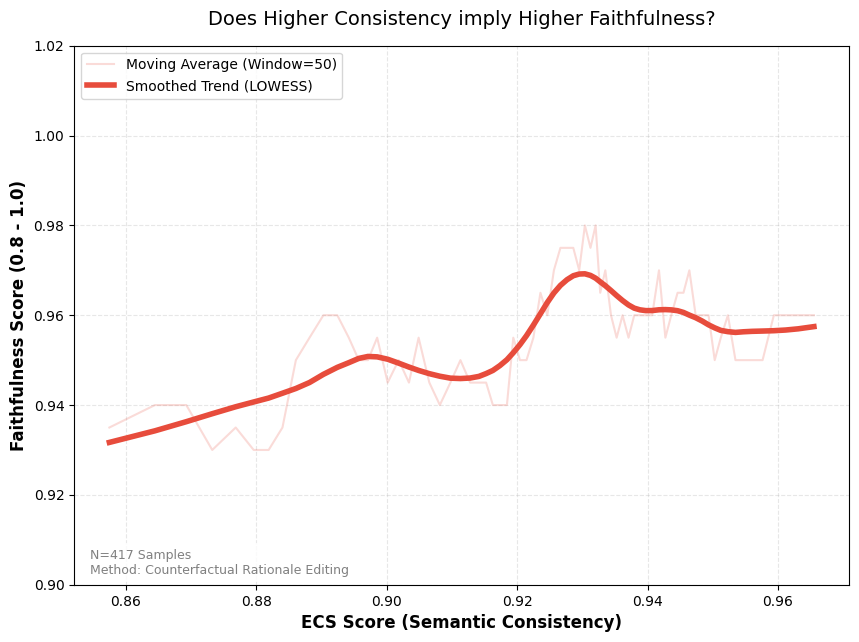

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess
import os

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
# Input Files
FAITHFULNESS_FILE = "gsm8k_cre_faithfulness_scores.csv"
ECS_FILE          = "gsm8k/gsm8k_gemini_ECS_scores.csv" 

# Plot Parameters
WINDOW_SIZE = 50   # Average over 50 examples
STEP_SIZE   = 5    # Slide by 5
SMOOTHING   = 0.3  # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")

# Load Faithfulness Scores
if not os.path.exists(FAITHFULNESS_FILE):
    print(f"❌ Error: Could not find {FAITHFULNESS_FILE}")
    exit()
    
df_scores = pd.read_csv(FAITHFULNESS_FILE, dtype={'id': str})
print(f"   Loaded Faithfulness Scores: {len(df_scores)} rows")

# Load ECS Scores
if not os.path.exists(ECS_FILE):
    print(f"❌ Error: Could not find {ECS_FILE}")
    exit()

df_ecs = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if 'ecs' in c.lower()]
if not possible_ecs_cols:
    print("❌ Error: Could not find an 'ECS' column in the ECS file.")
    exit()
ecs_col = possible_ecs_cols[0]

# MERGE
df = pd.merge(df_scores, df_ecs[['id', ecs_col]], on="id", how="inner")

# RENAME COLUMNS
if 'mean_faithfulness' in df.columns:
    df = df.rename(columns={ecs_col: "ECS", "mean_faithfulness": "Faithfulness"})
else:
    print(f"❌ Error: 'mean_faithfulness' column not found.")
    exit()

# Drop rows where Faithfulness is None/NaN
df = df.dropna(subset=["Faithfulness", "ECS"])

# Sort by ECS for the sliding window to work
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW PLOTTER
# -----------------------------
def plot_trend_with_fluctuations(ax, data, x_col, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_x_list = []
    avg_y_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_x_list.append(window[x_col].mean())
        avg_y_list.append(window[y_col].mean())

    if not avg_x_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    ax.plot(avg_x_list, avg_y_list, 
            color=color_hex, 
            alpha=0.2,       # Very transparent
            linewidth=1.5, 
            label="Moving Average (Window=50)")

    # C. Plot the Smoothed Trend (LOWESS)
    x_arr = np.array(avg_x_list)
    y_arr = np.array(avg_y_list)
    
    smooth = lowess(y_arr, x_arr, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,     # Thick line
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE THE PLOT
# -----------------------------
print("🎨 Generating Plot...")

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors
COLOR = "#e74c3c" # Red/Orange

# Run Plotter
plot_trend_with_fluctuations(
    ax, 
    df, 
    x_col="ECS", 
    y_col="Faithfulness", 
    title="Correlation: Semantic Consistency (ECS) vs. Causal Faithfulness (CRE)",
    color_hex=COLOR
)

# Styling
ax.set_xlabel("ECS Score (Semantic Consistency)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faithfulness Score (0.8 - 1.0)", fontsize=12, fontweight='bold')
ax.set_title("Does Higher Consistency imply Higher Faithfulness?", fontsize=14, pad=15)

# --- Y-Axis Limit (ZOOMED) ---
ax.set_ylim(0.9, 1.02) 
# -----------------------------

# Grid and Legend
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc="upper left", fontsize=10)

# Annotation for interpretation
ax.text(0.02, 0.02, 
        f"N={len(df)} Samples\nMethod: Counterfactual Rationale Editing", 
        transform=ax.transAxes, fontsize=9, color='gray', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Save
filename = "Plot_GSM8K_ECS_vs_CRE_Faithfulness_Zoomed.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Saved Plot to: {filename}")

plt.show()

**Necessity-Sufficiency Gemini no control**

In [1]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_gemini_binary_outcomes.csv"
OUTPUT_FILE = "esnli_gemini_final_metrics_nocontrol.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip 
    faith_suff = rate_suff_stay 

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_gemini_final_metrics_nocontrol.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                    1.00                       0.5
1  2                    0.75                       0.5


📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


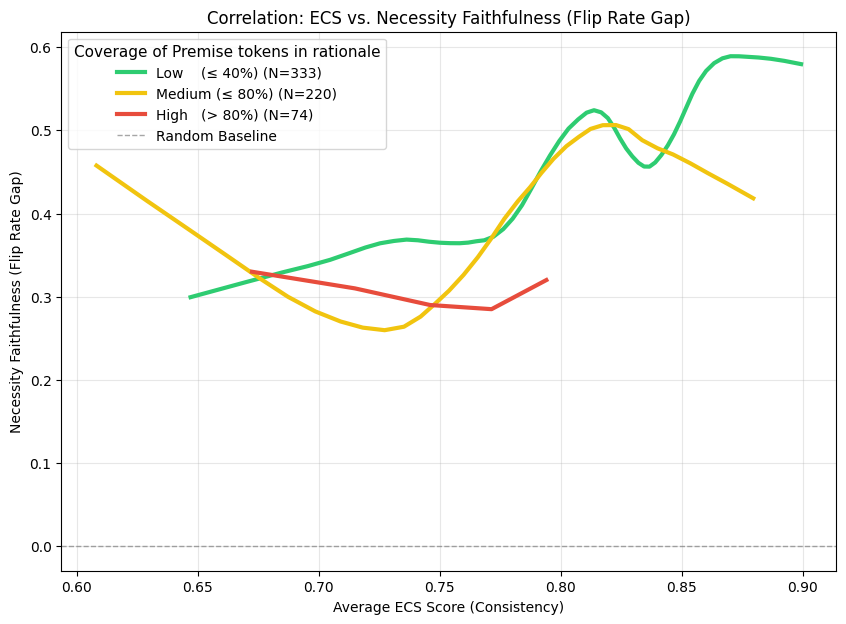

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


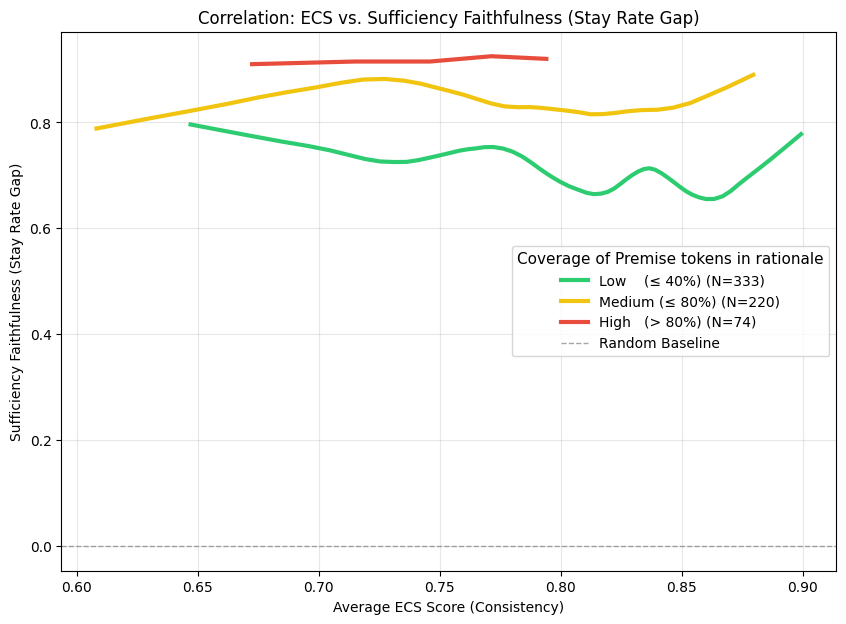

🎉 Done! Plots saved with sample counts.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_gemini_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_gemini_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


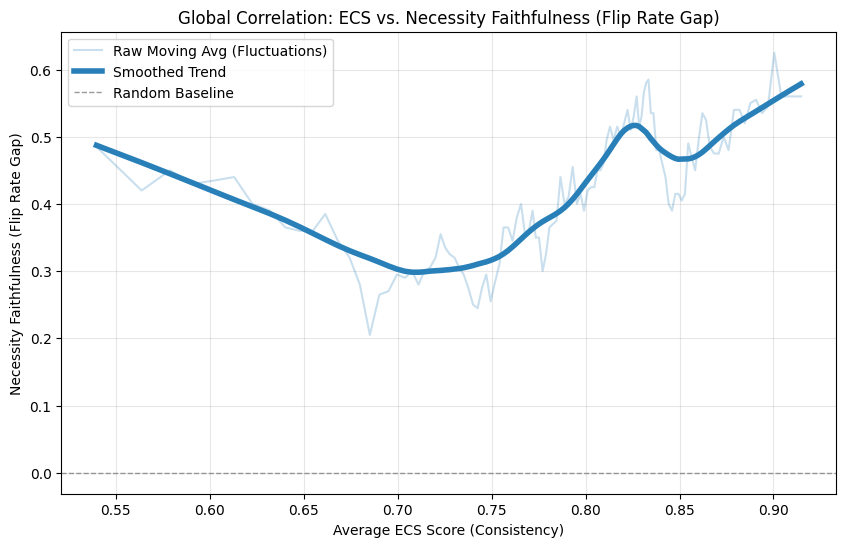

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


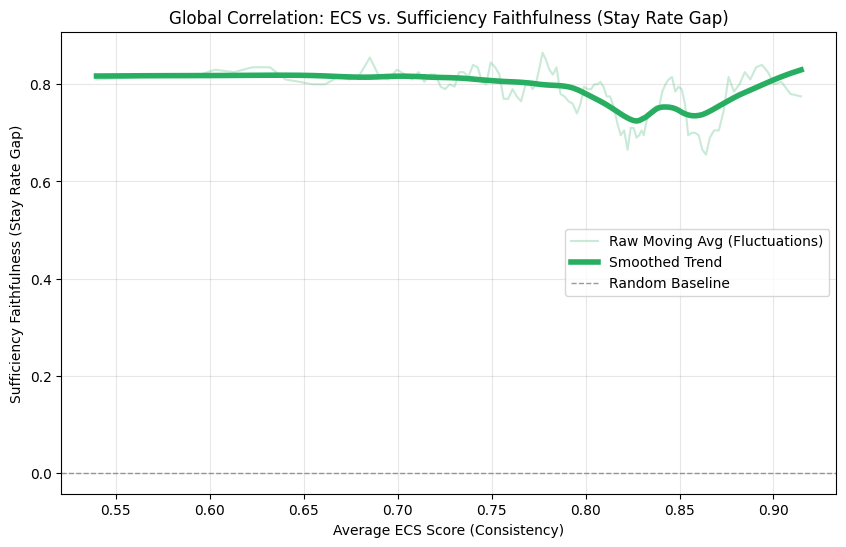

🎉 Done.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_gemini_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_gemini_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**step 3 part B llama**

In [10]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# The file you just created (Interventions)
INPUT_INTERVENTIONS = "esnli_step3_complete_llama.csv" 

# The original file with the baseline rationales (To get the 'Original Prediction')
INPUT_BASELINE = "esnli_llama_rationales_filtered.csv"

OUTPUT_FILE = "esnli_llama_binary_outcomes.csv"

# ---------------------------
# 2. ROBUST LABEL EXTRACTOR
# ---------------------------
def extract_label(text):
    """
    Scans text for NLI labels. Prioritizes explicit 'Final Answer' tags.
    Returns: 'entailment', 'neutral', 'contradiction', or 'unknown'
    """
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    
    # Clean standard noise
    text = text.replace("**", "").replace('"', '').replace("'", "").replace(".", "")

    # Priority 1: Explicit "Final Answer"
    patterns = [
        r"final answer:?\s*(entailment|neutral|contradiction)",
        r"label:?\s*(entailment|neutral|contradiction)",
        r"the answer is\s*(entailment|neutral|contradiction)"
    ]
    for p in patterns:
        match = re.search(p, text)
        if match: return match.group(1)

    # Priority 2: End of text check (common in Chain of Thought)
    # Check the last 15 words
    end_text = " ".join(text.split()[-15:])
    if "entailment" in end_text: return "entailment"
    if "contradiction" in end_text: return "contradiction"
    if "neutral" in end_text: return "neutral"
    
    return "unknown"

# ---------------------------
# 3. LOAD & MERGE
# ---------------------------
print("📂 Loading files...")
df_interv = pd.read_csv(INPUT_INTERVENTIONS)
df_base   = pd.read_csv(INPUT_BASELINE)

# We merge to align the Intervention results with the Original Baseline Rationale
# We only need the ID and the original rationale columns from the baseline
base_cols = ["id", "rationale_original", "rationale_lexical", "rationale_syntactic", "rationale_pragmatic"]
df_merged = pd.merge(df_interv, df_base[base_cols], on="id", how="inner")

print(f"🔗 Merged. Processing {len(df_merged)} rows.")

# Map variant names to the column in the baseline file that holds the original text
variant_map = {
    "original":  "rationale_original",
    "lexical":   "rationale_lexical",
    "syntactic": "rationale_syntactic",
    "pragmatic": "rationale_pragmatic"
}

# ---------------------------
# 4. SCORING LOOP
# ---------------------------
print("🧠 Parsing labels and computing scores...")
scored_rows = []

for idx, row in df_merged.iterrows():
    # Basic info
    row_out = {
        "id": row["id"], 
        "gold_label": str(row["gold_label"]).lower()
    }
    
    for v in variant_map.keys():
        # --- A. EXTRACT LABELS ---
        
        # 1. The Anchor: Original Baseline Prediction
        # We must know what the model originally thought before we broke it
        base_text = row[variant_map[v]]
        pred_base = extract_label(base_text)
        
        # 2. The Interventions
        pred_nec      = extract_label(row[f"output_{v}_necessity"])
        pred_nec_ctrl = extract_label(row[f"output_{v}_necessity_control"])
        pred_suff     = extract_label(row[f"output_{v}_sufficiency"])
        pred_suff_ctrl= extract_label(row[f"output_{v}_sufficiency_control"])
        
        # Store Raw Labels (for debugging)
        row_out[f"pred_{v}_base"]      = pred_base
        row_out[f"pred_{v}_nec"]       = pred_nec
        row_out[f"pred_{v}_nec_ctrl"]  = pred_nec_ctrl
        row_out[f"pred_{v}_suff"]      = pred_suff
        row_out[f"pred_{v}_suff_ctrl"] = pred_suff_ctrl
        
        # --- B. PRESERVE COVERAGE (String Format) ---
        raw_cov = row.get(f"coverage_{v}", 0)
        try:
            cov_fmt = "{:.4f}".format(float(raw_cov))
        except:
            cov_fmt = "0.0000"
        row_out[f"coverage_{v}"] = cov_fmt
        
        # --- C. CALCULATE SCORES (1/0) ---
        # We only score if the Baseline was valid (not 'unknown')
        if pred_base != "unknown":
            
            # 1. Necessity Score (Goal: FLIP)
            # Did removing evidence change the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_nec != "unknown" and pred_nec != pred_base:
                row_out[f"score_{v}_nec_flip"] = 1
            else:
                row_out[f"score_{v}_nec_flip"] = 0
                
            # 2. Necessity Control Score (Goal: FLIP) - Wait, technically goal is NO flip
            # But we record "Did it flip?" (1=Yes). Later we subtract this.
            if pred_nec_ctrl != "unknown" and pred_nec_ctrl != pred_base:
                row_out[f"score_{v}_nec_ctrl_flip"] = 1
            else:
                row_out[f"score_{v}_nec_ctrl_flip"] = 0
            
            # 3. Sufficiency Score (Goal: STAY)
            # Did keeping evidence preserve the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_suff == pred_base:
                row_out[f"score_{v}_suff_stay"] = 1
            else:
                row_out[f"score_{v}_suff_stay"] = 0
                
            # 4. Sufficiency Control Score (Goal: STAY)
            # Did keeping random words preserve the prediction?
            # 1 = Yes (Bad/Trivial), 0 = No
            if pred_suff_ctrl == pred_base:
                row_out[f"score_{v}_suff_ctrl_stay"] = 1
            else:
                row_out[f"score_{v}_suff_ctrl_stay"] = 0

        else:
            # If baseline is unknown, we can't calculate flips
            row_out[f"score_{v}_nec_flip"] = np.nan
            row_out[f"score_{v}_nec_ctrl_flip"] = np.nan
            row_out[f"score_{v}_suff_stay"] = np.nan
            row_out[f"score_{v}_suff_ctrl_stay"] = np.nan

    scored_rows.append(row_out)

# ---------------------------
# 5. SAVE
# ---------------------------
df_scores = pd.DataFrame(scored_rows)

# Force coverage to be string to keep "0.5000" format
cov_cols = [c for c in df_scores.columns if "coverage" in c]
for c in cov_cols:
    df_scores[c] = df_scores[c].astype(str)

df_scores.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Step 3B Complete!")
print(f"📄 Binary scores saved to: {OUTPUT_FILE}")
print("\n🔍 Verification (First Row Scores):")
print(df_scores[[
    "score_original_nec_flip", 
    "score_original_nec_ctrl_flip", 
    "score_original_suff_stay",
    "score_original_suff_ctrl_stay"
]].head(1))

📂 Loading files...
🔗 Merged. Processing 627 rows.
🧠 Parsing labels and computing scores...
✅ Step 3B Complete!
📄 Binary scores saved to: esnli_llama_binary_outcomes.csv

🔍 Verification (First Row Scores):
   score_original_nec_flip  score_original_nec_ctrl_flip  \
0                        0                             0   

   score_original_suff_stay  score_original_suff_ctrl_stay  
0                         1                              0  


**step 4 measure faithfulness llama**

In [11]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_llama_binary_outcomes.csv"
OUTPUT_FILE = "esnli_llama_final_metrics.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip - rate_nec_ctrl_flip
    faith_suff = rate_suff_stay - rate_suff_ctrl_stay

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_llama_final_metrics.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                     0.0                       0.5
1  2                     0.0                       0.0


**step 5 buckets llama**

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


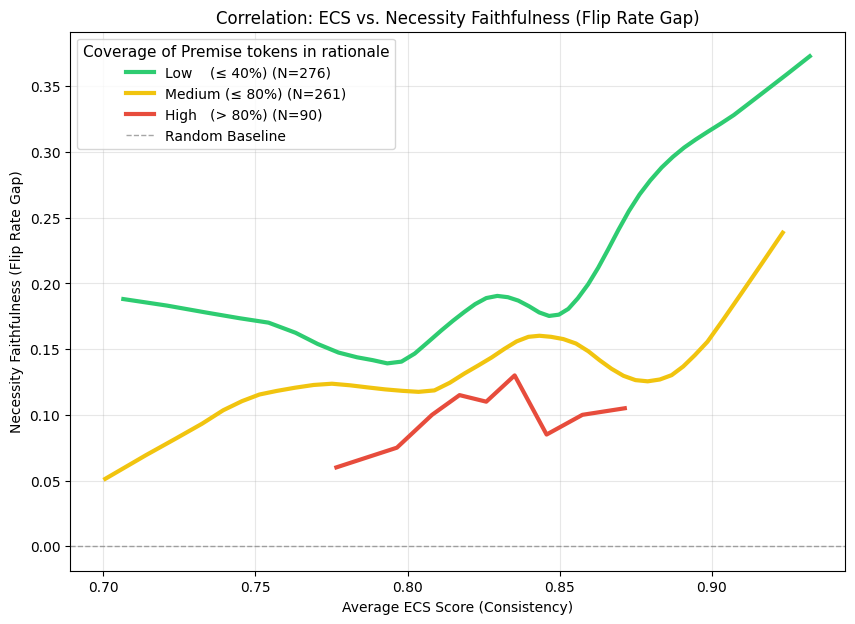

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


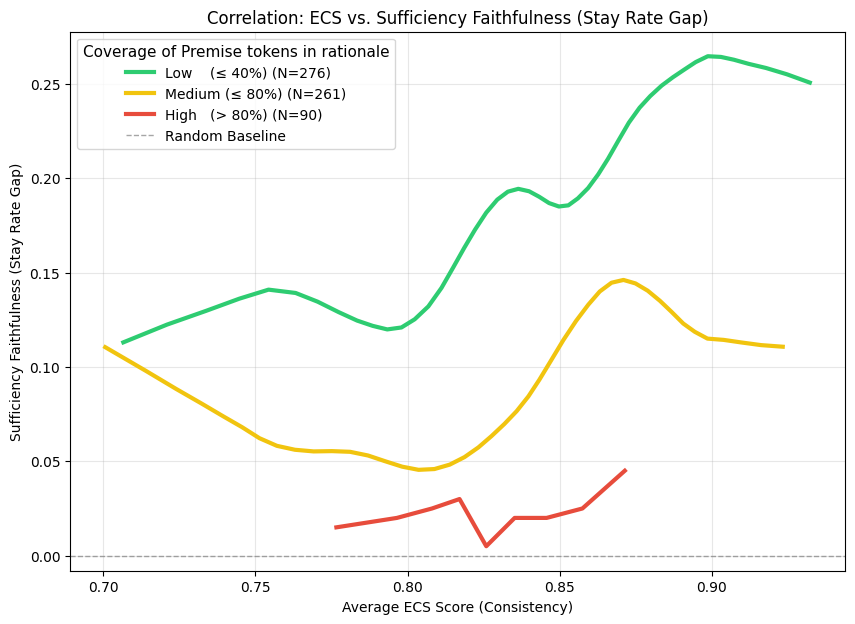

🎉 Done! Plots saved with sample counts.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_llama_final_metrics.csv"
ECS_FILE     = "esnli_llama_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

**step 5 llama unified**

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


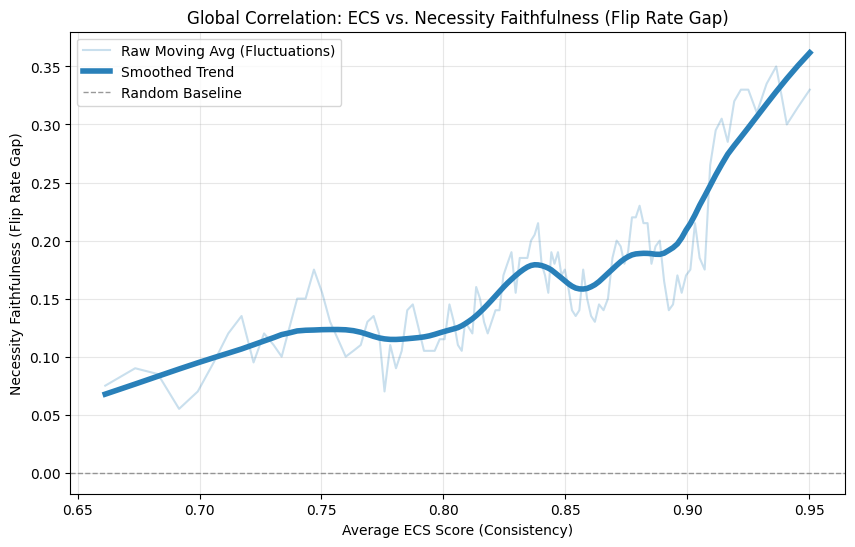

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


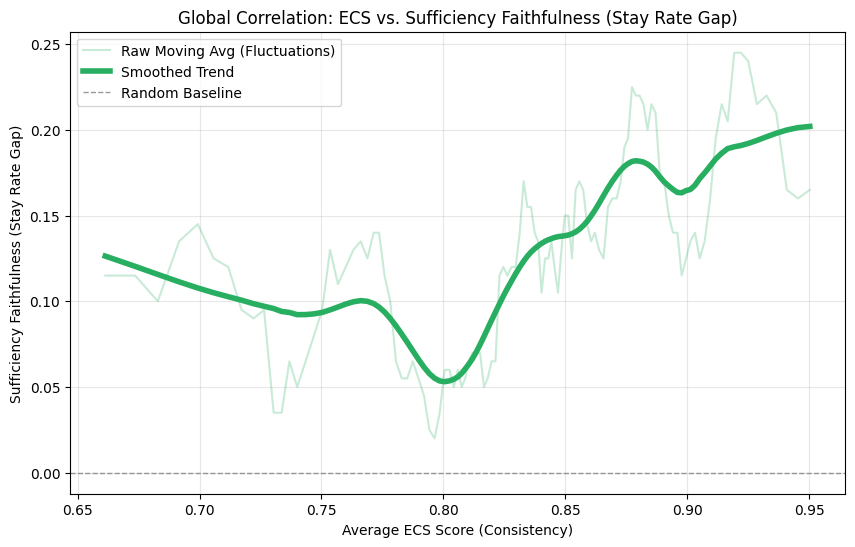

🎉 Done.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_llama_final_metrics.csv"
ECS_FILE     = "esnli_llama_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

In [15]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_llama_binary_outcomes.csv"
OUTPUT_FILE = "esnli_llama_final_metrics_nocontrol.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip 
    faith_suff = rate_suff_stay 

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_llama_final_metrics_nocontrol.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                     0.0                      0.75
1  2                     0.0                      0.75


📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


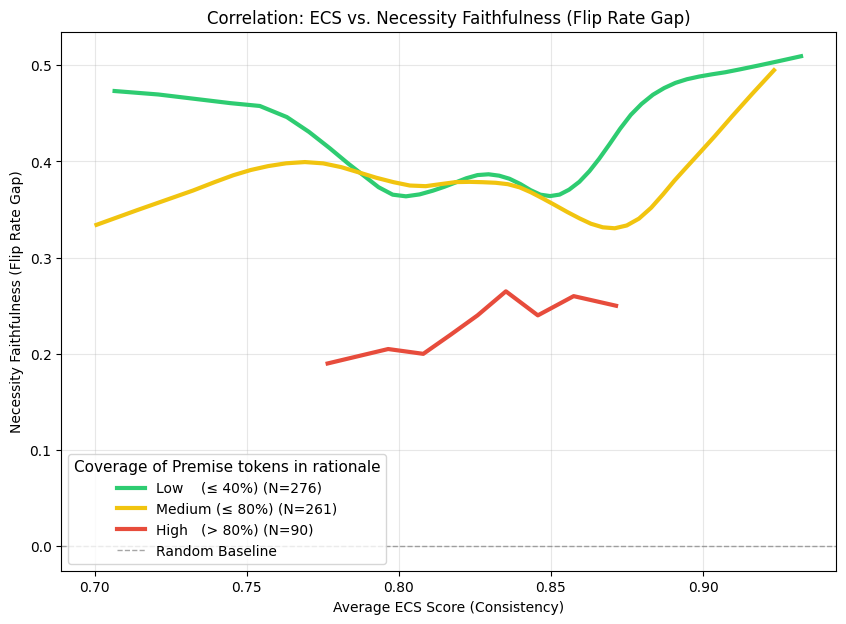

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


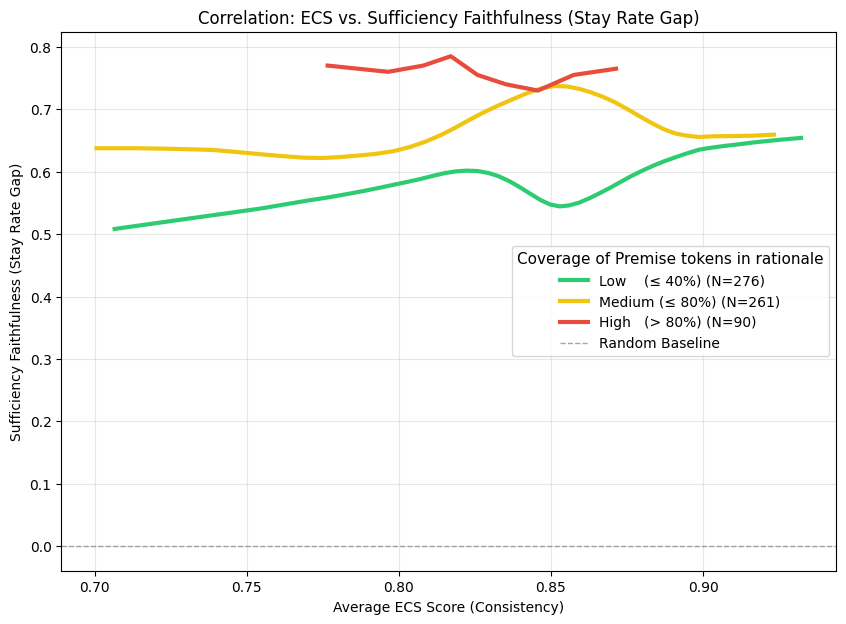

🎉 Done! Plots saved with sample counts.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_llama_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_llama_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


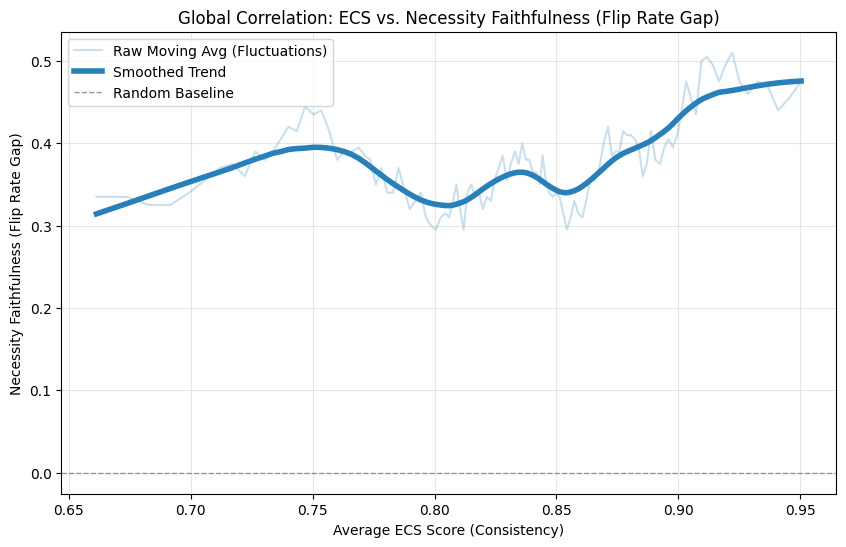

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


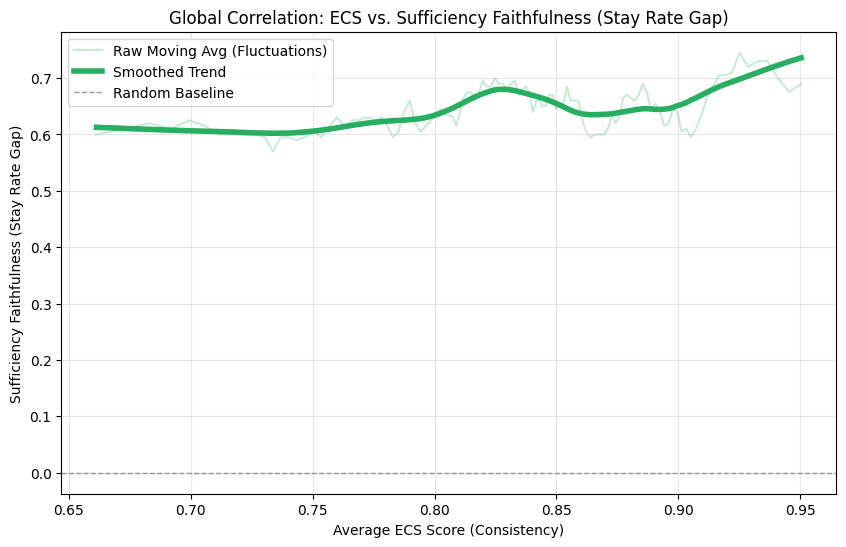

🎉 Done.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_llama_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_llama_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**mistral necessity/sufficiency flip rates**

In [1]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# The file you just created (Interventions)
INPUT_INTERVENTIONS = "esnli_step3_complete_mistral.csv" 

# The original file with the baseline rationales (To get the 'Original Prediction')
INPUT_BASELINE = "esnli_mistral_rationales_filtered.csv"

OUTPUT_FILE = "esnli_mistral_binary_outcomes.csv"

# ---------------------------
# 2. ROBUST LABEL EXTRACTOR
# ---------------------------
def extract_label(text):
    """
    Scans text for NLI labels. Prioritizes explicit 'Final Answer' tags.
    Returns: 'entailment', 'neutral', 'contradiction', or 'unknown'
    """
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    
    # Clean standard noise
    text = text.replace("**", "").replace('"', '').replace("'", "").replace(".", "")

    # Priority 1: Explicit "Final Answer"
    patterns = [
        r"final answer:?\s*(entailment|neutral|contradiction)",
        r"label:?\s*(entailment|neutral|contradiction)",
        r"the answer is\s*(entailment|neutral|contradiction)"
    ]
    for p in patterns:
        match = re.search(p, text)
        if match: return match.group(1)

    # Priority 2: End of text check (common in Chain of Thought)
    # Check the last 15 words
    end_text = " ".join(text.split()[-15:])
    if "entailment" in end_text: return "entailment"
    if "contradiction" in end_text: return "contradiction"
    if "neutral" in end_text: return "neutral"
    
    return "unknown"

# ---------------------------
# 3. LOAD & MERGE
# ---------------------------
print("📂 Loading files...")
df_interv = pd.read_csv(INPUT_INTERVENTIONS)
df_base   = pd.read_csv(INPUT_BASELINE)

# We merge to align the Intervention results with the Original Baseline Rationale
# We only need the ID and the original rationale columns from the baseline
base_cols = ["id", "rationale_original", "rationale_lexical", "rationale_syntactic", "rationale_pragmatic"]
df_merged = pd.merge(df_interv, df_base[base_cols], on="id", how="inner")

print(f"🔗 Merged. Processing {len(df_merged)} rows.")

# Map variant names to the column in the baseline file that holds the original text
variant_map = {
    "original":  "rationale_original",
    "lexical":   "rationale_lexical",
    "syntactic": "rationale_syntactic",
    "pragmatic": "rationale_pragmatic"
}

# ---------------------------
# 4. SCORING LOOP
# ---------------------------
print("🧠 Parsing labels and computing scores...")
scored_rows = []

for idx, row in df_merged.iterrows():
    # Basic info
    row_out = {
        "id": row["id"], 
        "gold_label": str(row["gold_label"]).lower()
    }
    
    for v in variant_map.keys():
        # --- A. EXTRACT LABELS ---
        
        # 1. The Anchor: Original Baseline Prediction
        # We must know what the model originally thought before we broke it
        base_text = row[variant_map[v]]
        pred_base = extract_label(base_text)
        
        # 2. The Interventions
        pred_nec      = extract_label(row[f"output_{v}_necessity"])
        pred_nec_ctrl = extract_label(row[f"output_{v}_necessity_control"])
        pred_suff     = extract_label(row[f"output_{v}_sufficiency"])
        pred_suff_ctrl= extract_label(row[f"output_{v}_sufficiency_control"])
        
        # Store Raw Labels (for debugging)
        row_out[f"pred_{v}_base"]      = pred_base
        row_out[f"pred_{v}_nec"]       = pred_nec
        row_out[f"pred_{v}_nec_ctrl"]  = pred_nec_ctrl
        row_out[f"pred_{v}_suff"]      = pred_suff
        row_out[f"pred_{v}_suff_ctrl"] = pred_suff_ctrl
        
        # --- B. PRESERVE COVERAGE (String Format) ---
        raw_cov = row.get(f"coverage_{v}", 0)
        try:
            cov_fmt = "{:.4f}".format(float(raw_cov))
        except:
            cov_fmt = "0.0000"
        row_out[f"coverage_{v}"] = cov_fmt
        
        # --- C. CALCULATE SCORES (1/0) ---
        # We only score if the Baseline was valid (not 'unknown')
        if pred_base != "unknown":
            
            # 1. Necessity Score (Goal: FLIP)
            # Did removing evidence change the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_nec != "unknown" and pred_nec != pred_base:
                row_out[f"score_{v}_nec_flip"] = 1
            else:
                row_out[f"score_{v}_nec_flip"] = 0
                
            # 2. Necessity Control Score (Goal: FLIP) - Wait, technically goal is NO flip
            # But we record "Did it flip?" (1=Yes). Later we subtract this.
            if pred_nec_ctrl != "unknown" and pred_nec_ctrl != pred_base:
                row_out[f"score_{v}_nec_ctrl_flip"] = 1
            else:
                row_out[f"score_{v}_nec_ctrl_flip"] = 0
            
            # 3. Sufficiency Score (Goal: STAY)
            # Did keeping evidence preserve the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_suff == pred_base:
                row_out[f"score_{v}_suff_stay"] = 1
            else:
                row_out[f"score_{v}_suff_stay"] = 0
                
            # 4. Sufficiency Control Score (Goal: STAY)
            # Did keeping random words preserve the prediction?
            # 1 = Yes (Bad/Trivial), 0 = No
            if pred_suff_ctrl == pred_base:
                row_out[f"score_{v}_suff_ctrl_stay"] = 1
            else:
                row_out[f"score_{v}_suff_ctrl_stay"] = 0

        else:
            # If baseline is unknown, we can't calculate flips
            row_out[f"score_{v}_nec_flip"] = np.nan
            row_out[f"score_{v}_nec_ctrl_flip"] = np.nan
            row_out[f"score_{v}_suff_stay"] = np.nan
            row_out[f"score_{v}_suff_ctrl_stay"] = np.nan

    scored_rows.append(row_out)

# ---------------------------
# 5. SAVE
# ---------------------------
df_scores = pd.DataFrame(scored_rows)

# Force coverage to be string to keep "0.5000" format
cov_cols = [c for c in df_scores.columns if "coverage" in c]
for c in cov_cols:
    df_scores[c] = df_scores[c].astype(str)

df_scores.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Step 3B Complete!")
print(f"📄 Binary scores saved to: {OUTPUT_FILE}")
print("\n🔍 Verification (First Row Scores):")
print(df_scores[[
    "score_original_nec_flip", 
    "score_original_nec_ctrl_flip", 
    "score_original_suff_stay",
    "score_original_suff_ctrl_stay"
]].head(1))

📂 Loading files...
🔗 Merged. Processing 623 rows.
🧠 Parsing labels and computing scores...
✅ Step 3B Complete!
📄 Binary scores saved to: esnli_mistral_binary_outcomes.csv

🔍 Verification (First Row Scores):
   score_original_nec_flip  score_original_nec_ctrl_flip  \
0                        0                             0   

   score_original_suff_stay  score_original_suff_ctrl_stay  
0                         1                              0  


**faithfulness mistral**

In [2]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_mistral_binary_outcomes.csv"
OUTPUT_FILE = "esnli_mistral_final_metrics.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip - rate_nec_ctrl_flip
    faith_suff = rate_suff_stay - rate_suff_ctrl_stay

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 623 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_mistral_final_metrics.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                    0.00                      0.25
1  2                    0.25                      0.50


**Mistral ECS vs Faithfulness Unified**

📂 Loading Data...
🔗 Merged Data: 623 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


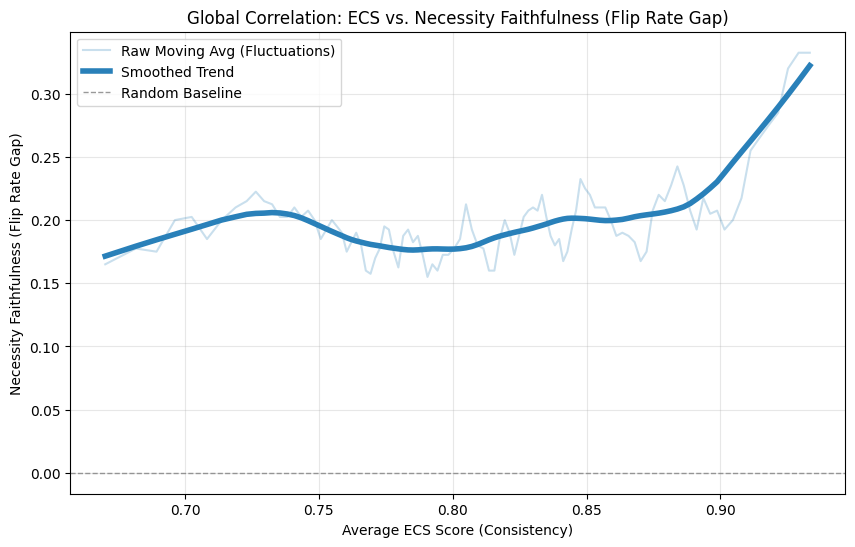

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


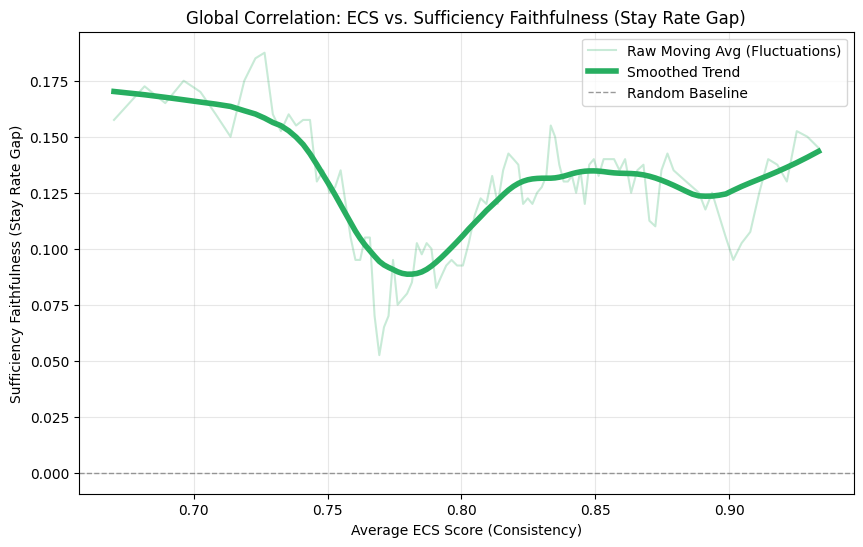

🎉 Done.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_mistral_final_metrics.csv"
ECS_FILE     = "esnli_mistral_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**Mistral Buckets**

📂 Loading Data...
🔗 Merged Data: 623 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


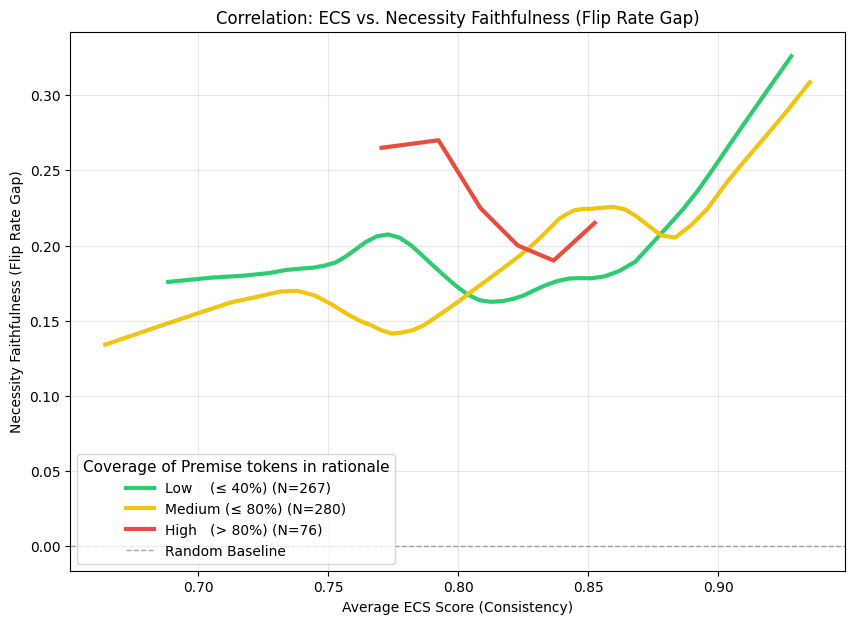

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


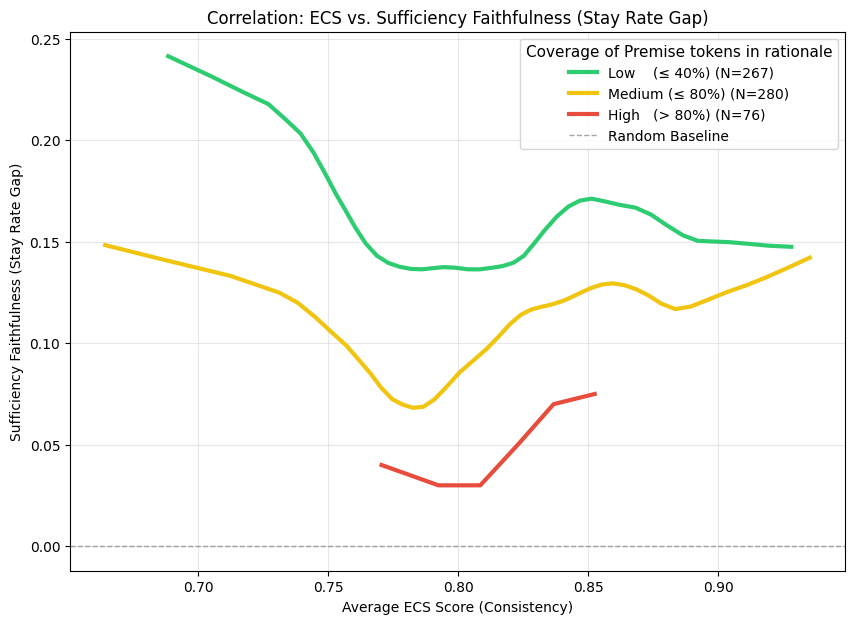

🎉 Done! Plots saved with sample counts.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_mistral_final_metrics.csv"
ECS_FILE     = "esnli_mistral_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

**mistral no control**

In [5]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_mistral_binary_outcomes.csv"
OUTPUT_FILE = "esnli_mistral_final_metrics_nocontrol.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip 
    faith_suff = rate_suff_stay 

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 623 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_mistral_final_metrics_nocontrol.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                    0.25                      1.00
1  2                    0.25                      0.75


📂 Loading Data...
🔗 Merged Data: 623 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


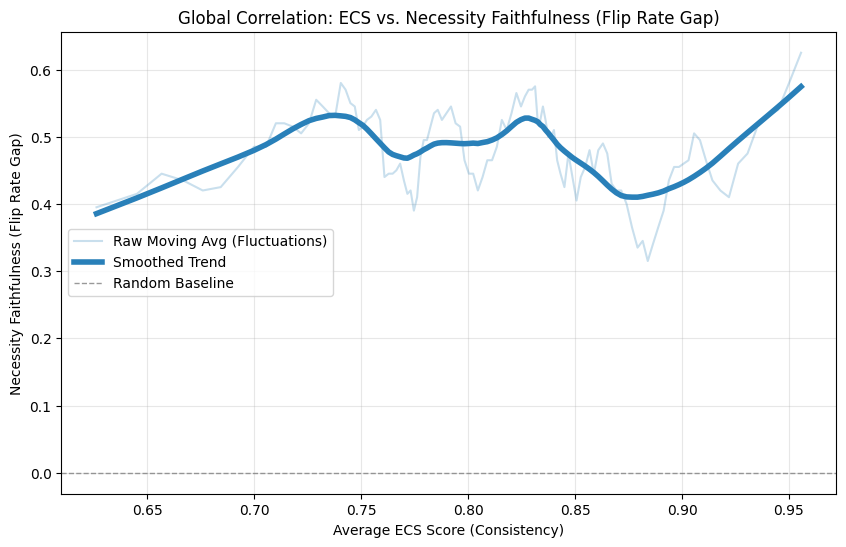

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


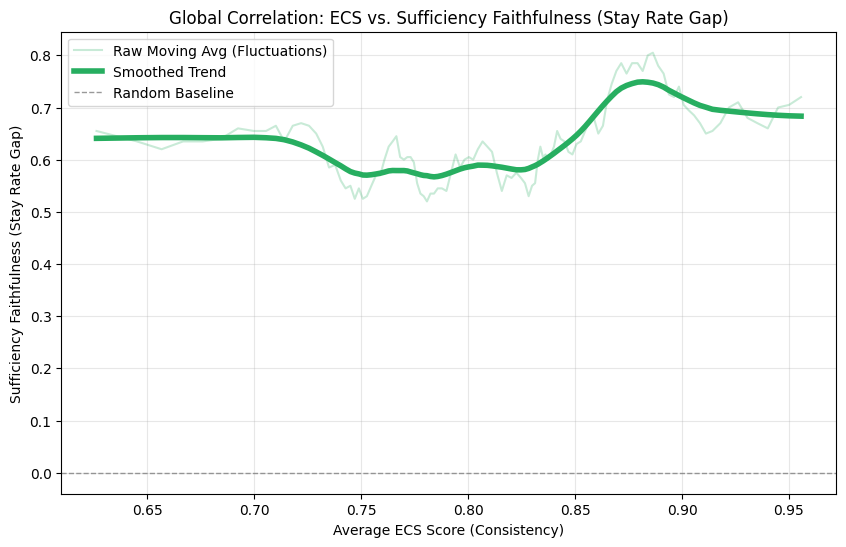

🎉 Done.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_mistral_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_mistral_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

📂 Loading Data...
🔗 Merged Data: 623 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


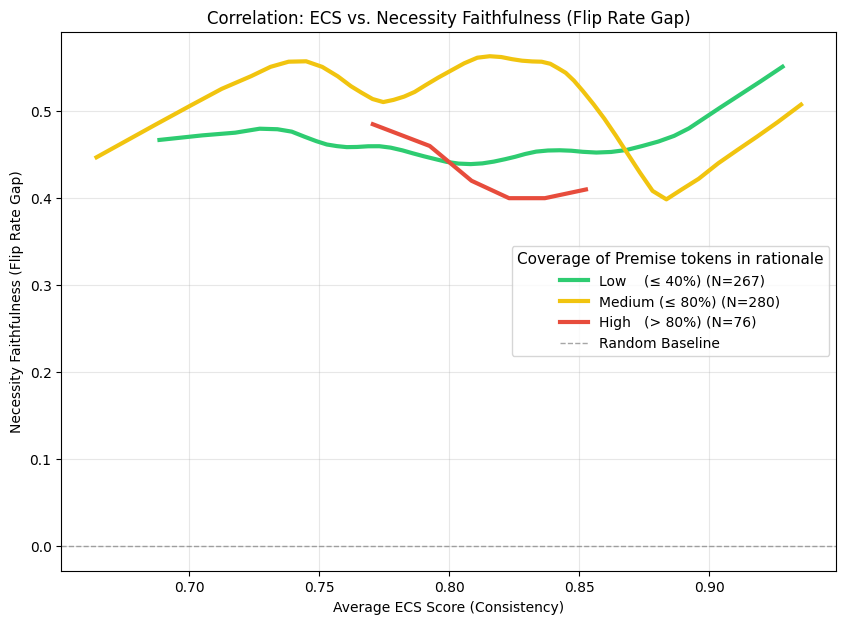

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


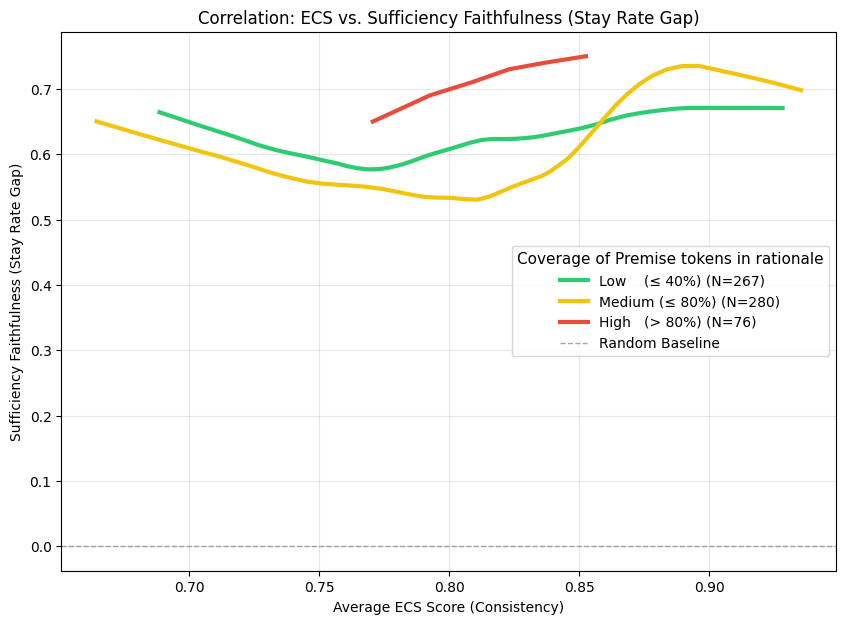

🎉 Done! Plots saved with sample counts.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_mistral_final_metrics_nocontrol.csv"
ECS_FILE     = "esnli_mistral_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

**Qwen 2.5 necessity/sufficiency flip rate**

In [7]:
import pandas as pd
import re
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# The file you just created (Interventions)
INPUT_INTERVENTIONS = "esnli_step3_complete_qwen.csv" 

# The original file with the baseline rationales (To get the 'Original Prediction')
INPUT_BASELINE = "qwen_esnli_rationales_filtered.csv"

OUTPUT_FILE = "esnli_qwen_binary_outcomes.csv"

# ---------------------------
# 2. ROBUST LABEL EXTRACTOR
# ---------------------------
def extract_label(text):
    """
    Scans text for NLI labels. Prioritizes explicit 'Final Answer' tags.
    Returns: 'entailment', 'neutral', 'contradiction', or 'unknown'
    """
    if pd.isna(text): return "unknown"
    text = str(text).lower().strip()
    
    # Clean standard noise
    text = text.replace("**", "").replace('"', '').replace("'", "").replace(".", "")

    # Priority 1: Explicit "Final Answer"
    patterns = [
        r"final answer:?\s*(entailment|neutral|contradiction)",
        r"label:?\s*(entailment|neutral|contradiction)",
        r"the answer is\s*(entailment|neutral|contradiction)"
    ]
    for p in patterns:
        match = re.search(p, text)
        if match: return match.group(1)

    # Priority 2: End of text check (common in Chain of Thought)
    # Check the last 15 words
    end_text = " ".join(text.split()[-15:])
    if "entailment" in end_text: return "entailment"
    if "contradiction" in end_text: return "contradiction"
    if "neutral" in end_text: return "neutral"
    
    return "unknown"

# ---------------------------
# 3. LOAD & MERGE
# ---------------------------
print("📂 Loading files...")
df_interv = pd.read_csv(INPUT_INTERVENTIONS)
df_base   = pd.read_csv(INPUT_BASELINE)

# We merge to align the Intervention results with the Original Baseline Rationale
# We only need the ID and the original rationale columns from the baseline
base_cols = ["id", "rationale_original", "rationale_perturbation_1_lexical", "rationale_perturbation_2_syntactic", "rationale_perturbation_3_pragmatic"]
df_merged = pd.merge(df_interv, df_base[base_cols], on="id", how="inner")

print(f"🔗 Merged. Processing {len(df_merged)} rows.")

# Map variant names to the column in the baseline file that holds the original text
variant_map = {
    "original":  "rationale_original",
    "lexical":   "rationale_perturbation_1_lexical",
    "syntactic": "rationale_perturbation_2_syntactic",
    "pragmatic": "rationale_perturbation_3_pragmatic"
}

# ---------------------------
# 4. SCORING LOOP
# ---------------------------
print("🧠 Parsing labels and computing scores...")
scored_rows = []

for idx, row in df_merged.iterrows():
    # Basic info
    row_out = {
        "id": row["id"], 
        "gold_label": str(row["gold_label"]).lower()
    }
    
    for v in variant_map.keys():
        # --- A. EXTRACT LABELS ---
        
        # 1. The Anchor: Original Baseline Prediction
        # We must know what the model originally thought before we broke it
        base_text = row[variant_map[v]]
        pred_base = extract_label(base_text)
        
        # 2. The Interventions
        pred_nec      = extract_label(row[f"output_{v}_necessity"])
        pred_nec_ctrl = extract_label(row[f"output_{v}_necessity_control"])
        pred_suff     = extract_label(row[f"output_{v}_sufficiency"])
        pred_suff_ctrl= extract_label(row[f"output_{v}_sufficiency_control"])
        
        # Store Raw Labels (for debugging)
        row_out[f"pred_{v}_base"]      = pred_base
        row_out[f"pred_{v}_nec"]       = pred_nec
        row_out[f"pred_{v}_nec_ctrl"]  = pred_nec_ctrl
        row_out[f"pred_{v}_suff"]      = pred_suff
        row_out[f"pred_{v}_suff_ctrl"] = pred_suff_ctrl
        
        # --- B. PRESERVE COVERAGE (String Format) ---
        raw_cov = row.get(f"coverage_{v}", 0)
        try:
            cov_fmt = "{:.4f}".format(float(raw_cov))
        except:
            cov_fmt = "0.0000"
        row_out[f"coverage_{v}"] = cov_fmt
        
        # --- C. CALCULATE SCORES (1/0) ---
        # We only score if the Baseline was valid (not 'unknown')
        if pred_base != "unknown":
            
            # 1. Necessity Score (Goal: FLIP)
            # Did removing evidence change the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_nec != "unknown" and pred_nec != pred_base:
                row_out[f"score_{v}_nec_flip"] = 1
            else:
                row_out[f"score_{v}_nec_flip"] = 0
                
            # 2. Necessity Control Score (Goal: FLIP) - Wait, technically goal is NO flip
            # But we record "Did it flip?" (1=Yes). Later we subtract this.
            if pred_nec_ctrl != "unknown" and pred_nec_ctrl != pred_base:
                row_out[f"score_{v}_nec_ctrl_flip"] = 1
            else:
                row_out[f"score_{v}_nec_ctrl_flip"] = 0
            
            # 3. Sufficiency Score (Goal: STAY)
            # Did keeping evidence preserve the prediction?
            # 1 = Yes (Good), 0 = No
            if pred_suff == pred_base:
                row_out[f"score_{v}_suff_stay"] = 1
            else:
                row_out[f"score_{v}_suff_stay"] = 0
                
            # 4. Sufficiency Control Score (Goal: STAY)
            # Did keeping random words preserve the prediction?
            # 1 = Yes (Bad/Trivial), 0 = No
            if pred_suff_ctrl == pred_base:
                row_out[f"score_{v}_suff_ctrl_stay"] = 1
            else:
                row_out[f"score_{v}_suff_ctrl_stay"] = 0

        else:
            # If baseline is unknown, we can't calculate flips
            row_out[f"score_{v}_nec_flip"] = np.nan
            row_out[f"score_{v}_nec_ctrl_flip"] = np.nan
            row_out[f"score_{v}_suff_stay"] = np.nan
            row_out[f"score_{v}_suff_ctrl_stay"] = np.nan

    scored_rows.append(row_out)

# ---------------------------
# 5. SAVE
# ---------------------------
df_scores = pd.DataFrame(scored_rows)

# Force coverage to be string to keep "0.5000" format
cov_cols = [c for c in df_scores.columns if "coverage" in c]
for c in cov_cols:
    df_scores[c] = df_scores[c].astype(str)

df_scores.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Step 3B Complete!")
print(f"📄 Binary scores saved to: {OUTPUT_FILE}")
print("\n🔍 Verification (First Row Scores):")
print(df_scores[[
    "score_original_nec_flip", 
    "score_original_nec_ctrl_flip", 
    "score_original_suff_stay",
    "score_original_suff_ctrl_stay"
]].head(1))

📂 Loading files...
🔗 Merged. Processing 627 rows.
🧠 Parsing labels and computing scores...
✅ Step 3B Complete!
📄 Binary scores saved to: esnli_qwen_binary_outcomes.csv

🔍 Verification (First Row Scores):
   score_original_nec_flip  score_original_nec_ctrl_flip  \
0                        1                             0   

   score_original_suff_stay  score_original_suff_ctrl_stay  
0                         0                              0  


****faithfulness qwen**

In [8]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_qwen_binary_outcomes.csv"
OUTPUT_FILE = "esnli_qwen_final_metrics.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip - rate_nec_ctrl_flip
    faith_suff = rate_suff_stay - rate_suff_ctrl_stay

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_qwen_final_metrics.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                    0.25                     -0.25
1  2                    0.75                      0.25


**Qwen ECS vs Faithfulness Unified**

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


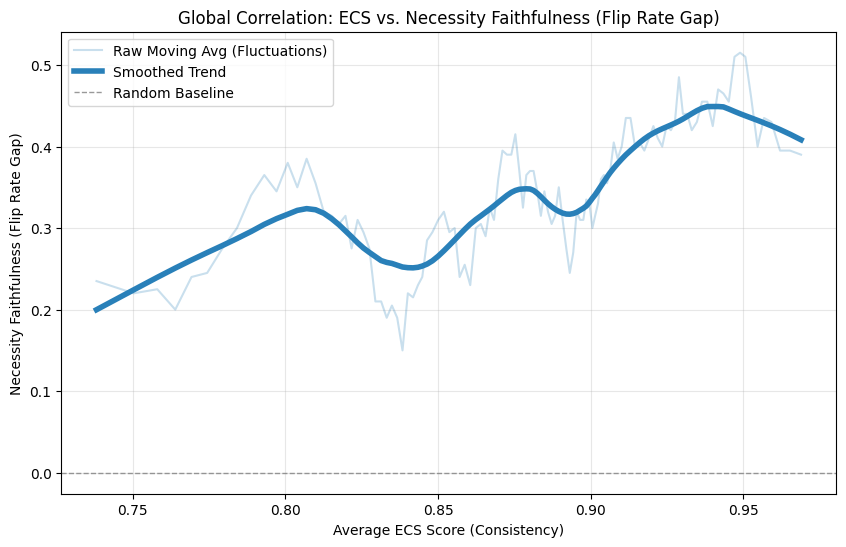

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


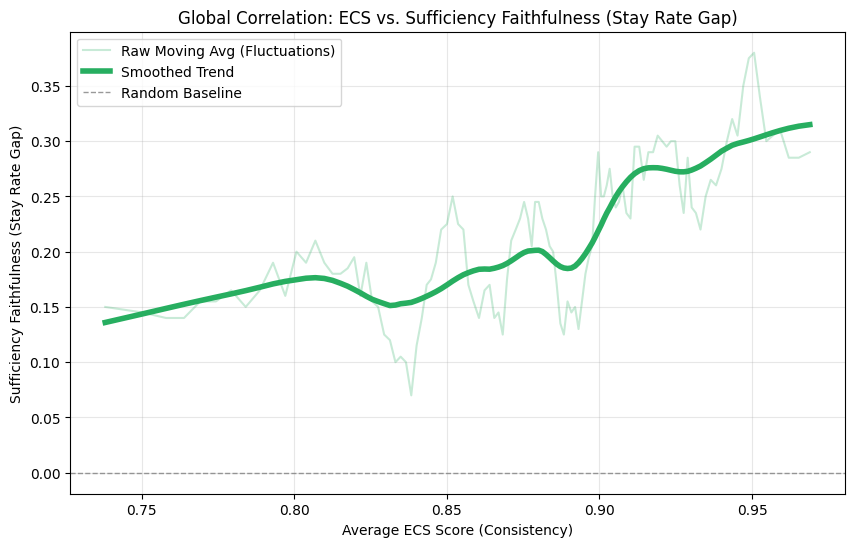

🎉 Done.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_qwen_final_metrics.csv"
ECS_FILE     = "qwen_esnli_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**Qwen Buckets**

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


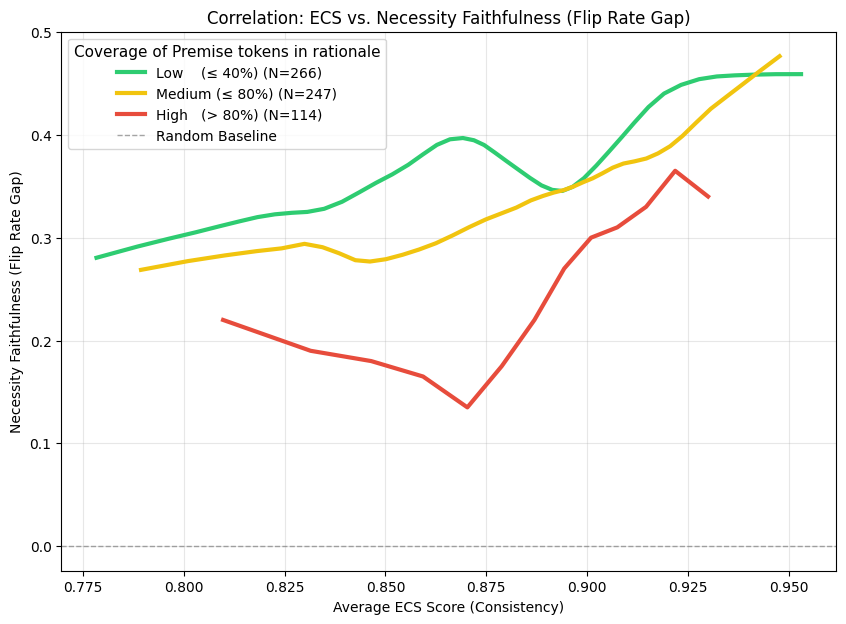

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


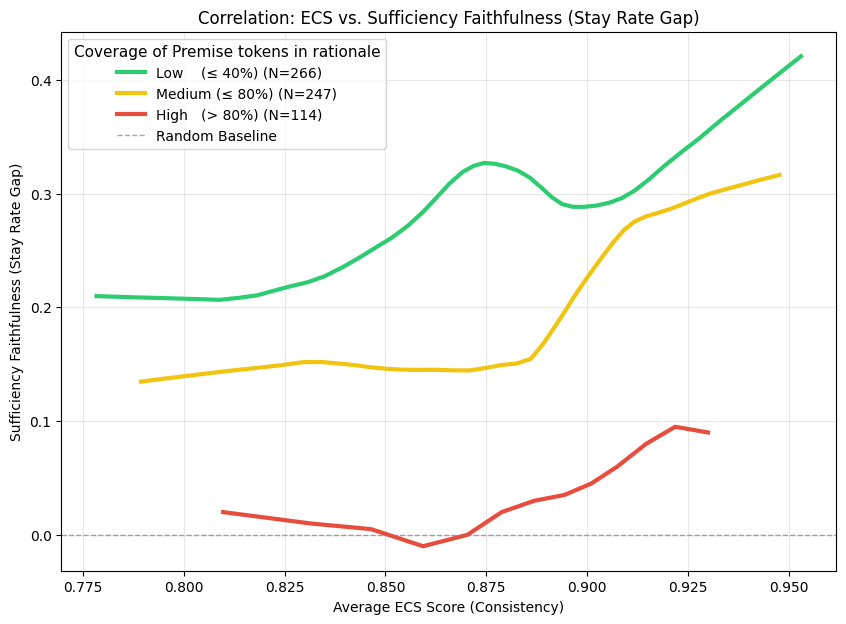

🎉 Done! Plots saved with sample counts.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_qwen_final_metrics.csv"
ECS_FILE     = "qwen_esnli_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

**Qwen no control**

In [12]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. CONFIGURATION
# ---------------------------
INPUT_FILE  = "esnli_qwen_binary_outcomes.csv"
OUTPUT_FILE = "esnli_qwen_final_metrics_nocontrol.csv"

# ---------------------------
# 2. LOAD DATA
# ---------------------------
print("📂 Loading Data...")
if not pd.io.common.file_exists(INPUT_FILE):
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# FIX: Force 'id' to be read as a string so it doesn't become a float
df = pd.read_csv(INPUT_FILE, dtype={'id': str})
print(f"   Processing {len(df)} examples.")

# ---------------------------
# 3. AGGREGATION LOGIC
# ---------------------------
variants = ["original", "lexical", "syntactic", "pragmatic"]

def calculate_metrics(row):
    # --- A. NECESSITY (The Flip Test) ---
    nec_flips      = [row.get(f"score_{v}_nec_flip", np.nan) for v in variants]
    nec_ctrl_flips = [row.get(f"score_{v}_nec_ctrl_flip", np.nan) for v in variants]
    
    rate_nec_flip      = np.nanmean(nec_flips)
    rate_nec_ctrl_flip = np.nanmean(nec_ctrl_flips)
    
    # --- B. SUFFICIENCY (The Stay Test) ---
    suff_stays      = [row.get(f"score_{v}_suff_stay", np.nan) for v in variants]
    suff_ctrl_stays = [row.get(f"score_{v}_suff_ctrl_stay", np.nan) for v in variants]
    
    rate_suff_stay      = np.nanmean(suff_stays)
    rate_suff_ctrl_stay = np.nanmean(suff_ctrl_stays)

    # --- C. FAITHFULNESS METRICS ---
    faith_nec  = rate_nec_flip 
    faith_suff = rate_suff_stay 

    return pd.Series({
        # Metadata
        "id": str(row["id"]), # Ensure it stays string here too
        "coverage_original": row.get("coverage_original", "0.0000"),
        
        # 1. Necessity Rates
        "Necessity_Flip_Rate": rate_nec_flip,
        "Necessity_Control_Flip_Rate": rate_nec_ctrl_flip,
        
        # 2. Sufficiency Rates
        "Sufficiency_Stay_Rate": rate_suff_stay,
        "Sufficiency_Control_Stay_Rate": rate_suff_ctrl_stay,
        
        # 3. Final Faithfulness Scores
        "Necessity_Faithfulness": faith_nec,
        "Sufficiency_Faithfulness": faith_suff
    })

print("🧮 Computing aggregated rates and faithfulness gaps...")
df_metrics = df.apply(calculate_metrics, axis=1)

# ---------------------------
# 4. BUCKETING
# ---------------------------
def get_bucket(val):
    try:
        val = float(val)
        if val <= 0.40: return "Local"
        if val <= 0.80: return "Mixed"
        return "Global"
    except: return "Unknown"

df_metrics['Bucket'] = df_metrics['coverage_original'].apply(get_bucket)

# ---------------------------
# 5. SAVE
# ---------------------------
# The float_format will now only apply to actual decimal columns, not the ID
df_metrics.to_csv(OUTPUT_FILE, index=False, float_format='%.4f')

print(f"✅ Step 5 Complete!")
print(f"📄 Final Metrics saved to: {OUTPUT_FILE}")
print("-" * 50)
print("🔍 Preview (First 2 Rows):")
print(df_metrics[[
    "id", 
    "Necessity_Faithfulness", 
    "Sufficiency_Faithfulness"
]].head(2))

📂 Loading Data...
   Processing 627 examples.
🧮 Computing aggregated rates and faithfulness gaps...
✅ Step 5 Complete!
📄 Final Metrics saved to: esnli_qwen_final_metrics_nocontrol.csv
--------------------------------------------------
🔍 Preview (First 2 Rows):
  id  Necessity_Faithfulness  Sufficiency_Faithfulness
0  1                    0.75                      0.25
1  2                    1.00                      0.75


📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_Necessity_Faithfulness.png


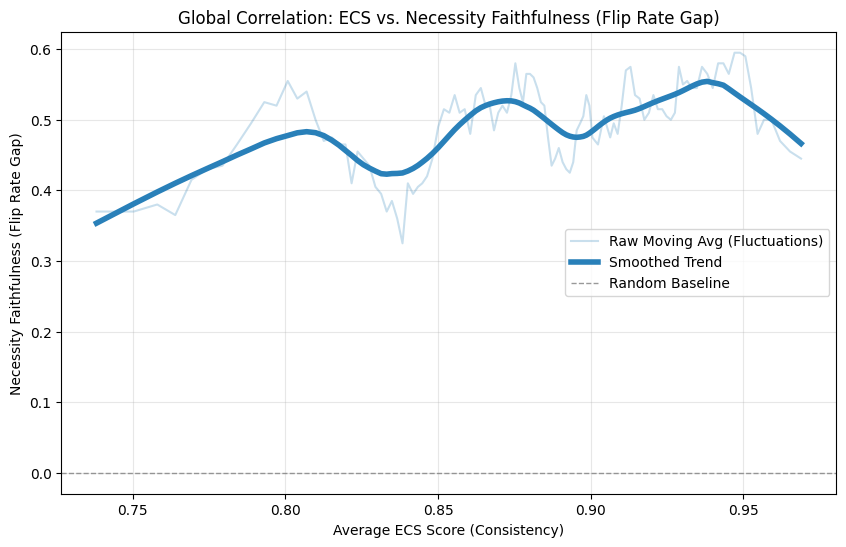

✅ Saved: Plot_Unified_Sufficiency_Faithfulness.png


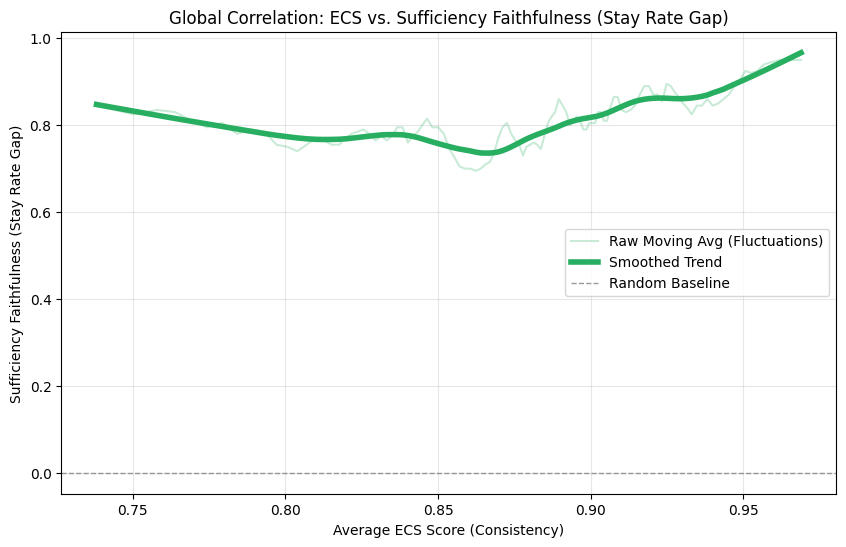

🎉 Done.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_qwen_final_metrics_nocontrol.csv"
ECS_FILE     = "qwen_esnli_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    # This represents the raw moving average
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25,       # Very transparent
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    # This represents the signal
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4,      # Thick line
            label="Smoothed Trend")

    # Optional: Add Scatter of actual data points (extremely faint)
    # ax.scatter(data["ECS"], data[y_col], color=color_hex, s=10, alpha=0.05)

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # Save
    filename = f"Plot_Unified_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Plots...
✅ Saved: Plot_Step7_Necessity_Faithfulness.png


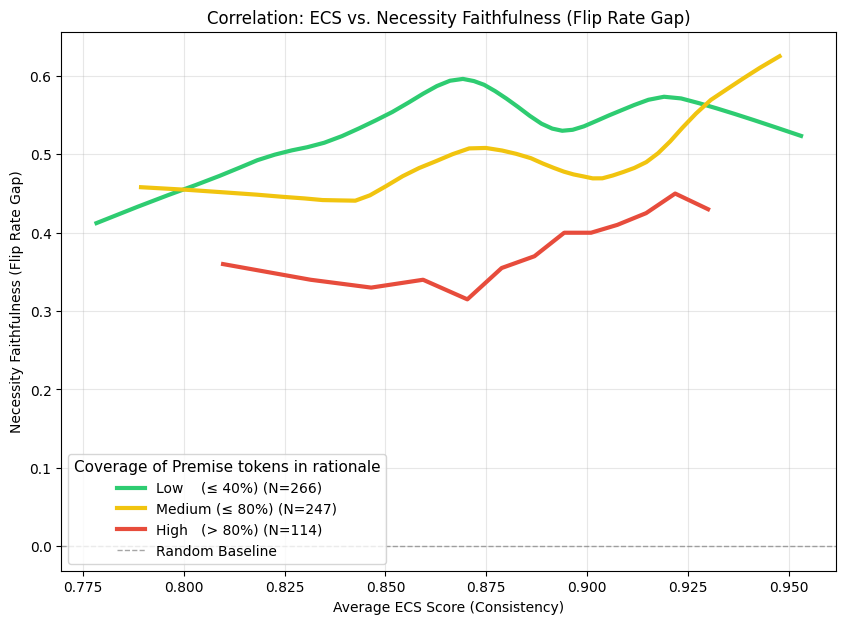

✅ Saved: Plot_Step7_Sufficiency_Faithfulness.png


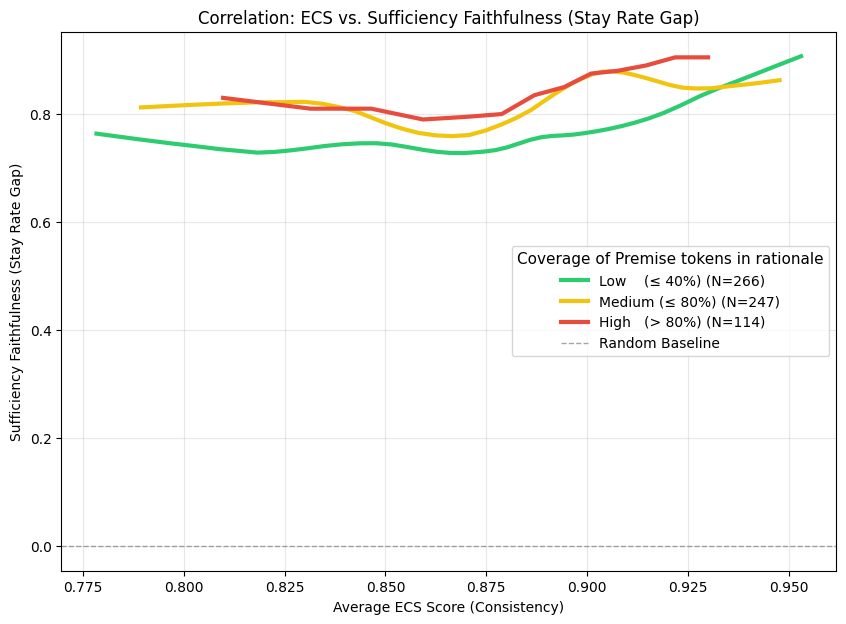

🎉 Done! Plots saved with sample counts.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_qwen_final_metrics_nocontrol.csv"
ECS_FILE     = "qwen_esnli_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.3  

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Identify ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find 'ECS' column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})

print(f"🔗 Merged Data: {len(df)} rows.")

# --- LEGEND DEFINITIONS ---
buckets = ["Local", "Mixed", "Global"]

bucket_labels = {
    "Local":  "Low    (≤ 40%)",
    "Mixed":  "Medium (≤ 80%)",
    "Global": "High   (> 80%)"
}

bucket_colors = {
    "Local":  "#2ecc71", # Green
    "Mixed":  "#f1c40f", # Yellow
    "Global": "#e74c3c"  # Red
}

# -----------------------------
# 3. HELPER: SLIDING WINDOW + SMOOTHING
# -----------------------------
def get_smoothed_trend(data, y_col):
    df_sorted = data.sort_values("ECS").reset_index(drop=True)
    
    if len(df_sorted) < WINDOW_SIZE:
        return None, None

    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(df_sorted) - WINDOW_SIZE + 1, STEP_SIZE):
        window = df_sorted.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        return None, None

    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    return smooth[:, 0], smooth[:, 1]

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

metrics_to_plot = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)"),
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)")
]

for metric_col, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Iterate through buckets
    for bucket in buckets:
        subset = df[df["Bucket"] == bucket]
        
        if subset.empty:
            continue
            
        x_smooth, y_smooth = get_smoothed_trend(subset, metric_col)
        
        if x_smooth is not None:
            # --- ADDING N COUNT HERE ---
            label_text = f"{bucket_labels[bucket]} (N={len(subset)})"
            
            ax.plot(x_smooth, y_smooth, 
                    color=bucket_colors[bucket], 
                    linewidth=3, 
                    label=label_text) 

    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Correlation: ECS vs. {metric_title}")
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label="Random Baseline")
    
    # Custom Legend Title
    ax.legend(title="Coverage of Premise tokens in rationale", 
              title_fontsize=11, 
              fontsize=10, 
              loc='best', 
              frameon=True)
    
    ax.grid(alpha=0.3)
    
    filename = f"Plot_Step7_{metric_col}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done! Plots saved with sample counts.")

📂 Loading Data...
🔗 Merged Data: 627 rows.
🎨 Generating Unified Plots...
✅ Saved: Unified_Necessity_Faithfulness_Gemini.pdf


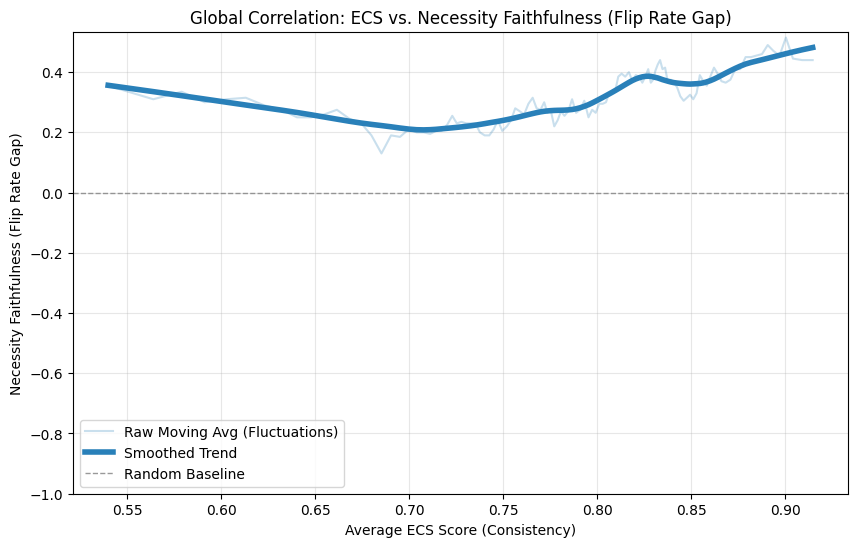

✅ Saved: Unified_Sufficiency_Faithfulness_Gemini.pdf


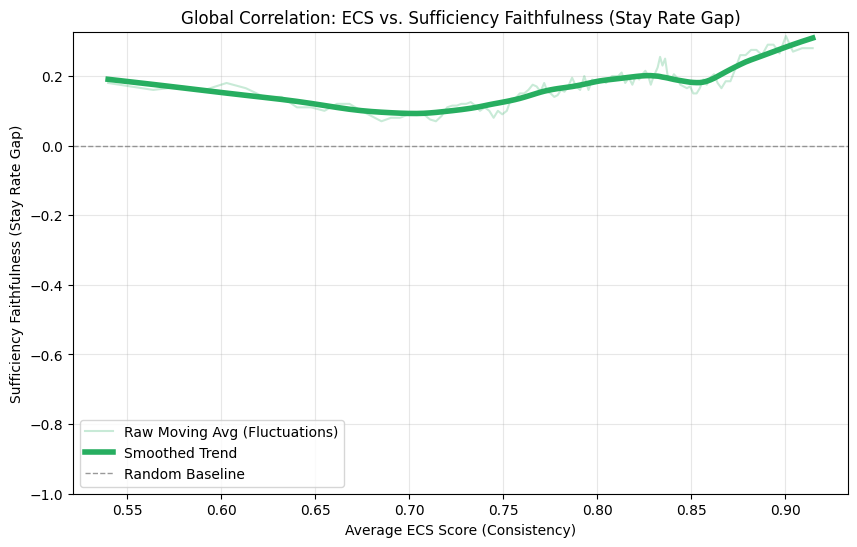

🎉 Done.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "esnli_gemini_final_metrics.csv"
ECS_FILE     = "esnli_gemini_rationales_with_ecs.csv"

# Plot Parameters
WINDOW_SIZE = 50   # Size of the sliding window (avg of 50 examples)
STEP_SIZE   = 5    # Step size
SMOOTHING   = 0.25 # LOWESS smoothing fraction

# -----------------------------
# 2. LOAD & PREPARE DATA
# -----------------------------
print("📂 Loading Data...")
try:
    df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
    df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})
except FileNotFoundError as e:
    print(f"❌ Error: {e}. Please ensure the CSV files are in the same directory.")
    exit()

# Detect ECS column
possible_ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not possible_ecs_cols:
    print("❌ Error: Could not find ECS column.")
    exit()
ecs_col = possible_ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. HELPER: SLIDING WINDOW WITH FLUCTUATIONS
# -----------------------------
def plot_trend_with_fluctuations(ax, data, y_col, title, color_hex):
    
    # A. Calculate Sliding Window Averages
    avg_ecs_list = []
    avg_metric_list = []

    for start in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[start : start + WINDOW_SIZE]
        avg_ecs_list.append(window["ECS"].mean())
        avg_metric_list.append(window[y_col].mean())

    if not avg_ecs_list:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # B. Plot the Fluctuations (The "Zigzag" Line)
    ax.plot(avg_ecs_list, avg_metric_list, 
            color=color_hex, 
            alpha=0.25, 
            linewidth=1.5, 
            label="Raw Moving Avg (Fluctuations)")

    # C. Plot the Smoothed Trend (LOWESS)
    smooth = lowess(avg_metric_list, avg_ecs_list, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4, 
            label="Smoothed Trend")

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

metrics = [
    ("Necessity_Faithfulness", "Necessity Faithfulness (Flip Rate Gap)", "#2980b9"), # Blue
    ("Sufficiency_Faithfulness", "Sufficiency Faithfulness (Stay Rate Gap)", "#27ae60") # Green
]

for metric_col, metric_title, color in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot
    plot_trend_with_fluctuations(ax, df, metric_col, metric_title, color)
    
    # Styling
    ax.set_xlabel("Average ECS Score (Consistency)")
    ax.set_ylabel(metric_title)
    ax.set_title(f"Global Correlation: ECS vs. {metric_title}")
    
    # --- REQUESTED CHANGE: Start Y-axis from -1 ---
    ax.set_ylim(bottom=-1)
    
    # Reference Line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Random Baseline")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    # --- REQUESTED CHANGE: Save as PDF with specific names ---
    filename = f"Unified_{metric_col}_Gemini.pdf"
    plt.savefig(filename, format='pdf', dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")